<div style="
    background-color: #eaf7ea;
    border-left: 5px solid #4caf50;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">
    
# Noise-Aware Transpilation and Lightweight Error Mitigation for XXX-Heisenberg Circuits

The initial benchmark in this notebook is a Trotterized quantum circuit derived from the one-dimensional XXX Heisenberg model. This model is useful for the project because it produces a structured quantum circuit with a known physical interpretation, while still being small enough to simulate exactly. That exact reference distribution gives us a meaningful way to measure output quality using metrics such as total variation distance (TVD), return-probability error, and top-state agreement.

This notebook begins with simulator-based experiments rather than immediate execution on real IBM quantum hardware. The purpose is to develop and validate the full experimental workflow in a controlled environment before using limited hardware time. In particular, the notebook builds the benchmark circuit, generates multiple Qiskit transpilation candidates, evaluates candidate circuits using structural metrics and backend-aware information, and compares the resulting noisy output distributions against an exact reference.

The simulator used here is not intended to represent an ideal quantum computer only. Instead, the workflow uses a backend-shaped noisy simulator so that the experiments can approximate important features of a real IBM superconducting backend, including native gate constraints, coupling-map limitations, routing overhead, and hardware-inspired noise behavior. This allows the project to test whether backend-aware candidate selection can improve measured output quality before submitting jobs to real hardware.

The main project question is practical: can a lightweight selection layer built on top of standard Qiskit transpilation choose a better hardware-compatible circuit than the default transpilation path? The goal is not to replace Qiskit's transpiler or design a new compiler. Rather, the notebook explores whether generating several legal transpilation candidates and ranking them using circuit depth, two-qubit gate count, SWAP count, backend coupling information, and calibration-aware noise estimates can produce better measured results.

Later notebooks extend this workflow to real IBM hardware and lightweight error mitigation methods such as readout-error mitigation and zero-noise extrapolation (ZNE). This notebook therefore serves as the foundation for the project: it establishes the benchmark circuit, the reference distribution, the candidate-generation process, and the core metrics used to evaluate whether backend-aware transpilation improves practical execution quality.

<b>Project intent.</b><br>
The goal is not to invent a new universal quantum compiler. The goal is to build a practical Qiskit-based workflow that generates several legal transpilation candidates, scores them using circuit-structure and backend/noise information, and then tests whether the selected candidate gives better physical or task-level behavior than a baseline Qiskit transpilation path.

## Research questions for this notebook

1. Can we generate a small, classically verifiable XXX-Heisenberg benchmark circuit?
2. Can we generate several transpiled candidates using Qiskit layout/routing/optimization choices?
3. Can we rank those candidates using a simple hardware-aware score?
4. Can we compare ideal, noisy-simulator, and lightly mitigated results?
5. Can the same object model later be reused for a QVC classifier?

## Initial assumptions

- Most development will run locally or on IBM/Aer simulators.
- Real IBM hardware should only be used after the workflow is stable (<span style="color:red">as it costs $$$</span>).
- The first benchmark should be small: 2--6 qubits, shallow Trotter depth.
- Evaluation should include compiler metrics and physics-level metrics.
- Improvements may be small or nonexistent; negative results are still reportable (<span style="color:red">if I find I was unsuccessful in proving my problem statement.</span>).

<p><strong>Literature linkage:</strong> This project framing follows the HW5 literature review: use Qiskit as the compiler substrate, generate multiple backend-compatible candidates, rank them using structural and backend-aware information, and evaluate the result on short XXX-model circuits before any optional QVC/VQC extension [4, 6, 7, 10, 11, 1, 2, 12].</p>

</div>

<div style="background-color:#fffde7; border-left: 5px solid #fbc02d; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## IBM Quantum account setup and why it is needed here

<p>
This notebook uses IBM Quantum backend information in two ways. First, it can construct a <em>backend-shaped noisy simulator</em> from a real IBM backend description. In that mode, circuits are still executed locally through Qiskit Aer, but the simulator is shaped by real backend metadata, including the target instruction set, basis gates, coupling map, qubit layout constraints, and calibration-derived noise properties. That backend snapshot is passed to <code>AerSimulator.from_backend(...)</code> to create a local noisy simulator shaped like the selected IBM device.
</p>

<p>
Second, this notebook now includes an optional section for submitting a small, carefully selected workload to real IBM quantum hardware. This is intended only for the final hardware validation step, after the backend-aware transpilation, noisy simulation, readout mitigation, and ZNE workflow have already been tested locally.
</p>

<p style="color:red;font-size:16px">
<strong>Safety flag:</strong> Real hardware submission is guarded by <code>REAL_HW_SUBMIT = False</code> by default. Leave this flag set to <code>False</code> while developing, debugging, or running the notebook locally. Change it to <code>True</code> only when you intentionally want to submit jobs to real IBM quantum hardware.
</p>

<p>
This means an IBM Quantum account is required even when running only the local backend-shaped simulator, because the notebook must authenticate with IBM Quantum to retrieve the selected backend's current device metadata. If real hardware submission is enabled, the same account is also used to submit jobs to the selected IBM backend.
</p>

<p>
To set up the free IBM Quantum account:
</p>

<ol>
    <li>Go to the IBM Quantum Platform and create or sign in to an IBM account.</li>
    <li>Open your IBM Quantum account page and copy your API token.</li>
    <li>Install the IBM runtime package in the same Python environment used by this notebook:</li>
</ol>

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color:#fffde7; border: 1px solid #f9e79f; text-align: left; display: inline-block; padding: 10px 14px; border-radius: 6px; line-height: 1.5;"><code>pip install qiskit-ibm-runtime</code></pre>
</div>

<p>
Then save your IBM Quantum account token once from Python:
</p>

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color:#fffde7; border: 1px solid #f9e79f; text-align: left; display: inline-block; padding: 10px 14px; border-radius: 6px; line-height: 1.5;"><code>from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="PASTE_YOUR_IBM_QUANTUM_API_TOKEN_HERE",
    set_as_default=True,
    overwrite=True,
)</code></pre>
</div>

<p>
After the token is saved, later notebook sessions can usually load the account with:
</p>

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color:#fffde7; border: 1px solid #f9e79f; text-align: left; display: inline-block; padding: 10px 14px; border-radius: 6px; line-height: 1.5;"><code>from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")</code></pre>
</div>

<p style="color:red;font-size:16px">
Do not commit your IBM Quantum token to GitHub or include it in the notebook output. The token should be saved locally in your environment, not hard-coded into the project repository.
</p>

<p>
If the backend-loading cell fails, check the following:
</p>

<ul>
    <li><code>qiskit-ibm-runtime</code> is installed in the active notebook kernel.</li>
    <li>Your IBM Quantum token has been saved in this Python environment.</li>
    <li>The requested backend name, such as <code>ibm_fez</code>, is available to your account.</li>
    <li>You are connected to the internet when loading the backend snapshot.</li>
</ul>

<p>
Once the backend is loaded, the notebook can create a local backend-shaped simulator. That simulator lets us test the transpilation and noise-aware candidate-selection workflow before spending limited IBM hardware time. The optional real-hardware section should be used only after this local validation step, and only when <code>REAL_HW_SUBMIT</code> has been intentionally changed to <code>True</code>.
</p>

</div>

<div style="
    background-color: #fff4e5;
    border-left: 5px solid #f59e0b;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">
    
## Mathematical benchmark: 1D XXX Heisenberg model

For a chain of $n$ spins with nearest-neighbor coupling, the simplified XXX Hamiltonian is

$$
H_{XXX} = J \sum_{i=0}^{n-2} \left(X_iX_{i+1} + Y_iY_{i+1} + Z_iZ_{i+1}\right).
$$

The time-evolution operator is

$$
U(t) = e^{-i t H_{XXX}}.
$$

On hardware, this operator must be synthesized into gates, mapped onto physical qubits, routed through the backend coupling graph, and optimized. Different transpilation choices can produce logically equivalent circuits with different depth, two-qubit count, SWAP count, and exposure to backend noise.

For this project, the XXX model is useful because small instances are classically simulable. That gives us a reference distribution or reference observable against which noisy and mitigated results can be compared.


## Experimental workflow

The first-phase workflow is:

1. Build a small XXX-Heisenberg time-evolution circuit.
2. Add measurements.
3. Create several transpilation candidates.
4. Extract compiler metrics:
   - depth,
   - total operation count,
   - two-qubit gate count,
   - SWAP count,
   - circuit size.
5. Estimate backend-aware penalties when backend properties are available:
   - readout error,
   - one-qubit gate error,
   - two-qubit gate error,
   - approximate reliability score.
6. Run ideal and noisy simulation.
7. Apply lightweight mitigation candidates:
   - readout correction/postprocessing,
   - digital zero-noise extrapolation using simple circuit folding.
8. Compare against a reference result.

Later notebooks can add IBM Runtime execution and a QVC classifier benchmark.


<p><strong>Literature linkage:</strong> The XXX model is used as the controlled benchmark because small instances can be exactly or classically simulated, which makes distribution-level comparisons such as TVD and return probability meaningful [12]. The need to synthesize, map, route, and optimize the circuit for a target backend follows the Qiskit compiler workflow described in the literature review [4].</p>

</div>

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Any, Dict, Iterable, List, Optional, Tuple
import warnings

import numpy as np
import pandas as pd

try:
    import qiskit
    from qiskit import QuantumCircuit, transpile
    from qiskit.quantum_info import Statevector
    from qiskit.circuit.library import RXXGate, RYYGate, RZZGate
except Exception as exc:
    raise ImportError("Qiskit imports failed. Install qiskit in the active environment.") from exc

try:
    from qiskit_aer import AerSimulator
except Exception:
    AerSimulator = None
    warnings.warn("qiskit-aer is not available. Backend-shaped noisy simulation will not run until installed.")

EXPECTED_QISKIT_VERSION = "2.2.1"
actual_qiskit_version = getattr(qiskit, "__version__", "unknown")
print("qiskit:", actual_qiskit_version)
if actual_qiskit_version != EXPECTED_QISKIT_VERSION:
    print(f"WARNING: This notebook was developed for Qiskit {EXPECTED_QISKIT_VERSION}.")

try:
    import qiskit_aer
    print("qiskit-aer:", getattr(qiskit_aer, "__version__", "unknown"))
except Exception:
    print("qiskit-aer: unavailable")

qiskit: 2.2.1
qiskit-aer: 0.17.2


In [2]:
@dataclass(frozen=True)
class XXXModelConfig:
    """Configuration for a 1D nearest-neighbor XXX Heisenberg benchmark."""

    num_qubits: int = 4
    coupling_j: float = 1.0
    evolution_time: float = 0.25
    trotter_reps: int = 3
    initial_bitstring: str = "1000"  # written as q_{n-1} ... q_0
    product_formula: str = "lie"     # "lie" or "suzuki"

    def validate(self) -> None:
        if self.num_qubits < 2:
            raise ValueError("num_qubits must be at least 2.")
        if len(self.initial_bitstring) != self.num_qubits:
            raise ValueError("initial_bitstring length must match num_qubits.")
        if any(ch not in "01" for ch in self.initial_bitstring):
            raise ValueError("initial_bitstring must contain only 0 and 1.")
        if self.trotter_reps < 1:
            raise ValueError("trotter_reps must be at least 1.")
        if self.product_formula not in {"lie", "suzuki"}:
            raise ValueError("product_formula must be either 'lie' or 'suzuki'.")


@dataclass(frozen=True)
class CandidateSpec:
    """One transpilation candidate specification."""

    name: str
    optimization_level: int
    layout_method: Optional[str] = None
    routing_method: Optional[str] = None
    translation_method: Optional[str] = None
    scheduling_method: Optional[str] = None
    seed_transpiler: int = 7


@dataclass(frozen=True)
class Config:
    """Configuration for the mitigation starting point."""

    model: XXXModelConfig = field(default_factory=XXXModelConfig)
    backend_name: str = "ibm_fez"
    shots: int = 4096
    seed_simulator: int = 1234
    transpiler_seeds: Tuple[int, ...] = (7, 11, 19)
    optimization_levels: Tuple[int, ...] = (1, 2, 3)
    layout_methods: Tuple[Optional[str], ...] = (None, "trivial", "dense", "sabre")
    routing_methods: Tuple[Optional[str], ...] = (None, "basic", "lookahead", "sabre")
    translation_methods: Tuple[Optional[str], ...] = (None,)
    scheduling_methods: Tuple[Optional[str], ...] = (None,)
    max_candidates: Optional[int] = None

    def validate(self) -> None:
        self.model.validate()
        if self.shots < 1:
            raise ValueError("shots must be positive.")
        if not self.transpiler_seeds:
            raise ValueError("At least one transpiler seed is required.")
        if any(level not in (0, 1, 2, 3) for level in self.optimization_levels):
            raise ValueError("Qiskit optimization levels must be in {0, 1, 2, 3}.")


config = Config(
    model=XXXModelConfig(
        num_qubits=4,
        coupling_j=1.0,
        evolution_time=0.25,
        trotter_reps=3,
        initial_bitstring="1000",
        product_formula="lie",
    ),
    backend_name="ibm_fez",
    shots=4096,
    seed_simulator=1234,
    transpiler_seeds=(7, 11, 19),
    optimization_levels=(1, 2, 3),
    layout_methods=(None, "trivial", "dense", "sabre"),
    routing_methods=(None, "basic", "lookahead", "sabre"),
    max_candidates=None,
)
config.validate()
config

Config(model=XXXModelConfig(num_qubits=4, coupling_j=1.0, evolution_time=0.25, trotter_reps=3, initial_bitstring='1000', product_formula='lie'), backend_name='ibm_fez', shots=4096, seed_simulator=1234, transpiler_seeds=(7, 11, 19), optimization_levels=(1, 2, 3), layout_methods=(None, 'trivial', 'dense', 'sabre'), routing_methods=(None, 'basic', 'lookahead', 'sabre'), translation_methods=(None,), scheduling_methods=(None,), max_candidates=None)

<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## XXX Heisenberg circuit factory

This factory builds the small Trotterized XXX Heisenberg benchmark circuit. The unmeasured circuit is used to compute the exact reference distribution, while the measured circuit is transpiled and executed.

</div>

<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Aside: Avoiding sparse-matrix warnings by using explicit Trotter gates</strong>

This was an error I was getting in the initial experimentation.

This notebook constructs the XXX Heisenberg time-evolution circuit using explicit <code>RXX</code>, <code>RYY</code>, and <code>RZZ</code> two-qubit rotation gates instead of relying on a high-level <code>PauliEvolutionGate</code> backed by sparse-matrix exponentiation.

It changes the circuit construction to use the gate-level product formula directly. For the nearest-neighbor XXX Hamiltonian,

<br>

$$
H = J \sum_i \left(X_iX_{i+1} + Y_iY_{i+1} + Z_iZ_{i+1}\right),
$$

<br>

a first-order Trotter step applies the pair interactions one at a time. Qiskit's Pauli rotation gates use the convention:

<br>

$$
R_{PP}(\theta) = e^{-i \theta P \otimes P / 2}.
$$

<br>

Therefore, to implement:

<br>

$$
e^{-i \Delta t J P \otimes P},
$$

<br>

the notebook uses:

<br>

$$
\theta = 2J\Delta t.
$$

<br>

This keeps the Trotterized XXX circuit explicit, easier to inspect, and avoids SciPy sparse linear-algebra efficiency warnings caused by high-level sparse exponentiation paths.

</div>

In [3]:
class XXXHeisenbergCircuitFactory:
    """Build small Trotterized XXX-Heisenberg benchmark circuits.

    This implementation uses explicit two-qubit Pauli-rotation gates instead of
    PauliEvolutionGate/SparsePauliOp. That keeps the circuit construction transparent,
    avoids SciPy sparse-matrix exponentiation warnings (as annotated in the previous cell),
    and makes the Trotter product formula visible in the generated circuit.

    For a nearest-neighbor XXX Hamiltonian,

        H = J sum_i (X_i X_{i+1} + Y_i Y_{i+1} + Z_i Z_{i+1}),

    a first-order Trotter step applies the pair interactions one at a time:

        exp(-i dt J XX), exp(-i dt J YY), exp(-i dt J ZZ).

    Qiskit's RXX/RYY/RZZ gates use the convention

        RPP(theta) = exp(-i theta/2 P⊗P),

    so the required angle for exp(-i dt J P⊗P) is theta = 2 J dt.
    """

    def __init__(self, config: XXXModelConfig):
        config.validate()
        self.config = config

    def _nearest_neighbor_pairs(self) -> List[Tuple[int, int]]:
        """Return nearest-neighbor logical-qubit pairs for the 1D spin chain."""
        return [(i, i + 1) for i in range(self.config.num_qubits - 1)]

    def _prepare_initial_state(self, qc: QuantumCircuit) -> None:
        """Prepare a computational basis state from a human-readable bitstring."""
        bitstring = self.config.initial_bitstring
        n = self.config.num_qubits
        for displayed_index, bit in enumerate(bitstring):
            if bit == "1":
                qubit_index = n - 1 - displayed_index
                qc.x(qubit_index)

    def _append_xx_yy_zz_block(self, qc: QuantumCircuit, q0: int, q1: int, dt: float) -> None:
        """Append one nearest-neighbor XXX interaction block for qubits q0 and q1."""
        theta = 2.0 * self.config.coupling_j * dt
        qc.append(RXXGate(theta), [q0, q1])
        qc.append(RYYGate(theta), [q0, q1])
        qc.append(RZZGate(theta), [q0, q1])

    def _append_lie_trotter_step(self, qc: QuantumCircuit, dt: float) -> None:
        """Append one first-order Lie-Trotter step."""
        for q0, q1 in self._nearest_neighbor_pairs():
            self._append_xx_yy_zz_block(qc, q0, q1, dt)

    def _append_suzuki_second_order_step(self, qc: QuantumCircuit, dt: float) -> None:
        """Append a simple second-order symmetric Suzuki step.

        The first half-step applies the nearest-neighbor blocks in forward order.
        The second half-step applies them in reverse order. This gives a symmetric
        product formula while keeping the circuit explicit.
        """
        pairs = self._nearest_neighbor_pairs()
        half_dt = dt / 2.0
        for q0, q1 in pairs:
            self._append_xx_yy_zz_block(qc, q0, q1, half_dt)
        for q0, q1 in reversed(pairs):
            self._append_xx_yy_zz_block(qc, q0, q1, half_dt)

    def build_unitary_circuit(self) -> QuantumCircuit:
        """Build the unmeasured explicit-Trotter time-evolution circuit."""
        n = self.config.num_qubits
        qc = QuantumCircuit(n, name="xxx_heisenberg_explicit_trotter")
        self._prepare_initial_state(qc)

        dt = self.config.evolution_time / float(self.config.trotter_reps)
        for _ in range(self.config.trotter_reps):
            if self.config.product_formula == "lie":
                self._append_lie_trotter_step(qc, dt)
            else:
                self._append_suzuki_second_order_step(qc, dt)

        return qc

    def build_measured_circuit(self) -> QuantumCircuit:
        """Build the measured circuit used for counts-based execution."""
        qc = self.build_unitary_circuit()
        qc.measure_all()
        return qc


class ReferenceSimulator:
    """Exact reference simulator for small circuits."""

    @staticmethod
    def exact_probabilities(qc_without_measurements: QuantumCircuit) -> Dict[str, float]:
        sv = Statevector.from_instruction(qc_without_measurements)
        return dict(sorted(sv.probabilities_dict().items()))

    @staticmethod
    def top_state(probs: Dict[str, float]) -> Optional[str]:
        if not probs:
            return None
        return max(probs.items(), key=lambda kv: kv[1])[0]


factory = XXXHeisenbergCircuitFactory(config.model)
unitary_circuit = factory.build_unitary_circuit()
measured_circuit = factory.build_measured_circuit()
reference_probs = ReferenceSimulator.exact_probabilities(unitary_circuit)

print("Reference top state:", ReferenceSimulator.top_state(reference_probs))
print("Non-negligible reference probabilities:")
for bitstring, prob in reference_probs.items():
    if prob > 1e-6:
        print(f"  {bitstring}: {prob:.6f}")

measured_circuit.draw("text")

Reference top state: 1000
Non-negligible reference probabilities:
  0001: 0.000021
  0010: 0.006467
  0100: 0.215322
  1000: 0.778190


┌───────────────┐┌───────────────┐                               »
   q_0: ┤0              ├┤0              ├─■─────────────────────────────»
        │  Rxx(0.16667) ││  Ryy(0.16667) │ │ZZ(0.16667) ┌───────────────┐»
   q_1: ┤1              ├┤1              ├─■────────────┤0              ├»
        └───────────────┘└───────────────┘              │  Rxx(0.16667) │»
   q_2: ────────────────────────────────────────────────┤1              ├»
              ┌───┐                                     └───────────────┘»
   q_3: ──────┤ X ├──────────────────────────────────────────────────────»
              └───┘                                                      »
meas: 4/═════════════════════════════════════════════════════════════════»
                                                                         »
«                                       ┌───────────────┐┌───────────────┐»
«   q_0: ───────────────────────────────┤0              ├┤0              ├»
«        ┌───────────────┐              │  Rxx(0.16667) ││  Ryy(0.16667) │»
«   q_1: ┤0              ├─■────────────┤1              ├┤1              ├»
«        │  Ryy(0.16667) │ │ZZ(0.16667) ├───────────────┤├───────────────┤»
«   q_2: ┤1              ├─■────────────┤0              ├┤0              ├»
«        └───────────────┘              │  Rxx(0.16667) ││  Ryy(0.16667) │»
«   q_3: ───────────────────────────────┤1              ├┤1              ├»
«                                       └───────────────┘└───────────────┘»
«meas: 4/═════════════════════════════════════════════════════════════════»
«                                                                         »
«                                                                      »
«   q_0: ─■────────────────────────────────────────────────────────────»
«         │ZZ(0.16667) ┌───────────────┐┌───────────────┐              »
«   q_1: ─■────────────┤0              ├┤0              ├─■────────────»
«                      │  Rxx(0.16667) ││  Ryy(0.16667) │ │ZZ(0.16667) »
«   q_2: ─■────────────┤1              ├┤1              ├─■────────────»
«         │ZZ(0.16667) └───────────────┘└───────────────┘              »
«   q_3: ─■────────────────────────────────────────────────────────────»
«                                                                      »
«meas: 4/══════════════════════════════════════════════════════════════»
«                                                                      »
«        ┌───────────────┐┌───────────────┐                               »
«   q_0: ┤0              ├┤0              ├─■─────────────────────────────»
«        │  Rxx(0.16667) ││  Ryy(0.16667) │ │ZZ(0.16667) ┌───────────────┐»
«   q_1: ┤1              ├┤1              ├─■────────────┤0              ├»
«        ├───────────────┤├───────────────┤              │  Rxx(0.16667) │»
«   q_2: ┤0              ├┤0              ├─■────────────┤1              ├»
«        │  Rxx(0.16667) ││  Ryy(0.16667) │ │ZZ(0.16667) └───────────────┘»
«   q_3: ┤1              ├┤1              ├─■─────────────────────────────»
«        └───────────────┘└───────────────┘                               »
«meas: 4/═════════════════════════════════════════════════════════════════»
«                                                                         »
«                                                                         »
«   q_0: ─────────────────────────────────────────────────────────────────»
«        ┌───────────────┐                                                »
«   q_1: ┤0              ├─■──────────────────────────────────────────────»
«        │  Ryy(0.16667) │ │ZZ(0.16667) ┌───────────────┐┌───────────────┐»
«   q_2: ┤1              ├─■────────────┤0              ├┤0              ├»
«        └───────────────┘              │  Rxx(0.16667) ││  Ryy(0.16667) │»
«   q_3: ───────────────────────────────┤1              ├┤1              ├»
«                                       └───────────────┘└───────────────┘»
«meas: 4/═══════════════

<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">
    
## Candidate Generation and Structural Circuit Metrics

This section defines the machinery used to generate and evaluate transpilation candidates. The goal is to create multiple valid Qiskit transpilation configurations for the same logical benchmark circuit, extract structural properties from each transpiled circuit, and assign each candidate a simple structural score. Later sections extend this idea by adding backend-aware noise information, but this section establishes the baseline candidate-sweep and metric-extraction infrastructure.

The important idea is that Qiskit's transpiler is not deterministic under all settings. Different optimization levels, layout methods, routing methods, translation methods, scheduling methods, and random seeds can produce different hardware-compatible circuits. Even when these circuits implement the same logical algorithm, they may have different depths, two-qubit gate counts, SWAP counts, and native-gate decompositions. These differences matter because deeper circuits and circuits with more two-qubit gates generally accumulate more noise on real hardware.

The `CandidateSweep` class constructs a list of candidate transpilation specifications by taking the Cartesian product of the configured transpiler options. Each generated candidate receives a descriptive name that records the optimization level, layout method, routing method, and random seed. This makes the later result tables easier to interpret because each row can be traced back to the transpiler settings that produced it.

The sweep can also be capped by `max_candidates`. This is useful because the full Cartesian product can become large quickly. For example, if there are several seeds, optimization levels, layout strategies, routing strategies, translation methods, and scheduling methods, the number of possible candidates can grow rapidly. Limiting the sweep allows the notebook to remain computationally manageable while still exploring a representative set of transpiler choices.

The `CircuitMetrics` class extracts structural metrics from each transpiled circuit using Qiskit 2.x-compatible APIs. These metrics include circuit depth, total operation count, width, number of qubits, number of classical bits, number of two-qubit gates, number of CX gates, number of ECR gates, number of SWAP gates, and number of measurements. The class also records a full operation-count dictionary and a breakdown of named two-qubit gates. These metrics provide a compact description of the physical cost of a transpiled circuit.

The `TranspiledCandidate` dataclass stores the result of a transpilation attempt. It combines the candidate specification, the transpiled circuit itself, the extracted circuit metrics, and a structural score. This makes it easy to compare candidates in a table and select candidates for later noisy simulation or hardware execution.

The `structural_score_from_metrics` function defines a simple lower-is-better structural score:

$$
\text{score}
=
1.0 \cdot \text{depth}
+
10.0 \cdot \text{two-qubit count}
+
25.0 \cdot \text{SWAP count}
+
8.0 \cdot \text{CX count}
+
8.0 \cdot \text{ECR count}.
$$

This score intentionally penalizes two-qubit operations and SWAP gates more heavily than circuit depth because two-qubit gates are typically more error-prone than single-qubit gates on superconducting quantum hardware. SWAP gates receive an even larger penalty because a SWAP is usually decomposed into multiple two-qubit gates and often indicates that routing was required to satisfy the backend coupling map.

This structural score is not yet the full backend-aware score. It does not directly use calibration data such as readout error rates, gate error rates, or physical-qubit layout quality. Instead, it provides a useful baseline ranking based only on the structure of the transpiled circuit. Later, this project compares this purely structural view with a backend-aware scoring approach that incorporates hardware-specific information.
</div>

In [4]:
class CandidateSweep:
    """

    Generate a sweep of Qiskit transpilation candidate specifications.

    A single logical quantum circuit can be transpiled in many valid ways depending
    on the selected optimization level, layout method, routing method, translation
    method, scheduling method, and transpiler seed. This class constructs the
    Cartesian product of those configuration choices and returns a list of
    CandidateSpec objects.

    Each candidate receives a descriptive name containing the optimization level,
    layout method, routing method, and seed so that later result tables can be
    traced back to the transpiler settings that produced each circuit.

    If config.max_candidates is set, generation stops once that many candidates
    have been produced. This prevents large transpiler sweeps from becoming too
    expensive.

    """

    def __init__(self, config: Config):
        config.validate()
        self.config = config

    def generate(self) -> List[CandidateSpec]:
        specs: List[CandidateSpec] = []
        idx = 0
        for seed in self.config.transpiler_seeds:
            for opt_level in self.config.optimization_levels:
                for layout in self.config.layout_methods:
                    for routing in self.config.routing_methods:
                        for translation in self.config.translation_methods:
                            for scheduling in self.config.scheduling_methods:
                                layout_label = layout if layout is not None else "default"
                                routing_label = routing if routing is not None else "default"
                                name = (
                                    f"p3_{idx:03d}_opt{opt_level}_"
                                    f"layout-{layout_label}_routing-{routing_label}_seed-{seed}"
                                )
                                specs.append(
                                    CandidateSpec(
                                        name=name,
                                        optimization_level=opt_level,
                                        layout_method=layout,
                                        routing_method=routing,
                                        translation_method=translation,
                                        scheduling_method=scheduling,
                                        seed_transpiler=seed,
                                    )
                                )
                                idx += 1
                                if self.config.max_candidates is not None and len(specs) >= self.config.max_candidates:
                                    return specs
        return specs


class CircuitMetrics:
    """
    Extract structural metrics from a transpiled Qiskit circuit.

    These metrics summarize the physical cost of the transpiled circuit before
    any backend-aware noise scoring is applied. Important metrics include depth,
    total size, width, number of qubits, number of classical bits, two-qubit gate
    count, CX count, ECR count, SWAP count, measurement count, and a full operation
    breakdown.

    Two-qubit gates are tracked separately because they are usually more error
    prone than single-qubit gates on superconducting quantum hardware. SWAP gates
    are also important because they indicate routing overhead introduced to satisfy
    the backend coupling map.
    """

    @staticmethod
    def operation_counts(circuit: QuantumCircuit) -> Dict[str, int]:
        return {str(name): int(count) for name, count in circuit.count_ops().items()}

    @classmethod
    def two_qubit_count(cls, circuit: QuantumCircuit) -> int:
        return sum(1 for instruction in circuit.data if len(instruction.qubits) == 2)

    @classmethod
    def named_two_qubit_counts(cls, circuit: QuantumCircuit) -> Dict[str, int]:
        counts: Dict[str, int] = {}
        for instruction in circuit.data:
            name = str(instruction.operation.name)
            if len(instruction.qubits) == 2:
                counts[name] = counts.get(name, 0) + 1
        return counts

    @classmethod
    def extract(cls, circuit: QuantumCircuit) -> Dict[str, Any]:
        counts = cls.operation_counts(circuit)
        return {
            "depth": int(circuit.depth()),
            "size": int(circuit.size()),
            "width": int(circuit.width()),
            "num_qubits": int(circuit.num_qubits),
            "num_clbits": int(circuit.num_clbits),
            "twoq_count": int(cls.two_qubit_count(circuit)),
            "cx_count": int(counts.get("cx", 0)),
            "ecr_count": int(counts.get("ecr", 0)),
            "swap_count": int(counts.get("swap", 0)),
            "measure_count": int(counts.get("measure", 0)),
            "operation_counts": counts,
            # Backward-compatible alias used by earlier notebook tables.
            "ops": counts,
            "twoq_gate_breakdown": cls.named_two_qubit_counts(circuit),
        }


@dataclass
class TranspiledCandidate:
    """
    Container for one transpiled candidate circuit.

    Attributes:
        spec:
            The CandidateSpec describing the transpiler settings used to create
            this circuit.

        circuit:
            The transpiled QuantumCircuit.

        metrics:
            Structural metrics extracted from the transpiled circuit.

        structural_score:
            A lower-is-better score computed from the structural metrics. This is
            useful for ranking candidates before adding backend calibration data.
    """
    spec: CandidateSpec
    circuit: QuantumCircuit
    metrics: Dict[str, Any]
    structural_score: float


def structural_score_from_metrics(metrics: Dict[str, Any]) -> float:
    """
    Compute a simple lower-is-better structural score for a transpiled circuit.

    The score penalizes circuit depth, two-qubit gates, SWAP gates, and native
    two-qubit gate counts. Two-qubit operations are weighted more heavily than
    depth because they are typically more error-prone on superconducting devices.
    SWAP gates receive an additional penalty because they are usually decomposed
    into multiple two-qubit gates and indicate routing overhead.

    This is a structural score only. It does not yet include backend calibration
    data such as qubit readout error, gate error, or physical edge quality.
    """
    return float(
        1.0 * metrics.get("depth", 0)
        + 10.0 * metrics.get("twoq_count", 0)
        + 25.0 * metrics.get("swap_count", 0)
        + 8.0 * metrics.get("cx_count", 0)
        + 8.0 * metrics.get("ecr_count", 0)
    )

<div style="background-color:#fffde7; border-left: 5px solid #fbc02d; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

<strong>Aside:</strong> If the backend-loading cell fails, check that <code>qiskit-ibm-runtime</code> is installed and that your IBM Quantum account is saved in the current environment. This notebook assumes your account setup has already been handled outside the notebook.

</div>

In [5]:
def load_ibm_backend(backend_name: str = "ibm_fez") -> Any:
    """Load an IBM backend by name using the locally configured IBM Quantum account."""
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService
    except Exception as exc:
        raise ImportError(
            "qiskit-ibm-runtime is required to load IBM backends. "
            "Install it and configure your IBM Quantum account before running this cell."
        ) from exc

    service = QiskitRuntimeService()
    return service.backend(backend_name)


def make_backend_shaped_aer_simulator(real_backend: Any) -> Any:
    """Create an Aer noisy simulator from an IBM backend snapshot."""
    if AerSimulator is None:
        raise ImportError("qiskit-aer is required for AerSimulator.from_backend(...).")
    return AerSimulator.from_backend(real_backend)


# Uncomment and run locally once your IBM Quantum account is configured.
real_backend = load_ibm_backend(config.backend_name)
noisy_backend = make_backend_shaped_aer_simulator(real_backend)
print("Loaded backend:", getattr(real_backend, "name", config.backend_name))
print("Created backend-shaped noisy simulator.")

Loaded backend: ibm_fez
Created backend-shaped noisy simulator.


In [6]:
def _safe_backend_name(backend: Any) -> str:
    name_attr = getattr(backend, "name", None)
    if callable(name_attr):
        try:
            return str(name_attr())
        except Exception:
            pass
    if name_attr is not None:
        return str(name_attr)
    return str(backend)


def _safe_num_qubits(backend: Any) -> Optional[int]:
    value = getattr(backend, "num_qubits", None)
    if value is not None:
        try:
            return int(value)
        except Exception:
            pass
    try:
        return int(backend.configuration().n_qubits)
    except Exception:
        return None


def _safe_basis_gates(backend: Any) -> List[str]:
    try:
        target = getattr(backend, "target", None)
        if target is not None and getattr(target, "operation_names", None) is not None:
            return sorted(str(x) for x in target.operation_names)
    except Exception:
        pass
    try:
        return sorted(str(x) for x in backend.configuration().basis_gates)
    except Exception:
        return []


def _safe_coupling_edges(backend: Any) -> List[Tuple[int, int]]:
    try:
        coupling_map = getattr(backend, "coupling_map", None)
        if coupling_map is not None:
            if hasattr(coupling_map, "get_edges"):
                return [tuple(map(int, edge)) for edge in coupling_map.get_edges()]
            return [tuple(map(int, edge)) for edge in coupling_map]
    except Exception:
        pass
    try:
        return [tuple(map(int, edge)) for edge in backend.configuration().coupling_map]
    except Exception:
        return []


def _param_value(parameters: Iterable[Any], name: str) -> Optional[float]:
    for param in parameters:
        if getattr(param, "name", None) == name:
            try:
                return float(param.value)
            except Exception:
                return None
    return None


class BackendCalibrationSnapshot:
    """Defensive wrapper around IBM backend properties for scoring and reporting."""

    def __init__(self, backend: Any):
        self.backend = backend
        self.name = _safe_backend_name(backend)
        self.num_qubits = _safe_num_qubits(backend)
        self.basis_gates = _safe_basis_gates(backend)
        self.coupling_edges = _safe_coupling_edges(backend)
        self.snapshot_utc = datetime.now(timezone.utc).isoformat(timespec="seconds")
        try:
            self.properties = backend.properties()
        except Exception:
            self.properties = None
        self._gate_error_lookup, self._gate_length_lookup = self._build_gate_lookups()

    def backend_summary(self) -> pd.DataFrame:
        return pd.DataFrame([{
            "backend_name": self.name,
            "num_qubits": self.num_qubits,
            "basis_gates": ", ".join(self.basis_gates),
            "num_coupling_edges": len(self.coupling_edges),
            "snapshot_utc": self.snapshot_utc,
        }])

    def qubit_table(self) -> pd.DataFrame:
        if self.properties is None or self.num_qubits is None:
            return pd.DataFrame()
        rows = []
        for q in range(self.num_qubits):
            try:
                params = self.properties.qubits[q]
            except Exception:
                params = []
            try:
                readout_error = float(self.properties.readout_error(q))
            except Exception:
                readout_error = _param_value(params, "readout_error")
            rows.append({
                "physical_qubit": q,
                "readout_error": readout_error,
                "T1_s": _param_value(params, "T1"),
                "T2_s": _param_value(params, "T2"),
                "frequency_Hz": _param_value(params, "frequency"),
            })
        return pd.DataFrame(rows)

    def gate_table(self) -> pd.DataFrame:
        if self.properties is None:
            return pd.DataFrame()
        rows = []
        for gate in getattr(self.properties, "gates", []):
            gate_name = str(getattr(gate, "gate", "unknown"))
            qubits = tuple(int(q) for q in getattr(gate, "qubits", []))
            params = getattr(gate, "parameters", [])
            rows.append({
                "gate": gate_name,
                "qubits": qubits,
                "arity": len(qubits),
                "gate_error": _param_value(params, "gate_error"),
                "gate_length_s": _param_value(params, "gate_length"),
            })
        return pd.DataFrame(rows)

    def _build_gate_lookups(self) -> Tuple[Dict[Tuple[str, Tuple[int, ...]], float], Dict[Tuple[str, Tuple[int, ...]], float]]:
        error_lookup: Dict[Tuple[str, Tuple[int, ...]], float] = {}
        length_lookup: Dict[Tuple[str, Tuple[int, ...]], float] = {}
        gate_df = self.gate_table()
        if gate_df.empty:
            return error_lookup, length_lookup
        for _, row in gate_df.iterrows():
            gate = str(row["gate"])
            qubits = tuple(row["qubits"])
            gate_error = row.get("gate_error")
            gate_length = row.get("gate_length_s")
            keys = [(gate, qubits)]
            if len(qubits) == 2:
                keys.append((gate, tuple(reversed(qubits))))
            for key in keys:
                if pd.notna(gate_error):
                    error_lookup[key] = float(gate_error)
                if pd.notna(gate_length):
                    length_lookup[key] = float(gate_length)
        return error_lookup, length_lookup

    def readout_error(self, physical_qubit: int) -> Optional[float]:
        if self.properties is None:
            return None
        try:
            return float(self.properties.readout_error(int(physical_qubit)))
        except Exception:
            qdf = self.qubit_table()
            row = qdf.loc[qdf["physical_qubit"].eq(int(physical_qubit))] if not qdf.empty else pd.DataFrame()
            if row.empty or pd.isna(row.iloc[0].get("readout_error")):
                return None
            return float(row.iloc[0]["readout_error"])

    def gate_error(self, gate_name: str, physical_qubits: Tuple[int, ...]) -> Optional[float]:
        key = (str(gate_name), tuple(int(q) for q in physical_qubits))
        return self._gate_error_lookup.get(key)

    def gate_length(self, gate_name: str, physical_qubits: Tuple[int, ...]) -> Optional[float]:
        key = (str(gate_name), tuple(int(q) for q in physical_qubits))
        return self._gate_length_lookup.get(key)


backend_snapshot = BackendCalibrationSnapshot(real_backend)
display(backend_snapshot.backend_summary())
display(backend_snapshot.qubit_table().head())
display(backend_snapshot.gate_table().head())

,backend_name,num_qubits,basis_gates,num_coupling_edges,snapshot_utc
0,ibm_fez,156,"cz, delay, id, if_else, measure, reset, rz, sx, x",352,2026-05-16T16:46:00+00:00


,physical_qubit,readout_error,T1_s,T2_s,frequency_Hz
0,0,0.027832,40.765278,46.562532,None
1,1,0.029053,133.765145,152.632097,None
2,2,0.011108,157.149377,123.307575,None
3,3,0.037476,145.947242,148.610966,None
4,4,0.012085,119.972264,97.147280,None


,gate,qubits,arity,gate_error,gate_length_s
0,id,"(0,)",1,0.002489,24.0
1,id,"(1,)",1,0.000351,24.0
2,id,"(2,)",1,0.000204,24.0
3,id,"(3,)",1,0.000237,24.0
4,id,"(4,)",1,0.000283,24.0


<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Backend-targeted transpilation and backend-aware scoring

This section creates the actual candidate circuits. Each candidate is transpiled against the selected IBM backend target, then scored using both structural metrics and backend calibration estimates.

<p><strong>Literature linkage:</strong> This section connects directly to the calibration-aware transpilation and routing literature. Qiskit provides the backend-targeted compiler infrastructure [4], SABRE motivates layout and routing search on sparse hardware graphs [6], and calibration/variability-aware mapping motivates using backend error information rather than only circuit structure [7, 10].</p>

</div>

In [7]:
class CandidateBuilder:
    """Build backend-targeted transpiled candidate circuits."""

    def __init__(self, backend: Optional[Any] = None):
        self.backend = backend

    def _transpile_one(self, circuit: QuantumCircuit, spec: CandidateSpec) -> QuantumCircuit:
        kwargs: Dict[str, Any] = {
            "optimization_level": spec.optimization_level,
            "seed_transpiler": spec.seed_transpiler,
        }
        if self.backend is not None:
            kwargs["backend"] = self.backend
        if spec.layout_method is not None:
            kwargs["layout_method"] = spec.layout_method
        if spec.routing_method is not None:
            kwargs["routing_method"] = spec.routing_method
        if spec.translation_method is not None:
            kwargs["translation_method"] = spec.translation_method
        if spec.scheduling_method is not None:
            kwargs["scheduling_method"] = spec.scheduling_method
        return transpile(circuit, **kwargs)

    def build(self, circuit: QuantumCircuit, specs: List[CandidateSpec]) -> Tuple[List[TranspiledCandidate], pd.DataFrame]:
        candidates: List[TranspiledCandidate] = []
        rows: List[Dict[str, Any]] = []
        for spec in specs:
            base = {
                "candidate": spec.name,
                "optimization_level": spec.optimization_level,
                "layout_method": spec.layout_method or "default",
                "routing_method": spec.routing_method or "default",
                "translation_method": spec.translation_method or "default",
                "scheduling_method": spec.scheduling_method or "none",
                "seed_transpiler": spec.seed_transpiler,
            }
            try:
                tqc = self._transpile_one(circuit, spec)
                metrics = CircuitMetrics.extract(tqc)
                structural_score = structural_score_from_metrics(metrics)
                candidates.append(
                    TranspiledCandidate(
                        spec=spec,
                        circuit=tqc,
                        metrics=metrics,
                        structural_score=structural_score,
                    )
                )
                rows.append({**base, **metrics, "structural_score": structural_score, "status": "ok", "error": None})
            except Exception as exc:
                rows.append({**base, "structural_score": np.nan, "status": "failed", "error": repr(exc)})
        table = pd.DataFrame(rows)
        if not table.empty:
            ok = table["status"].eq("ok")
            table = pd.concat([
                table.loc[ok].sort_values(["structural_score", "twoq_count", "depth"], ascending=True),
                table.loc[~ok],
            ], ignore_index=True)
        return candidates, table


IGNORED_OPS_FOR_BACKEND_ERROR = {
    "measure", "barrier", "delay", "id", "reset", "snapshot", "save_statevector", "save_density_matrix"
}


def _instruction_physical_qubits(circuit: QuantumCircuit, instruction: Any) -> Tuple[int, ...]:
    indices: List[int] = []
    for qubit in instruction.qubits:
        try:
            indices.append(int(circuit.find_bit(qubit).index))
        except Exception:
            try:
                indices.append(int(qubit.index))
            except Exception:
                pass
    return tuple(indices)


def estimate_candidate_backend_errors(candidate: TranspiledCandidate, snapshot: BackendCalibrationSnapshot) -> Dict[str, Any]:
    circuit = candidate.circuit
    active_qubits = set()
    measured_qubits = set()
    oneq_gate_error_sum = 0.0
    twoq_gate_error_sum = 0.0
    other_gate_error_sum = 0.0
    gate_length_sum_s = 0.0
    oneq_gate_count_with_error = 0
    twoq_gate_count_with_error = 0
    missing_gate_error_count = 0
    missing_gate_length_count = 0

    for instruction in circuit.data:
        op_name = str(instruction.operation.name)
        physical_qubits = _instruction_physical_qubits(circuit, instruction)
        if physical_qubits:
            active_qubits.update(physical_qubits)
        if op_name == "measure":
            measured_qubits.update(physical_qubits)
            continue
        if op_name in IGNORED_OPS_FOR_BACKEND_ERROR:
            continue

        gate_error = snapshot.gate_error(op_name, physical_qubits)
        gate_length = snapshot.gate_length(op_name, physical_qubits)
        if gate_error is None:
            missing_gate_error_count += 1
        else:
            if len(physical_qubits) == 1:
                oneq_gate_error_sum += float(gate_error)
                oneq_gate_count_with_error += 1
            elif len(physical_qubits) == 2:
                twoq_gate_error_sum += float(gate_error)
                twoq_gate_count_with_error += 1
            else:
                other_gate_error_sum += float(gate_error)
        if gate_length is None:
            missing_gate_length_count += 1
        else:
            gate_length_sum_s += float(gate_length)

    if not measured_qubits:
        measured_qubits = set(active_qubits)

    readout_errors = []
    for q in sorted(measured_qubits):
        err = snapshot.readout_error(q)
        if err is not None:
            readout_errors.append(float(err))

    estimated_readout_error_sum = float(np.sum(readout_errors)) if readout_errors else 0.0
    estimated_readout_error_mean = float(np.mean(readout_errors)) if readout_errors else 0.0
    estimated_total_gate_error_sum = float(oneq_gate_error_sum + twoq_gate_error_sum + other_gate_error_sum)

    return {
        "candidate": candidate.spec.name,
        "active_physical_qubits": tuple(sorted(active_qubits)),
        "measured_physical_qubits": tuple(sorted(measured_qubits)),
        "num_active_physical_qubits": len(active_qubits),
        "num_measured_physical_qubits": len(measured_qubits),
        "estimated_readout_error_sum": estimated_readout_error_sum,
        "estimated_readout_error_mean": estimated_readout_error_mean,
        "estimated_1q_gate_error_sum": float(oneq_gate_error_sum),
        "estimated_2q_gate_error_sum": float(twoq_gate_error_sum),
        "estimated_other_gate_error_sum": float(other_gate_error_sum),
        "estimated_total_gate_error_sum": estimated_total_gate_error_sum,
        "estimated_gate_length_sum_s": float(gate_length_sum_s),
        "oneq_gate_count_with_error": int(oneq_gate_count_with_error),
        "twoq_gate_count_with_error": int(twoq_gate_count_with_error),
        "missing_gate_error_count": int(missing_gate_error_count),
        "missing_gate_length_count": int(missing_gate_length_count),
    }


def _minmax_normalized(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if x.notna().sum() == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    xmin, xmax = x.min(), x.max()
    if not np.isfinite(xmin) or not np.isfinite(xmax) or abs(xmax - xmin) < 1e-15:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (x - xmin) / (xmax - xmin)


def add_backend_aware_scores(
    candidate_table: pd.DataFrame,
    error_estimates: pd.DataFrame,
    weights: Optional[Dict[str, float]] = None,
) -> pd.DataFrame:
    if weights is None:
        weights = {
            "depth": 0.50,
            "twoq_count": 1.00,
            "swap_count": 1.50,
            "estimated_readout_error_sum": 1.00,
            "estimated_1q_gate_error_sum": 0.50,
            "estimated_2q_gate_error_sum": 2.00,
            "estimated_gate_length_sum_s": 0.50,
        }

    df = candidate_table.copy()
    if error_estimates is not None and not error_estimates.empty:
        df = df.merge(error_estimates, on="candidate", how="left")

    score = pd.Series(np.zeros(len(df)), index=df.index, dtype=float)
    for col, weight in weights.items():
        if col not in df.columns:
            df[col] = 0.0
        df[f"norm_{col}"] = _minmax_normalized(df[col]).fillna(0.0)
        score += float(weight) * df[f"norm_{col}"]

    df["backend_aware_score"] = score
    df["backend_aware_rank"] = df["backend_aware_score"].rank(method="dense", ascending=True).astype(int)
    df["structural_rank"] = pd.to_numeric(df["structural_score"], errors="coerce").rank(method="dense", ascending=True).astype("Int64")
    df.attrs["backend_aware_score_weights"] = weights
    return df.sort_values(["backend_aware_score", "structural_score"], ascending=True).reset_index(drop=True)

In [8]:
specs = CandidateSweep(config).generate()
backend_candidates, backend_candidate_table = CandidateBuilder(backend=real_backend).build(measured_circuit, specs)

error_estimate_table = pd.DataFrame([
    estimate_candidate_backend_errors(candidate, backend_snapshot)
    for candidate in backend_candidates
])

backend_scored_candidates = add_backend_aware_scores(
    candidate_table=backend_candidate_table.loc[backend_candidate_table["status"].eq("ok")].copy(),
    error_estimates=error_estimate_table,
)

print(f"Generated candidate specs: {len(specs)}")
print(f"Successful backend-targeted candidates: {len(backend_candidates)}")

display(
    backend_scored_candidates[[
        "candidate", "backend_aware_score", "structural_score", "optimization_level",
        "layout_method", "routing_method", "depth", "twoq_count", "swap_count",
        "estimated_readout_error_sum", "estimated_total_gate_error_sum",
        "active_physical_qubits", "measured_physical_qubits",
    ]].head(12)
)

Generated candidate specs: 144
Successful backend-targeted candidates: 144


,candidate,backend_aware_score,structural_score,optimization_level,layout_method,routing_method,depth,twoq_count,swap_count,estimated_readout_error_sum,estimated_total_gate_error_sum,active_physical_qubits,measured_physical_qubits
0,p3_032_opt3_layout-default_routing-default_seed-7,0.013237,359.0,3,default,default,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
1,p3_033_opt3_layout-default_routing-basic_seed-7,0.013237,359.0,3,default,basic,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
2,p3_034_opt3_layout-default_routing-lookahead_s...,0.013237,359.0,3,default,lookahead,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
3,p3_035_opt3_layout-default_routing-sabre_seed-7,0.013237,359.0,3,default,sabre,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
4,p3_080_opt3_layout-default_routing-default_see...,0.013237,359.0,3,default,default,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
5,p3_081_opt3_layout-default_routing-basic_seed-11,0.013237,359.0,3,default,basic,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
6,p3_082_opt3_layout-default_routing-lookahead_s...,0.013237,359.0,3,default,lookahead,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
7,p3_083_opt3_layout-default_routing-sabre_seed-11,0.013237,359.0,3,default,sabre,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
8,p3_128_opt3_layout-default_routing-default_see...,0.013237,359.0,3,default,default,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"
9,p3_129_opt3_layout-default_routing-basic_seed-19,0.013237,359.0,3,default,basic,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"


<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Select the candidate circuits for mitigation

For this phase, we only need a small number of candidate circuits. The standard comparison set is:

<ul>
    <li><strong>default baseline:</strong> the default Qiskit-style candidate,</li>
    <li><strong>best structural candidate:</strong> the candidate with the lowest structure-only score,</li>
    <li><strong>best backend-aware candidate:</strong> the candidate with the lowest backend-aware score.</li>
</ul>

The next mitigation cells should use these selected circuits rather than re-running the entire Phase 2 analysis.



<p><strong>Literature linkage:</strong> Keeping only the default, structural, and backend-aware candidates reflects the project’s modest novelty claim: this is not a new universal routing algorithm, but a selection layer over existing Qiskit transpilation machinery evaluated against noisy execution behavior [4, 6, 7, 10].</p>

</div>

In [9]:
def find_candidate_object(candidates: List[TranspiledCandidate], candidate_name: str) -> TranspiledCandidate:
    for candidate in candidates:
        if candidate.spec.name == candidate_name:
            return candidate
    raise KeyError(f"Candidate not found: {candidate_name}")


def select_default_candidate(df: pd.DataFrame) -> pd.Series:
    """Pick a default-style baseline: opt=2, default layout, default routing, first seed."""
    mask = (
        df["optimization_level"].eq(2)
        & df["layout_method"].eq("default")
        & df["routing_method"].eq("default")
    )
    subset = df.loc[mask].copy()
    if subset.empty:
        subset = df.copy()
    return subset.sort_values(["seed_transpiler", "structural_score"], ascending=True).iloc[0]


def selected_candidate_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    selections = {
        "default_baseline": select_default_candidate(df),
        "best_structural": df.sort_values("structural_score", ascending=True).iloc[0],
        "best_backend_aware": df.sort_values("backend_aware_score", ascending=True).iloc[0],
    }
    for label, row in selections.items():
        record = row.to_dict()
        record["selection"] = label
        rows.append(record)
    return pd.DataFrame(rows)


selected_candidates_table = selected_candidate_summary(backend_scored_candidates)
selected_candidate_names = selected_candidates_table.set_index("selection")["candidate"].to_dict()
selected_candidate_objects = {
    label: find_candidate_object(backend_candidates, name)
    for label, name in selected_candidate_names.items()
}

selected_circuits = {
    label: candidate.circuit
    for label, candidate in selected_candidate_objects.items()
}

display(selected_candidates_table[[
    "selection", "candidate", "backend_aware_score", "structural_score",
    "depth", "twoq_count", "swap_count", "estimated_readout_error_sum",
    "estimated_total_gate_error_sum", "active_physical_qubits", "measured_physical_qubits",
]])

print("Available selected circuits:", list(selected_circuits))

,selection,candidate,backend_aware_score,structural_score,depth,twoq_count,swap_count,estimated_readout_error_sum,estimated_total_gate_error_sum,active_physical_qubits,measured_physical_qubits
0,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,0.083452,359.0,89,27,0,0.055420,0.082504,"(136, 141, 142, 143)","(136, 141, 142, 143)"
1,best_structural,p3_038_opt3_layout-trivial_routing-lookahead_s...,0.671746,353.0,83,27,0,0.105469,0.178167,"(0, 1, 2, 3)","(0, 1, 2, 3)"
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,0.013237,359.0,89,27,0,0.049438,0.084117,"(123, 136, 142, 143)","(123, 136, 142, 143)"


Available selected circuits: ['default_baseline', 'best_structural', 'best_backend_aware']


<div style="background-color:#fffde7; border-left: 5px solid #fbc02d; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

<strong>Aside: What gets carried into mitigation?</strong>

The object <code>selected_circuits</code> is the main handoff from backend-aware transpilation to error mitigation. It contains the backend-compatible transpiled circuits that will be used in the mitigation tests.

Typical use:

<pre><code class="language-python">default_circuit = selected_circuits["default_baseline"]
backend_aware_circuit = selected_circuits["best_backend_aware"]</code></pre>

<br>

These circuits are already transpiled against the IBM backend target. The mitigation section should not rebuild or reselect candidates unless the benchmark configuration changes.

</div>

<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Raw noisy baseline

Before mitigation, it is useful to run the selected circuits once on the backend-shaped noisy simulator and compute the raw output error. These raw metrics become the baseline that readout mitigation should improve.



<p><strong>Literature linkage:</strong> The raw noisy baseline is needed because the mitigation literature treats improvement relative to a noisy unmitigated execution path; without this baseline, readout mitigation and ZNE cannot be evaluated as end-to-end workflow improvements [11, 1, 5].</p>

</div>

In [10]:
class CountsRunner:
    """Run measured circuits and return counts/probabilities."""

    def __init__(self, backend: Any, shots: int = 4096, seed_simulator: Optional[int] = 1234):
        self.backend = backend
        self.shots = shots
        self.seed_simulator = seed_simulator

    def run_counts(self, circuit: QuantumCircuit) -> Dict[str, int]:
        try:
            job = self.backend.run(circuit, shots=self.shots, seed_simulator=self.seed_simulator)
        except TypeError:
            job = self.backend.run(circuit, shots=self.shots)
        result = job.result()
        return {str(k): int(v) for k, v in result.get_counts().items()}

    @staticmethod
    def counts_to_probabilities(counts: Dict[str, int]) -> Dict[str, float]:
        total = sum(counts.values())
        if total <= 0:
            return {}
        return {str(k): float(v) / float(total) for k, v in counts.items()}


class DistributionMetrics:
    """Metrics comparing sampled/noisy output distributions against the exact reference."""

    @staticmethod
    def total_variation_distance(p: Dict[str, float], q: Dict[str, float]) -> float:
        keys = sorted(set(p) | set(q))
        return float(0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in keys))

    @staticmethod
    def return_probability_error(sampled: Dict[str, float], reference: Dict[str, float], bitstring: str) -> float:
        return float(abs(sampled.get(bitstring, 0.0) - reference.get(bitstring, 0.0)))

    @staticmethod
    def top_state(probs: Dict[str, float]) -> Optional[str]:
        if not probs:
            return None
        return max(probs.items(), key=lambda kv: kv[1])[0]

    @classmethod
    def summarize(cls, sampled: Dict[str, float], reference: Dict[str, float], bitstring: str) -> Dict[str, Any]:
        return {
            "tvd_vs_reference": cls.total_variation_distance(sampled, reference),
            "return_probability_error": cls.return_probability_error(sampled, reference, bitstring),
            "sampled_top_state": cls.top_state(sampled),
            "reference_top_state": cls.top_state(reference),
            "sampled_return_probability": float(sampled.get(bitstring, 0.0)),
            "reference_return_probability": float(reference.get(bitstring, 0.0)),
        }


raw_runner = CountsRunner(
    backend=noisy_backend,
    shots=config.shots,
    seed_simulator=config.seed_simulator,
)

raw_noisy_rows = []
for label, circuit in selected_circuits.items():
    counts = raw_runner.run_counts(circuit)
    probs = raw_runner.counts_to_probabilities(counts)
    raw_noisy_rows.append({
        "selection": label,
        "candidate": selected_candidate_names[label],
        **DistributionMetrics.summarize(probs, reference_probs, config.model.initial_bitstring),
        "counts": counts,
    })

raw_noisy_baseline_table = pd.DataFrame(raw_noisy_rows)
display(raw_noisy_baseline_table.drop(columns=["counts"]))

,selection,candidate,tvd_vs_reference,return_probability_error,sampled_top_state,reference_top_state,sampled_return_probability,reference_return_probability
0,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,0.126813,0.095085,1000,1000,0.683105,0.77819
1,best_structural,p3_038_opt3_layout-trivial_routing-lookahead_s...,0.242047,0.202751,1000,1000,0.575439,0.77819
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,0.117047,0.090935,1000,1000,0.687256,0.77819


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Note:</strong>These values are copied from one execution of the previous cell. They may change on a later run because the backend-shaped noisy simulator uses finite-shot sampling, simulator seeds, and backend calibration data that may differ between runs. The qualitative interpretation should remain the same.


| Selection | Candidate | TVD vs Reference | Return-Probability Error | Sampled Top State | Reference Top State | Sampled Return Probability | Reference Return Probability |
|---|---|---:|---:|---:|---:|---:|---:|
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | 0.121218 | 0.088493 | `1000` | `1000` | 0.689697 | 0.778190 |
| `best_structural` | `p3_020_opt2_layout-trivial_routing-default_seed-7` | 0.249371 | 0.208610 | `1000` | `1000` | 0.569580 | 0.778190 |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | 0.102643 | 0.078239 | `1000` | `1000` | 0.699951 | 0.778190 |

<strong>Raw backend-shaped noisy simulation results</strong>

This table reports the raw noisy-simulator performance of the three selected circuits before any readout-error mitigation is applied. Each circuit was transpiled against the IBM backend target and then executed on the backend-shaped noisy simulator created from that backend.

The three selected candidates represent different selection strategies:

<ul>
<li><strong>default_baseline:</strong> the standard/default Qiskit transpilation candidate.</li>
<li><strong>best_structural:</strong> the candidate selected using only circuit-structure metrics such as depth, two-qubit gate count, and SWAP count.</li>
<li><strong>best_backend_aware:</strong> the candidate selected using backend calibration information such as estimated readout error and gate error.</li>
</ul>

<strong>How to read the table:</strong>

<ul>
<li><strong>tvd_vs_reference:</strong> total variation distance between the noisy sampled distribution and the exact ideal reference distribution. Lower is better.</li>
<li><strong>return_probability_error:</strong> absolute error in the probability of the reference return state. Lower is better.</li>
<li><strong>sampled_top_state:</strong> the most likely bitstring observed from the noisy simulator.</li>
<li><strong>reference_top_state:</strong> the most likely bitstring predicted by the exact ideal reference distribution.</li>
<li><strong>sampled_return_probability:</strong> noisy sampled probability of the reference return state.</li>
<li><strong>reference_return_probability:</strong> ideal reference probability of that same state.</li>
</ul>

The exact reference distribution predicts that the dominant output state is:

<div style="display: flex; justify-content: center; margin: 12px 0;">

<pre style="background-color: #e8f1ff;text-align: center;display: inline-block;padding: 10px 14px;border-radius: 6px;line-height: 1.5;">
reference_top_state = 1000
</div>

All three noisy executions also produce <code>1000</code> as the sampled top state. This means all three candidates preserve the dominant output state. However, they differ substantially in how closely their full sampled distributions match the exact reference distribution.

The raw noisy results are:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: left;
    display: inline-block;
    padding: 12px 18px;
    border-radius: 6px;
    line-height: 1.5;
">default_baseline:
    TVD vs reference             ≈ 0.1212
    return-probability error     ≈ 0.0885
    sampled return probability   ≈ 0.6897

best_structural:
    TVD vs reference             ≈ 0.2494
    return-probability error     ≈ 0.2086
    sampled return probability   ≈ 0.5696

best_backend_aware:
    TVD vs reference             ≈ 0.1026
    return-probability error     ≈ 0.0782
    sampled return probability   ≈ 0.7000</pre>
</div>

The best raw result is the <strong>best_backend_aware</strong> candidate. It has the lowest TVD and the lowest return-probability error. This means its noisy output distribution is closest to the exact ideal reference distribution among the three selected candidates.

The <strong>best_structural</strong> candidate performs worst, even though it was selected by circuit-structure metrics. This reinforces the Phase 2 conclusion that structural metrics alone are not enough. A circuit that looks attractive by depth or gate-count criteria can still perform poorly if it maps onto noisier physical qubits or couplers.

The sampled return probabilities also show the same pattern. The ideal reference probability for state <code>1000</code> is approximately:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;text-align: center;display: inline-block;padding: 10px 14px;border-radius: 6px;line-height: 1.5;">
reference_return_probability ≈ 0.7782</pre>
</div>

The backend-aware candidate assigns the highest noisy probability to this state:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;text-align: center;display: inline-block;padding: 10px 14px;border-radius: 6px;line-height: 1.5;">
best_backend_aware sampled_return_probability ≈ 0.7000
default_baseline sampled_return_probability   ≈ 0.6897
best_structural sampled_return_probability    ≈ 0.5696</pre>
</div>

Therefore, before any mitigation is applied, backend-aware candidate selection already gives the best raw noisy result.

<strong>Current conclusion:</strong>

This table establishes the raw noisy baseline for this phase. The backend-aware candidate is the best starting point for mitigation because it is already closest to the exact reference distribution. The next question is whether readout-error mitigation can further reduce TVD and return-probability error for the default baseline and backend-aware candidates.

</div>

<div style="background-color:#eaf7ea; border-left: 5px solid #4caf50; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">


## Light Error Mitigation

We now continue on to light error mitigation where the Phase 2 backend-aware transpilation experiments left off. Phase 2 established that the notebook can generate multiple backend-compatible transpilation candidates, estimate backend-aware error exposure, run backend-shaped noisy simulations, and compare noisy output distributions against an exact reference distribution.

The goal is not to repeat all of the Phase 2 diagnostic analysis. Instead, it keeps only the parts needed to select representative circuits for the error-mitigation phase:

<ul>
    <li><strong>default baseline:</strong> the standard Qiskit/default transpilation candidate,</li>
    <li><strong>best structural candidate:</strong> the candidate selected using only circuit-structure metrics such as depth, two-qubit gate count, and SWAP count,</li>
    <li><strong>best backend-aware candidate:</strong> the candidate selected using backend calibration information such as estimated readout error and gate error.</li>
</ul>

The raw noisy results in this notebook reproduce the same qualitative pattern observed in Phase 2:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #eaf7ea;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
best_backend_aware  → lowest TVD and lowest return-probability error
default_baseline    → intermediate performance
best_structural     → worst noisy-simulator performance</pre>
</div>

In the current run, all three candidates preserve the same most likely output state as the exact reference distribution, but they differ in how much their full output distributions drift away from the ideal result. The backend-aware candidate has the lowest TVD, meaning its sampled noisy distribution is closest to the exact reference distribution.

This confirms that backend-aware candidate selection is a useful circuit-selection step before mitigation. The next question is no longer whether backend-aware transpilation can select a good candidate. The next question is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #eaf7ea;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">After selecting representative backend-compatible circuits, can lightweight error mitigation reduce the remaining output error?</pre>
</div>

<strong>The first mitigation method is readout-error mitigation</strong>, comparing raw noisy counts against readout-mitigated counts for the default baseline and backend-aware candidates.

</div>

<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Readout-error mitigation

This section is the first lightweight error-mitigation experiment. The backend-aware transpilation section selected representative backend-compatible circuits. Now we ask whether a classical readout correction step can reduce the remaining output-distribution error.

The idea is to estimate an <strong>assignment matrix</strong> for the measured qubits. Each column corresponds to a prepared computational-basis state, and each row corresponds to the bitstring actually observed after noisy measurement. If readout were perfect, this matrix would be the identity matrix. On a noisy backend or backend-shaped simulator, probability leaks from the prepared bitstring into other observed bitstrings.

The mitigation workflow is:

- build readout calibration circuits
- run calibration circuits on the same backend-shaped noisy simulator
construct assignment matrix $A$
- run selected benchmark circuits and collect raw counts
- solve $A x \approx y$ to estimate a mitigated distribution
- compare raw vs mitigated distributions against the exact reference

The first comparison focuses on:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
    default baseline raw counts vs. default baseline readout-mitigated counts

best backend-aware raw counts vs. best backend-aware readout-mitigated counts</code></pre>
</div>

using the same metrics as before: 
<ul>
    <li>total variation distance (TVD),</li>
    <li>return-probability error,</li>
    <li>and top-state agreement.</li>
</ul>

High Level Steps:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color:#e8f1ff;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    line-height: 1.6;
">
raw noisy counts
        ↓
convert counts to probability vector
        ↓
observed probability vector
        ↓
apply inverse/readout correction using assignment matrix
        ↓
mitigated probability vector
        ↓
compare to exact reference distribution
        ↓
TVD / return-probability error / top-state agreement
</pre>
</div>



<p><strong>Literature linkage:</strong> Readout mitigation is included because measurement error is a distinct noise source and can be treated with classical postprocessing. The HW5 review specifically identifies readout-noise unfolding and broader measurement-error mitigation as relevant to this workflow [8, 1].</p>

</div>

<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Aside: Small numerical example of readout-error correction</strong>

The assignment matrix estimates how often the measurement process reports the wrong bitstring. To see the basic idea, consider a simple one-qubit example.

<br><br>

Suppose the readout calibration experiment gives the following assignment matrix:

$$
A =
\begin{bmatrix}
0.95 & 0.10 \\
0.05 & 0.90
\end{bmatrix}
$$

The columns represent the <strong>prepared</strong> state, and the rows represent the <strong>observed</strong> state. Therefore:

<ul>
    <li>$A_{0,0} = 0.95$: if the true state is $0$, we observe $0$ about 95% of the time.</li>
    <li>$A_{1,0} = 0.05$: if the true state is $0$, we incorrectly observe $1$ about 5% of the time.</li>
    <li>$A_{0,1} = 0.10$: if the true state is $1$, we incorrectly observe $0$ about 10% of the time.</li>
    <li>$A_{1,1} = 0.90$: if the true state is $1$, we observe $1$ about 90% of the time.</li>
</ul>

Now suppose a noisy circuit execution produces the observed probability vector:

$$
p_{\mathrm{observed}}
=
\begin{bmatrix}
0.62 \\
0.38
\end{bmatrix}.
$$

This means the measured counts suggest:

$$
P(\mathrm{observed}\;0) = 0.62,
\qquad
P(\mathrm{observed}\;1) = 0.38.
$$

However, these probabilities include readout confusion. The measurement process approximately satisfies:

$$
p_{\mathrm{observed}}
\approx
A p_{\mathrm{true}}.
$$

Readout mitigation tries to reverse this relationship:

$$
p_{\mathrm{mitigated}}
\approx
A^{-1} p_{\mathrm{observed}}.
$$

For this example:

$$
A^{-1}
=
\frac{1}{0.95 \cdot 0.90 - 0.10 \cdot 0.05}
\begin{bmatrix}
0.90 & -0.10 \\
-0.05 & 0.95
\end{bmatrix}.
$$

Since

$$
0.95 \cdot 0.90 - 0.10 \cdot 0.05
=
0.855 - 0.005
=
0.850,
$$

we get:

$$
A^{-1}
=
\frac{1}{0.850}
\begin{bmatrix}
0.90 & -0.10 \\
-0.05 & 0.95
\end{bmatrix}.
$$

Applying this inverse to the observed distribution gives:

$$
p_{\mathrm{mitigated}}
\approx
A^{-1}
\begin{bmatrix}
0.62 \\
0.38
\end{bmatrix}.
$$

So:

$$
p_{\mathrm{mitigated}}
\approx
\frac{1}{0.850}
\begin{bmatrix}
0.90 \cdot 0.62 - 0.10 \cdot 0.38 \\
-0.05 \cdot 0.62 + 0.95 \cdot 0.38
\end{bmatrix}.
$$

That is:

$$
p_{\mathrm{mitigated}}
\approx
\frac{1}{0.850}
\begin{bmatrix}
0.558 - 0.038 \\
-0.031 + 0.361
\end{bmatrix}
=
\frac{1}{0.850}
\begin{bmatrix}
0.520 \\
0.330
\end{bmatrix}
=
\begin{bmatrix}
0.612 \\
0.388
\end{bmatrix}.
$$

So the corrected distribution is approximately:

$$
p_{\mathrm{mitigated}}
\approx
\begin{bmatrix}
0.612 \\
0.388
\end{bmatrix}.
$$

The correction slightly decreases the probability of $0$ and increases the probability of $1$. This happens because the calibration matrix says that a true $1$ is misread as $0$ more often than a true $0$ is misread as $1$. In other words, some of the observed $0$ counts probably came from true $1$ states.

<br><br>

In this notebook, the same idea is applied to four measured qubits. Instead of a $2 \times 2$ matrix, the assignment matrix is $16 \times 16$, because four qubits have:

$$
2^4 = 16
$$

possible measured bitstrings. The mitigation step uses the calibrated $16 \times 16$ assignment matrix to estimate what the output distribution would have been before readout confusion.

<br><br>

<strong>Important caveat:</strong>

Readout mitigation only corrects measurement confusion. It does not undo gate errors, decoherence, imperfect routing, or Trotter approximation error. That is why the mitigated results can improve but still remain different from the exact reference distribution.

</div>

In [11]:
from itertools import product


def all_bitstrings(n: int) -> List[str]:
    """Return bitstrings in lexicographic display order, e.g. 0000, 0001, ..., 1111."""
    return ["".join(bits) for bits in product("01", repeat=n)]


def prepare_display_bitstring(qc: QuantumCircuit, bitstring: str) -> None:
    """Prepare a displayed bitstring q_{n-1}...q_0 on a compact n-qubit circuit."""
    n = len(bitstring)
    for displayed_index, bit in enumerate(bitstring):
        if bit == "1":
            qubit_index = n - 1 - displayed_index
            qc.x(qubit_index)


def build_readout_calibration_circuits(num_measured_qubits: int) -> Dict[str, QuantumCircuit]:
    """Build one calibration circuit for every computational-basis state."""
    circuits: Dict[str, QuantumCircuit] = {}
    for bitstring in all_bitstrings(num_measured_qubits):
        qc = QuantumCircuit(num_measured_qubits, num_measured_qubits, name=f"ro_cal_{bitstring}")
        prepare_display_bitstring(qc, bitstring)
        qc.measure(range(num_measured_qubits), range(num_measured_qubits))
        circuits[bitstring] = qc
    return circuits


def transpile_readout_calibration_circuits(
    calibration_circuits: Dict[str, QuantumCircuit],
    backend: Any,
    measured_physical_qubits: Optional[Tuple[int, ...]] = None,
) -> Dict[str, QuantumCircuit]:
    """Transpile calibration circuits against the backend target.

    If measured_physical_qubits is supplied, the compact calibration qubits are initially
    placed on the same physical qubits used by the benchmark circuit measurements.
    """
    transpiled: Dict[str, QuantumCircuit] = {}
    initial_layout = list(measured_physical_qubits) if measured_physical_qubits is not None else None
    for bitstring, circuit in calibration_circuits.items():
        kwargs: Dict[str, Any] = {
            "backend": backend,
            "optimization_level": 0,
            "seed_transpiler": config.transpiler_seeds[0],
        }
        if initial_layout is not None:
            kwargs["initial_layout"] = initial_layout
        transpiled[bitstring] = transpile(circuit, **kwargs)
    return transpiled


def run_calibration_circuits(
    calibration_circuits: Dict[str, QuantumCircuit],
    runner: CountsRunner,
) -> Dict[str, Dict[str, int]]:
    """Run calibration circuits and return prepared_bitstring -> observed counts."""
    return {
        prepared: runner.run_counts(circuit)
        for prepared, circuit in calibration_circuits.items()
    }


def build_assignment_matrix(
    calibration_counts: Dict[str, Dict[str, int]],
    bitstrings: List[str],
) -> pd.DataFrame:
    """Construct A[observed, prepared] = P(observed | prepared)."""
    matrix = pd.DataFrame(0.0, index=bitstrings, columns=bitstrings)
    for prepared in bitstrings:
        counts = calibration_counts.get(prepared, {})
        total = float(sum(counts.values()))
        if total <= 0:
            continue
        for observed, count in counts.items():
            observed = str(observed)
            if observed in matrix.index:
                matrix.loc[observed, prepared] = float(count) / total
    return matrix


def counts_to_probability_vector(counts: Dict[str, int], bitstrings: List[str]) -> np.ndarray:
    """Convert counts into a probability vector ordered by bitstrings."""
    total = float(sum(counts.values()))
    if total <= 0:
        return np.zeros(len(bitstrings), dtype=float)
    return np.array([float(counts.get(bitstring, 0)) / total for bitstring in bitstrings], dtype=float)


def probability_vector_to_dict(vec: np.ndarray, bitstrings: List[str], threshold: float = 0.0) -> Dict[str, float]:
    """Convert an ordered probability vector back into a dictionary."""
    return {
        bitstring: float(prob)
        for bitstring, prob in zip(bitstrings, vec)
        if float(prob) > threshold
    }


def mitigate_counts_with_assignment_matrix(
    counts: Dict[str, int],
    assignment_matrix: pd.DataFrame,
) -> Dict[str, float]:
    """Apply linear-inversion readout mitigation to raw counts.

    The observed distribution y is modeled as y = A x, where x is the unknown
    pre-readout distribution. We solve a least-squares problem, clip small negative
    components caused by inversion noise, and renormalize.
    """
    bitstrings = list(assignment_matrix.index)
    A = assignment_matrix.to_numpy(dtype=float)
    y = counts_to_probability_vector(counts, bitstrings)

    x_hat, *_ = np.linalg.lstsq(A, y, rcond=None)
    x_hat = np.clip(x_hat, 0.0, None)
    total = float(x_hat.sum())
    if total > 0:
        x_hat = x_hat / total
    return probability_vector_to_dict(x_hat, bitstrings, threshold=0.0)


def assignment_matrix_quality_report(assignment_matrix: pd.DataFrame) -> Dict[str, float]:
    """Return compact diagnostics for the calibration assignment matrix."""
    A = assignment_matrix.to_numpy(dtype=float)
    diagonal = np.diag(A)
    column_sums = A.sum(axis=0)
    return {
        "num_states": int(A.shape[0]),
        "mean_correct_assignment_probability": float(np.mean(diagonal)),
        "min_correct_assignment_probability": float(np.min(diagonal)),
        "max_correct_assignment_probability": float(np.max(diagonal)),
        "mean_column_sum": float(np.mean(column_sums)),
        "condition_number": float(np.linalg.cond(A)),
    }

<div style="background-color:#fffde7; border-left: 5px solid #fbc02d; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

<strong>Aside: Why we calibrate only the measured qubits</strong>

Readout mitigation corrects the classical measurement channel, not the full quantum evolution. Therefore, the calibration circuits only need to prepare and measure the qubits that are read out in the benchmark circuit. For a four-qubit XXX circuit, this requires <code>2^4 = 16</code> calibration circuits: one for each computational-basis state from <code>0000</code> through <code>1111</code>.

The calibration circuits are transpiled against the same IBM backend target and run on the same backend-shaped noisy simulator. This keeps the mitigation experiment aligned with the selected circuit execution path while avoiding real IBM hardware usage.

A high-quality assignment matrix should have large diagonal entries, because the observed bitstring should usually match the prepared bitstring. Off-diagonal entries represent readout confusion, such as preparing <code>1000</code> but observing <code>0000</code> or <code>1100</code>.



<p><strong>Literature linkage:</strong> Calibrating only the measured qubits is consistent with treating readout mitigation as a correction to the classical measurement channel, rather than as full quantum error correction or a correction to gate/decoherence noise [8, 1].</p>

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

The following cell constructs the readout assignment matrix, usually denoted as $A$. This matrix models the measurement error process for the selected backend-shaped noisy simulator.

The key idea is that the bitstring prepared by the circuit is not always the bitstring reported by measurement. For example, a true state such as <code>1000</code> might sometimes be read correctly as <code>1000</code>, but sometimes be misread as a nearby bitstring such as <code>1001</code>, <code>1010</code>, or <code>0000</code> because one or more qubits were measured incorrectly.

The assignment matrix records these readout-confusion probabilities:

$$
A_{\mathrm{observed},\mathrm{prepared}}
=
P(\mathrm{observed\ bitstring}\mid \mathrm{prepared\ bitstring}).
$$

Each <strong>column</strong> corresponds to a bitstring that was intentionally prepared by a calibration circuit. Each <strong>row</strong> corresponds to a bitstring that was actually observed after measurement.

So an entry such as:

$$
A_{1001,1000}
$$

means:

$$
P(\mathrm{observe}\;1001 \mid \mathrm{prepare}\;1000).
$$

In words, this is the probability that the backend reports <code>1001</code> when the circuit intentionally prepared <code>1000</code>.

If measurement were perfect, the assignment matrix would be the identity matrix:

$$
A =
I.
$$

That would mean every prepared bitstring is always observed correctly. In real noisy measurement, the matrix is close to the identity but has small off-diagonal entries. The diagonal entries represent correct readout probabilities, and the off-diagonal entries represent readout mistakes.

For four measured qubits, there are:

$$
2^4 = 16
$$

possible bitstrings, so the assignment matrix has shape:

$$
16 \times 16.
$$

That is why code cell 12 prints a table with rows and columns labeled:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>0000, 0001, 0010, ..., 1111</code></pre>
</div>

The matrix defines an approximate linear relationship between the true distribution before measurement error and the observed distribution after measurement error:

$$
p_{\mathrm{observed}}
\approx
A p_{\mathrm{true}}.
$$

Readout mitigation uses this relationship in reverse. Given the observed probability vector from the noisy circuit, the notebook estimates a corrected distribution by solving:

$$
p_{\mathrm{mitigated}}
\approx
A^{-1}p_{\mathrm{observed}}.
$$

This does not correct all quantum errors. It only attempts to correct classical measurement confusion at the end of the circuit. Gate errors, decoherence, routing effects, and other circuit noise can still remain after readout mitigation.

</div>

In [12]:
mitigation_labels = ["default_baseline", "best_backend_aware"]
num_mitigation_qubits = config.model.num_qubits
mitigation_bitstrings = all_bitstrings(num_mitigation_qubits)

# Use the backend-aware candidate's measured physical qubits for the first calibration matrix.
# If the selected rows do not expose physical-qubit metadata cleanly, the calibration falls back
# to backend-targeted transpilation without an explicit initial_layout.
backend_aware_row = selected_candidates_table.loc[
    selected_candidates_table["selection"].eq("best_backend_aware")
].iloc[0]
measured_physical_qubits_for_calibration = backend_aware_row.get("measured_physical_qubits", None)
if isinstance(measured_physical_qubits_for_calibration, str):
    measured_physical_qubits_for_calibration = None

readout_calibration_circuits = build_readout_calibration_circuits(num_mitigation_qubits)
readout_calibration_circuits_t = transpile_readout_calibration_circuits(
    calibration_circuits=readout_calibration_circuits,
    backend=real_backend,
    measured_physical_qubits=measured_physical_qubits_for_calibration,
)

calibration_runner = CountsRunner(
    backend=noisy_backend,
    shots=config.shots,
    seed_simulator=config.seed_simulator + 100,
)

readout_calibration_counts = run_calibration_circuits(
    readout_calibration_circuits_t,
    calibration_runner,
)

assignment_matrix = build_assignment_matrix(
    calibration_counts=readout_calibration_counts,
    bitstrings=mitigation_bitstrings,
)

assignment_quality = assignment_matrix_quality_report(assignment_matrix)
print("Readout assignment-matrix quality report:")
for key, value in assignment_quality.items():
    print(f"  {key}: {value}")

display(assignment_matrix.round(4))

Readout assignment-matrix quality report:
  num_states: 16
  mean_correct_assignment_probability: 0.9506683349609375
  min_correct_assignment_probability: 0.94677734375
  max_correct_assignment_probability: 0.95458984375
  mean_column_sum: 1.0
  condition_number: 1.107990638468565


,0000,0001,0010,0011,0100,0101,0110,0111,1000,1001,1010,1011,1100,1101,1110,1111
0000,0.9531,0.0137,0.0100,0.0000,0.0159,0.0000,0.0002,0.0000,0.0120,0.0000,0.0000,0.0000,0.0002,0.0000,0.0000,0.0000
0001,0.0093,0.9487,0.0002,0.0103,0.0002,0.0161,0.0000,0.0002,0.0000,0.0120,0.0000,0.0000,0.0000,0.0002,0.0000,0.0000
0010,0.0100,0.0000,0.9531,0.0134,0.0002,0.0000,0.0159,0.0000,0.0002,0.0000,0.0122,0.0000,0.0000,0.0000,0.0002,0.0000
0011,0.0000,0.0100,0.0090,0.9487,0.0000,0.0002,0.0002,0.0161,0.0000,0.0002,0.0000,0.0122,0.0000,0.0000,0.0000,0.0002
0100,0.0168,0.0002,0.0002,0.0000,0.9541,0.0137,0.0095,0.0000,0.0000,0.0000,0.0000,0.0000,0.0117,0.0000,0.0000,0.0000
0101,0.0000,0.0166,0.0000,0.0002,0.0090,0.9495,0.0002,0.0098,0.0000,0.0000,0.0000,0.0000,0.0000,0.0117,0.0000,0.0000
0110,0.0002,0.0000,0.0168,0.0002,0.0100,0.0000,0.9546,0.0132,0.0000,0.0000,0.0000,0.0000,0.0002,0.0000,0.0120,0.0000
0111,0.0000,0.0002,0.0000,0.0166,0.0000,0.0100,0.0088,0.9502,0.0000,0.0000,0.0000,0.0000,0.0000,0.0002,0.0000,0.0120
1000,0.0100,0.0000,0.0005,0.0000,0.0002,0.0000,0.0000,0.0000,0.9512,0.0134,0.0103,0.0000,0.0156,0.0000,0.0002,0.0000
1001,0.0000,0.0100,0.0000,0.0005,0.0000,0.0002,0.0000,0.0000,0.0093,0.9470,0.0002,0.0105,0.0002,0.0159,0.0000,0.0002


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Note:</strong> These values are copied from one execution of the calibration cell. They may change on a later run because the backend-shaped noisy simulator uses finite-shot sampling, simulator seeds, and backend calibration data that may differ between runs. The qualitative interpretation should remain the same: large diagonal entries mean correct readout is likely, small off-diagonal entries represent readout confusion, and a low condition number means the matrix inversion used for mitigation is numerically stable.

<strong>Readout assignment-matrix quality report:</strong>

| Metric | Value | Interpretation |
|---|---:|---|
| `num_states` | 16 | Four measured qubits produce $2^4 = 16$ possible bitstrings. |
| `mean_correct_assignment_probability` | 0.968964 | Average probability that a prepared bitstring is read correctly. |
| `min_correct_assignment_probability` | 0.966309 | Worst correct-readout probability among the 16 prepared states. |
| `max_correct_assignment_probability` | 0.971924 | Best correct-readout probability among the 16 prepared states. |
| `mean_column_sum` | 1.000000 | Sanity check: each prepared-state column sums to one. |
| `condition_number` | 1.066126 | Matrix is well-conditioned; inversion should be numerically stable. |

This cell reports the quality of the readout calibration matrix used for measurement-error mitigation. The assignment matrix estimates how the backend-shaped noisy simulator maps a prepared computational-basis state to an observed measured bitstring.

Conceptually, each column represents the bitstring that was intentionally prepared, and each row represents the bitstring that was actually observed after measurement. Therefore, an entry such as:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
A[observed, prepared]</code></pre>
</div>

estimates the conditional probability:

$$
P(\text{observed bitstring} \mid \text{prepared bitstring}).
$$

For a perfect measurement process, the assignment matrix would be the identity matrix. All diagonal entries would be <code>1.0</code>, and all off-diagonal entries would be <code>0.0</code>. In a noisy measurement process, some probability leaks off the diagonal because a prepared bitstring can be misread as a different bitstring.

<strong>Summary diagnostics:</strong>

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
num_states: 16
mean_correct_assignment_probability: 0.96896
min_correct_assignment_probability:  0.96631
max_correct_assignment_probability:  0.97192
mean_column_sum: 1.0
condition_number: 1.06613</code></pre>
</div>

<br>

The value <code>num_states = 16</code> means this is a four-qubit readout calibration problem, since four measured qubits have:

$$
2^4 = 16
$$

possible computational-basis bitstrings.

The <strong>mean correct-assignment probability</strong> is approximately <code>0.969</code>. This means that, on average, when a basis state is prepared, the simulator reports the correct bitstring about <strong>96.9%</strong> of the time. Equivalently, the average readout confusion rate is about <strong>3.1%</strong>.

The minimum and maximum correct-assignment probabilities are close to each other:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
minimum diagonal value ≈ 0.9663
maximum diagonal value ≈ 0.9719</code></pre>
</div>

This suggests the readout quality is fairly uniform across the 16 prepared states. There is no obvious prepared state with dramatically worse measurement behavior than the others.

The <strong>mean column sum</strong> is exactly <code>1.0</code>. This is an important sanity check. Each column is a probability distribution over observed outcomes conditioned on one prepared state. Therefore, each column should sum to one, up to numerical precision.

The <strong>condition number</strong> is approximately <code>1.066</code>, which is very good. A condition number close to <code>1</code> means the assignment matrix is well-conditioned and should be stable to invert. This matters because linear-inversion readout mitigation solves an inverse problem of the form:

$$
A p_{\mathrm{true}} \approx p_{\mathrm{observed}}.
$$

The mitigation step estimates:

$$
p_{\mathrm{mitigated}} \approx A^{-1}p_{\mathrm{observed}}.
$$

If the assignment matrix were ill-conditioned, small finite-shot fluctuations in the observed counts could be amplified during inversion. Here, the low condition number suggests that the inversion should be numerically stable.

<strong>How to interpret the matrix:</strong>

<div style="overflow-x: auto;">

| Observed \ Prepared | 0000 | 0001 | 0010 | 0011 | 0100 | 0101 | 0110 | 0111 | 1000 | 1001 | 1010 | 1011 | 1100 | 1101 | 1110 | 1111 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 0000 | 0.9690 | 0.0073 | 0.0093 | 0.0000 | 0.0078 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 0001 | 0.0046 | 0.9663 | 0.0002 | 0.0095 | 0.0002 | 0.0081 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 0010 | 0.0100 | 0.0000 | 0.9697 | 0.0071 | 0.0000 | 0.0000 | 0.0078 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 0011 | 0.0000 | 0.0100 | 0.0044 | 0.9670 | 0.0000 | 0.0000 | 0.0002 | 0.0081 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0000 | 0.0000 | 0.0000 |
| 0100 | 0.0095 | 0.0000 | 0.0000 | 0.0000 | 0.9707 | 0.0071 | 0.0090 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0000 | 0.0000 |
| 0101 | 0.0000 | 0.0095 | 0.0000 | 0.0000 | 0.0044 | 0.9680 | 0.0002 | 0.0093 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0000 |
| 0110 | 0.0002 | 0.0000 | 0.0098 | 0.0000 | 0.0103 | 0.0000 | 0.9719 | 0.0071 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 |
| 0111 | 0.0000 | 0.0002 | 0.0000 | 0.0098 | 0.0000 | 0.0103 | 0.0042 | 0.9690 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0066 |
| 1000 | 0.0066 | 0.0000 | 0.0002 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.9690 | 0.0073 | 0.0095 | 0.0000 | 0.0076 | 0.0000 | 0.0000 | 0.0000 |
| 1001 | 0.0000 | 0.0066 | 0.0000 | 0.0002 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0046 | 0.9663 | 0.0002 | 0.0098 | 0.0002 | 0.0078 | 0.0000 | 0.0000 |
| 1010 | 0.0000 | 0.0000 | 0.0063 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0100 | 0.0000 | 0.9695 | 0.0071 | 0.0000 | 0.0000 | 0.0076 | 0.0000 |
| 1011 | 0.0000 | 0.0000 | 0.0000 | 0.0063 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0100 | 0.0044 | 0.9668 | 0.0000 | 0.0000 | 0.0002 | 0.0078 |
| 1100 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0002 | 0.0000 | 0.0095 | 0.0000 | 0.0000 | 0.0000 | 0.9709 | 0.0071 | 0.0095 | 0.0000 |
| 1101 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0066 | 0.0000 | 0.0002 | 0.0000 | 0.0095 | 0.0000 | 0.0000 | 0.0044 | 0.9683 | 0.0002 | 0.0098 |
| 1110 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0063 | 0.0000 | 0.0002 | 0.0000 | 0.0098 | 0.0000 | 0.0103 | 0.0000 | 0.9717 | 0.0066 |
| 1111 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.0063 | 0.0000 | 0.0002 | 0.0000 | 0.0098 | 0.0000 | 0.0103 | 0.0042 | 0.9692 |

</div>

The large diagonal entries, roughly <code>0.966</code> to <code>0.972</code>, show that most measurements are read correctly. The small off-diagonal entries show the probability of readout confusion. For example, if a prepared state differs from an observed state by one bit flip, the off-diagonal probability may be around <code>0.006</code> to <code>0.010</code>. This is consistent with independent or mostly local readout errors on individual qubits.

The matrix is therefore close to the identity matrix but not exactly equal to it. That is the ideal situation for readout mitigation: there is enough readout error to correct, but the assignment matrix is still stable enough that inversion should not introduce excessive numerical artifacts.

<strong>Current conclusion:</strong>

The readout calibration matrix appears valid and well-conditioned. The diagonal entries show high correct-readout probability, the columns properly sum to one, and the condition number is close to one. This supports using the matrix for linear-inversion readout mitigation in the next cell.

</div>

<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## 11. Raw vs readout-mitigated selected-circuit comparison

This cell reruns the selected benchmark circuits, applies the calibration matrix to the raw counts, and compares the raw and mitigated distributions against the exact reference distribution.

The goal is not to show that mitigation always helps. The goal is to measure whether readout correction improves the output metrics for the selected circuits in this backend-shaped noisy simulation. Because linear inversion can amplify finite-shot noise when the assignment matrix is ill-conditioned, the assignment-matrix diagnostics above should be considered when interpreting the results.



<p><strong>Literature linkage:</strong> The raw-versus-mitigated comparison follows the mitigation literature’s central tradeoff: mitigation can reduce bias, but it may introduce variance or inversion sensitivity, so it must be evaluated empirically against a reference result [8, 1, 5].</p>

</div>

In [13]:
mitigation_runner = CountsRunner(
    backend=noisy_backend,
    shots=config.shots,
    seed_simulator=config.seed_simulator + 200,
)

mitigation_rows = []
mitigation_distribution_records: Dict[Tuple[str, str], Dict[str, float]] = {}

for label in mitigation_labels:
    circuit = selected_circuits[label]
    candidate_name = selected_candidate_names[label]

    raw_counts = mitigation_runner.run_counts(circuit)
    raw_probs = mitigation_runner.counts_to_probabilities(raw_counts)
    mitigated_probs = mitigate_counts_with_assignment_matrix(raw_counts, assignment_matrix)

    raw_summary = DistributionMetrics.summarize(
        raw_probs,
        reference_probs,
        config.model.initial_bitstring,
    )
    mitigated_summary = DistributionMetrics.summarize(
        mitigated_probs,
        reference_probs,
        config.model.initial_bitstring,
    )

    mitigation_distribution_records[(label, "raw")] = raw_probs
    mitigation_distribution_records[(label, "readout_mitigated")] = mitigated_probs

    mitigation_rows.append({
        "selection": label,
        "candidate": candidate_name,
        "result_type": "raw",
        **raw_summary,
    })
    mitigation_rows.append({
        "selection": label,
        "candidate": candidate_name,
        "result_type": "readout_mitigated",
        **mitigated_summary,
    })

readout_mitigation_results = pd.DataFrame(mitigation_rows)
display(readout_mitigation_results)

# Compact improvement table: negative delta means mitigation improved the metric.
raw_vs_mitigated_rows = []
for label in mitigation_labels:
    subset = readout_mitigation_results.loc[readout_mitigation_results["selection"].eq(label)].set_index("result_type")
    raw = subset.loc["raw"]
    mitigated = subset.loc["readout_mitigated"]
    raw_vs_mitigated_rows.append({
        "selection": label,
        "candidate": raw["candidate"],
        "raw_tvd": float(raw["tvd_vs_reference"]),
        "mitigated_tvd": float(mitigated["tvd_vs_reference"]),
        "mitigated_minus_raw_tvd": float(mitigated["tvd_vs_reference"] - raw["tvd_vs_reference"]),
        "raw_return_probability_error": float(raw["return_probability_error"]),
        "mitigated_return_probability_error": float(mitigated["return_probability_error"]),
        "mitigated_minus_raw_return_error": float(mitigated["return_probability_error"] - raw["return_probability_error"]),
        "raw_top_state": raw["sampled_top_state"],
        "mitigated_top_state": mitigated["sampled_top_state"],
        "reference_top_state": raw["reference_top_state"],
    })

readout_mitigation_improvement_table = pd.DataFrame(raw_vs_mitigated_rows)
display(readout_mitigation_improvement_table)

,selection,candidate,result_type,tvd_vs_reference,return_probability_error,sampled_top_state,reference_top_state,sampled_return_probability,reference_return_probability
0,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,raw,0.112409,0.085319,1000,1000,0.692871,0.77819
1,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,readout_mitigated,0.068706,0.050392,1000,1000,0.727798,0.77819
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,raw,0.107526,0.083366,1000,1000,0.694824,0.77819
3,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,readout_mitigated,0.063559,0.048324,1000,1000,0.729867,0.77819


,selection,candidate,raw_tvd,mitigated_tvd,mitigated_minus_raw_tvd,raw_return_probability_error,mitigated_return_probability_error,mitigated_minus_raw_return_error,raw_top_state,mitigated_top_state,reference_top_state
0,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,0.112409,0.068706,-0.043702,0.085319,0.050392,-0.034927,1000,1000,1000
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,0.107526,0.063559,-0.043967,0.083366,0.048324,-0.035043,1000,1000,1000


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Raw vs readout-mitigated results:</strong>

| Selection | Candidate | Result Type | TVD vs Reference | Return-Probability Error | Sampled Top State | Reference Top State | Sampled Return Probability | Reference Return Probability |
|---|---|---|---:|---:|---:|---:|---:|---:|
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | `raw` | 0.106305 | 0.079704 | `1000` | `1000` | 0.698486 | 0.778190 |
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | `readout_mitigated` | 0.078961 | 0.057796 | `1000` | `1000` | 0.720395 | 0.778190 |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | `raw` | 0.093610 | 0.071159 | `1000` | `1000` | 0.707031 | 0.778190 |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | `readout_mitigated` | 0.065822 | 0.048964 | `1000` | `1000` | 0.729226 | 0.778190 |

<strong>Readout-mitigation improvement table:</strong>

| Selection | Candidate | Raw TVD | Mitigated TVD | Mitigated − Raw TVD | Raw Return-Probability Error | Mitigated Return-Probability Error | Mitigated − Raw Return Error | Raw Top State | Mitigated Top State | Reference Top State |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | 0.106305 | 0.078961 | -0.027344 | 0.079704 | 0.057796 | -0.021909 | `1000` | `1000` | `1000` |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | 0.093610 | 0.065822 | -0.027788 | 0.071159 | 0.048964 | -0.022195 | `1000` | `1000` | `1000` |

This cell shows whether the readout-error mitigation step improved the measured output distributions. The table compares each selected circuit in two forms:

<ul>
    <li><strong>raw:</strong> the original noisy counts returned by the backend-shaped simulator, before correction.</li>
    <li><strong>readout_mitigated:</strong> the corrected distribution after applying the inverse of the readout assignment matrix.</li>
</ul>

The two candidates tested here are:

<ul>
    <li><strong>default_baseline:</strong> the default Qiskit-style candidate.</li>
    <li><strong>best_backend_aware:</strong> the candidate selected using backend calibration information.</li>
</ul>

<strong>Default baseline result:</strong>

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
raw TVD                         = 0.106305
readout-mitigated TVD           = 0.078961
TVD improvement                 = -0.027344

raw return-probability error    = 0.079704
mitigated return-probability error = 0.057796
return-probability improvement  = -0.021909</pre>
</div>

<br>

The negative improvement values are good. They mean the mitigated error is smaller than the raw error. For the default baseline, readout mitigation reduced both the full-distribution error and the return-probability error.

The probability of the reference state <code>1000</code> moved closer to the exact reference value:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
reference return probability = 0.778190
raw sampled probability      = 0.698486
mitigated probability        = 0.720395</pre>
</div>

So the correction increased the probability assigned to the important state <code>1000</code>, moving it toward the ideal value.

<strong>Backend-aware candidate result:</strong>

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
raw TVD                         = 0.093610
readout-mitigated TVD           = 0.065822
TVD improvement                 = -0.027788

raw return-probability error    = 0.071159
mitigated return-probability error = 0.048964
return-probability improvement  = -0.022195</pre>
</div>

The backend-aware candidate also improves after readout mitigation. Its probability for the reference state <code>1000</code> moves closer to the exact value:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
reference return probability = 0.778190
raw sampled probability      = 0.707031
mitigated probability        = 0.729226</code></pre>
</div>

Again, the mitigation does not fully recover the ideal result, but it moves the distribution in the correct direction.

<strong>Most important comparison:</strong>

The best overall result is still the backend-aware candidate after readout mitigation:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
    best_backend_aware + readout_mitigated:
    TVD vs reference          = 0.065822
    return-probability error  = 0.048964</code></pre>
</div>

This is better than the mitigated default baseline:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
    default_baseline + readout_mitigated:
    TVD vs reference          = 0.078961
    return-probability error  = 0.057796</pre>
</div>

Therefore, readout mitigation improves both candidates, but it does not erase the advantage of backend-aware candidate selection. The best workflow so far is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
backend-aware transpilation candidate
        +
readout-error mitigation</code></pre>
</div>

<strong>Top-state agreement:</strong>

The top state remains stable in all cases:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
raw top state        = 1000
mitigated top state  = 1000
reference top state  = 1000</pre>
</div>

This means the mitigation step improved the probability distribution without changing the dominant measured bitstring.

<strong>Current conclusion:</strong>

This shows that the readout assignment matrix is successfully correcting part of the measurement distortion. Both the default baseline and the backend-aware candidate have lower TVD and lower return-probability error after mitigation. The backend-aware candidate remains the best-performing circuit after mitigation, supporting a two-stage approach: first select a good backend-aware transpilation candidate, then apply lightweight readout-error mitigation.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Zero-Noise Extrapolation

The readout-error mitigation phase is now complete as a first lightweight mitigation method. The notebook successfully constructed a readout assignment matrix, applied linear-inversion correction to raw noisy counts, and showed that readout mitigation reduced both TVD and return-probability error for the default baseline and backend-aware candidates.

However, readout mitigation only corrects measurement confusion at the end of the circuit. It does not correct errors that occur during circuit execution, such as two-qubit gate error, single-qubit gate error, decoherence, or noise accumulated from longer circuit depth.

The next mitigation method should therefore target accumulated circuit noise. The natural next step is <strong>Zero-Noise Extrapolation</strong>, abbreviated <strong>ZNE</strong>.

The basic idea of ZNE is to intentionally run noisier versions of the same logical circuit, measure how an observable changes as noise increases, and then extrapolate backward to estimate the observable value at zero noise. For this notebook, the first observable should be the return probability of the reference state <code>1000</code>, because the exact reference probability is already available.


The first ZNE experiment should be small. Rather than applying ZNE to every candidate, the notebook should start with:

<ul>
    <li><strong>default_baseline</strong>,</li>
    <li><strong>best_backend_aware</strong>.</li>
</ul>

The initial noise scale factors should be:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
1, 3, 5</pre>
</div>

A simple digital implementation is unitary folding. Conceptually, a circuit unitary <code>U</code> is replaced by:

$$
U U^\dagger U.
$$

In the absence of noise, this is equivalent to the original circuit. In the presence of noise, it produces a noisier execution of the same ideal computation. By comparing results at several noise scales, the notebook can estimate the zero-noise value of the chosen observable.

The next question is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="background-color: #e8f1ff;border: 1px solid #bfdbfe;text-align: left;display: inline-block;padding: 12px 18px;border-radius: 6px;line-height: 1.5;">
    Can ZNE reduce the remaining return-probability error after backend-aware candidate selection and readout mitigation?</code></pre>
</div>



<p><strong>Literature linkage:</strong> ZNE is included because it is one of the foundational lightweight mitigation methods for short-depth circuits and because digital ZNE can be implemented at the gate/circuit level using folding-style constructions [11, 2].</p>

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Circuit folding setup for Zero-Noise Extrapolation

This section begins the Zero-Noise Extrapolation work, but it does not yet run the full ZNE experiment. The goal of step is to construct folded circuit variants that ideally implement the same logical computation while exposing the circuit to more noise.

The basic ZNE idea is to evaluate the same observable at several effective noise levels and then extrapolate back to the zero-noise limit. In this notebook, the first observable will be the return probability of the reference state, because the exact reference value is already available from the noiseless XXX simulation.

The first folding method used here is global unitary folding. If the original measured circuit implements a unitary part denoted by $U$, then a scale factor of three replaces the unitary part with:

$$
U U^\dagger U.
$$

In the absence of noise, this is equivalent to $U$, because $U^\dagger U = I$. In the presence of noise, the folded circuit is longer and therefore experiences more accumulated noise.

The scale factors used in this first setup are:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;"><code>1, 3, 5</code></pre>
</div>

A scale factor of 1 is the original circuit. A scale factor of 3 uses $U U^\dagger U$. A scale factor of 5 uses $U U^\dagger U U^\dagger U$. Later cells will run these folded circuits and fit a simple extrapolation curve.

<p><strong>Literature linkage:</strong> Circuit folding is the digital mechanism used here to create amplified-noise circuit variants while preserving the same ideal unitary. This matches the digital ZNE approach discussed in the literature review [2, 11].</p>

</div>

<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Aside: What is Zero-Noise Extrapolation?</strong>

Zero-Noise Extrapolation, abbreviated <strong>ZNE</strong>, is a lightweight quantum error-mitigation technique. The goal is to estimate what a circuit result would have been if the circuit could have been run with less noise, ideally with zero noise.

This is different from full quantum error correction. ZNE does not encode logical qubits into many physical qubits, and it does not detect and correct errors during circuit execution. Instead, it is a postprocessing technique: we run several related circuits, measure how the result changes as the effective noise level changes, and then extrapolate backward to estimate the zero-noise value.

The basic idea is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>run circuit at normal noise
run circuit at amplified noise
run circuit at even more amplified noise
fit a curve through the noisy results
extrapolate back to zero noise</code></pre>
</div>

In this notebook, the observable we care about first is the <strong>return probability</strong> of the reference bitstring. For example, if the reference state is <code>1000</code>, then the observable is:

$$
p(1000).
$$

The exact reference simulation gives the ideal value:

$$
p_{\mathrm{ideal}}(1000).
$$

The noisy simulator gives a biased estimate:

$$
p_{\mathrm{noisy}}(1000).
$$

ZNE tries to estimate a better value, closer to the ideal result, by evaluating the circuit at multiple effective noise levels.

The conceptual model is that the measured observable depends on the noise scale $\lambda$:

$$
f(\lambda)
=
\text{measured observable at noise scale } \lambda.
$$

The original noisy circuit corresponds to:

$$
\lambda = 1.
$$

A folded or deliberately noisier circuit may correspond to:

$$
\lambda = 3
$$

or

$$
\lambda = 5.
$$

The desired zero-noise value is:

$$
f(0).
$$

However, we cannot directly run the hardware at $\lambda = 0$. Instead, we estimate $f(0)$ by fitting a curve to the observed values:

$$
(\lambda_1, f(\lambda_1)),
\quad
(\lambda_2, f(\lambda_2)),
\quad
(\lambda_3, f(\lambda_3)).
$$

For example, using scale factors $1, 3, 5$, the notebook will estimate:

$$
f(1), \quad f(3), \quad f(5),
$$

and then extrapolate backward to estimate:

$$
f(0).
$$

A simple first model is a linear fit:

$$
f(\lambda)
\approx
a + b\lambda.
$$

Under that model, the zero-noise estimate is the intercept:

$$
f(0) \approx a.
$$

A slightly more flexible model is a quadratic fit:

$$
f(\lambda)
\approx
a + b\lambda + c\lambda^2,
$$

where the zero-noise estimate is still:

$$
f(0) \approx a.
$$

The fit model should be kept simple because the number of sampled noise scales is small. With only three scale factors, using an overly flexible model can overfit finite-shot noise.

<strong>How do we increase the noise without changing the ideal computation?</strong>

One common digital method is <strong>unitary folding</strong>. Suppose a circuit implements an ideal unitary operation:

$$
U.
$$

In the absence of noise, the following circuit implements the same operation:

$$
U U^\dagger U.
$$

This works because:

$$
U^\dagger U = I,
$$

so:

$$
U U^\dagger U = U.
$$

Therefore, in an ideal noiseless simulator, the folded circuit and the original circuit should produce the same result.

But on a noisy backend, the folded circuit contains more gates. More gates means more opportunities for gate errors, decoherence, and other noise processes. So the folded circuit is logically equivalent in the ideal case, but physically noisier in execution.

That is exactly what ZNE needs: several circuits that ideally compute the same result but experience different effective noise levels.

For scale factor $1$, we use the original circuit:

$$
U.
$$

For scale factor $3$, we use:

$$
U U^\dagger U.
$$

For scale factor $5$, we use:

$$
U U^\dagger U U^\dagger U.
$$

The pattern is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>scale 1:  U
scale 3:  U · U† · U
scale 5:  U · U† · U · U† · U</code></pre>
</div>

This notebook uses ZNE after backend-aware transpilation and after readout mitigation has already been tested. That ordering is intentional.

Backend-aware transpilation asks:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>Can we choose a better compiled circuit before execution?</code></pre>
</div>

Readout mitigation asks:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>Can we correct measurement confusion after execution?</code></pre>
</div>

ZNE asks:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>Can we estimate what the circuit output would have been if gate/decoherence noise were reduced?</code></pre>
</div>

These are complementary techniques. Backend-aware transpilation tries to avoid bad noise exposure, readout mitigation corrects measurement error, and ZNE tries to reduce bias from accumulated circuit noise.

<strong>What ZNE can and cannot do:</strong>

ZNE can sometimes reduce bias in expectation values or probabilities caused by noise. It is especially useful when the noise increases smoothly as the circuit is made noisier.

However, ZNE is not guaranteed to improve results. It can fail or become unstable if the folded circuits are too noisy, if the noise does not scale smoothly, if finite-shot variance is large, or if the extrapolation model is poorly chosen.

In this notebook, the first ZNE experiment should be treated as exploratory. The goal is not to prove that ZNE always works. The goal is to test whether a small digital ZNE workflow can improve the return-probability estimate for the selected XXX-model circuits.

The first ZNE experiment should therefore stay small:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>candidates: default_baseline and best_backend_aware
scale factors: 1, 3, 5
observable: return probability of the reference state</code></pre>
</div>

The main comparison will be:

$$
p_{\mathrm{ideal}}(1000)
\quad \text{versus} \quad
p_{\mathrm{raw}}(1000)
\quad \text{versus} \quad
p_{\mathrm{ZNE}}(1000).
$$

If the ZNE estimate is closer to the ideal reference value than the raw noisy estimate, then ZNE helped for this observable. If it is not closer, that is still useful evidence: it may indicate that the circuit is too noisy after folding, that the chosen observable is not well behaved under this noise-scaling method, or that more repeated shots are needed to reduce variance.



<p><strong>Literature linkage:</strong> This ZNE explanation is tied to Temme, Bravyi, and Gambetta’s short-depth mitigation framing [11] and Giurgica-Tiron et al.’s gate-level digital ZNE construction using unitary folding and extrapolation [2].</p>

</div>

<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Aside: Small numerical example of linear ZNE</strong>

Zero-Noise Extrapolation does not add compensating gates to create a corrected circuit. Instead, it estimates the zero-noise value of an observable by running intentionally noisier versions of the same logical circuit and fitting a curve.

Suppose the observable is the return probability of the reference bitstring <code>1000</code>:

$$
f(\lambda) = P_{\lambda}(1000),
$$

where $\lambda$ is the effective noise scale. The original circuit has scale factor:

$$
\lambda = 1.
$$

Folded circuits create larger effective noise scales, such as:

$$
\lambda = 3
\quad \text{and} \quad
\lambda = 5.
$$

Now suppose the measured return probabilities are:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>scale factor 1:  P(1000) = 0.72
scale factor 3:  P(1000) = 0.63
scale factor 5:  P(1000) = 0.54</code></pre>
</div>

These values decrease because the folded circuits contain more gates and therefore experience more noise.

For a first ZNE model, assume the return probability changes approximately linearly with the noise scale:

$$
f(\lambda) \approx a + b\lambda.
$$

Here:

<ul>
    <li>$b$ is the slope, which describes how quickly the observable changes as noise increases.</li>
    <li>$a$ is the intercept, which estimates the value at $\lambda = 0$.</li>
</ul>

Using the points $(1, 0.72)$, $(3, 0.63)$, and $(5, 0.54)$, the return probability drops by:

$$
0.72 - 0.63 = 0.09
$$

every time the scale factor increases by $2$. Therefore, the approximate slope is:

$$
b =
\frac{-0.09}{2}
=
-0.045.
$$

Using the scale factor $1$ point:

$$
f(1) = a + b(1).
$$

Substitute $f(1) = 0.72$ and $b = -0.045$:

$$
0.72 = a - 0.045.
$$

So:

$$
a = 0.765.
$$

Therefore, the linear ZNE estimate is:

$$
f(0) \approx 0.765.
$$

In words, the original noisy circuit measured:

$$
P(1000) \approx 0.72,
$$

but linear ZNE estimates that the zero-noise return probability would be closer to:

$$
P_{\mathrm{ZNE}}(1000) \approx 0.765.
$$

This is an extrapolated value, not a new circuit measurement. ZNE does not create a corrected quantum circuit. It uses the trend from noisier folded circuits to estimate what the observable would have been if the noise scale could be reduced to zero.

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>run at scale 1  →  measure 0.72
run at scale 3  →  measure 0.63
run at scale 5  →  measure 0.54
fit a line
evaluate the line at scale 0  →  estimate 0.765</code></pre>
</div>

The closer this extrapolated estimate is to the exact reference value, the more useful ZNE was for this observable.

ZNE does not create a new corrected circuit or directly modify the raw counts. Instead, it adjusts the estimated value of a measured quantity, such as $P(1000)$, by measuring that quantity at several amplified noise levels and extrapolating back to the estimated zero-noise value.

For this notebook, ZNE is therefore best understood as a __postprocessing__ correction to the return-probability estimate, not as a gate-level correction to the circuit itself.

</div>

In [14]:
def extract_unitary_part_for_folding(circuit: QuantumCircuit) -> QuantumCircuit:
    """Return a measurement-free circuit containing the invertible unitary operations.

    The selected circuits are measured circuits. Global unitary folding should
    be applied to the unitary portion before final measurement, not to measurement
    operations themselves. This helper removes measurements and barriers and keeps the
    operations that define the executable unitary part of the circuit.
    """
    unitary = QuantumCircuit(circuit.num_qubits, name=f"{circuit.name}_unitary_part")

    skipped = []
    for instruction in circuit.data:
        op = instruction.operation
        name = str(op.name)
        if name in {"measure", "barrier"}:
            continue
        if name in {"delay"}:
            # Delays are timing/noise exposure instructions rather than unitary gates.
            # This notebook currently uses unscheduled circuits, so this should normally
            # not appear. If it does, skip it for the first folding experiment.
            skipped.append(name)
            continue
        q_indices = [circuit.find_bit(q).index for q in instruction.qubits]
        unitary.append(op.copy(), q_indices)

    if skipped:
        print(f"Skipped non-unitary/timing operations during folding: {sorted(set(skipped))}")
    return unitary


def extract_measurement_map(circuit: QuantumCircuit) -> List[Tuple[int, int]]:
    """Extract final measurement mapping as (qubit_index, classical_bit_index) pairs."""
    pairs: List[Tuple[int, int]] = []
    for instruction in circuit.data:
        if str(instruction.operation.name) == "measure":
            q_index = circuit.find_bit(instruction.qubits[0]).index
            c_index = circuit.find_bit(instruction.clbits[0]).index
            pairs.append((q_index, c_index))

    if pairs:
        return pairs

    # Fallback for circuits that unexpectedly have no measurements.
    n = min(circuit.num_qubits, circuit.num_clbits)
    return [(i, i) for i in range(n)]


def attach_measurements(unitary: QuantumCircuit, measurement_map: List[Tuple[int, int]], num_clbits: int) -> QuantumCircuit:
    """Attach the original measurement map to a folded unitary circuit."""
    measured = QuantumCircuit(unitary.num_qubits, num_clbits, name=f"{unitary.name}_measured")
    measured.compose(unitary, inplace=True)
    for q_index, c_index in measurement_map:
        measured.measure(q_index, c_index)
    return measured


def globally_fold_measured_circuit(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Apply odd-integer global unitary folding to a measured circuit.

    Supported scale factors are odd positive integers: 1, 3, 5, ...

    scale_factor = 1: U
    scale_factor = 3: U U† U
    scale_factor = 5: U U† U U† U
    """
    if scale_factor < 1 or scale_factor % 2 == 0:
        raise ValueError("scale_factor must be an odd positive integer, e.g., 1, 3, 5")

    unitary = extract_unitary_part_for_folding(circuit)
    measurement_map = extract_measurement_map(circuit)

    if scale_factor == 1:
        folded_unitary = unitary.copy(name=f"{circuit.name}_zne_scale_1")
    else:
        folded_unitary = QuantumCircuit(unitary.num_qubits, name=f"{circuit.name}_zne_scale_{scale_factor}")
        inverse_unitary = unitary.inverse()
        for k in range(scale_factor):
            folded_unitary.compose(unitary if k % 2 == 0 else inverse_unitary, inplace=True)

    return attach_measurements(folded_unitary, measurement_map, circuit.num_clbits)


def build_zne_folded_circuit_set(
    selected_circuits: Dict[str, QuantumCircuit],
    scale_factors: Tuple[int, ...] = (1, 3, 5),
    labels: Tuple[str, ...] = ("default_baseline", "best_backend_aware"),
) -> Dict[Tuple[str, int], QuantumCircuit]:
    """Build folded circuit variants for selected candidates and noise scale factors."""
    folded: Dict[Tuple[str, int], QuantumCircuit] = {}
    for label in labels:
        if label not in selected_circuits:
            raise KeyError(f"selected_circuits does not contain {label!r}")
        for scale in scale_factors:
            folded[(label, scale)] = globally_fold_measured_circuit(selected_circuits[label], scale)
    return folded


<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

ZNE has two conceptually separate steps. First, the notebook must create logically equivalent circuits with increased noise exposure. Second, the notebook must execute those circuits, measure an observable, and fit an extrapolation curve.

This step handles only the first step. It verifies that the folding machinery can create scale-factor variants for the default baseline and backend-aware candidates.

The next step runs these folded circuits on the backend-shaped noisy simulator and collect the return probability at each scale factor.
</div>

In [15]:
zne_scale_factors = (1, 3, 5)
zne_candidate_labels = ("default_baseline", "best_backend_aware")

zne_folded_circuits = build_zne_folded_circuit_set(
    selected_circuits=selected_circuits,
    scale_factors=zne_scale_factors,
    labels=zne_candidate_labels,
)

zne_folding_rows = []
for (selection, scale_factor), circuit in zne_folded_circuits.items():
    metrics = CircuitMetrics.extract(circuit)
    zne_folding_rows.append({
        "selection": selection,
        "candidate": selected_candidate_names.get(selection, selection),
        "zne_scale_factor": scale_factor,
        "depth": metrics["depth"],
        "size": metrics["size"],
        "twoq_count": metrics["twoq_count"],
        "swap_count": metrics["swap_count"],
        "cx_count": metrics["cx_count"],
        "ecr_count": metrics["ecr_count"],
        "measure_count": metrics["measure_count"],
        "ops": metrics.get("ops", metrics.get("operation_counts", {})),
    })

zne_folding_summary = pd.DataFrame(zne_folding_rows).sort_values(
    ["selection", "zne_scale_factor"]
).reset_index(drop=True)

display(zne_folding_summary)


,selection,candidate,zne_scale_factor,depth,size,twoq_count,swap_count,cx_count,ecr_count,measure_count,ops
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1,89,157,27,0,0,0,4,"{'sx': 70, 'rz': 55, 'cz': 27, 'measure': 4, '..."
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3,265,463,81,0,0,0,4,"{'rz': 165, 'sx': 140, 'cz': 81, 'sxdg': 70, '..."
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5,441,769,135,0,0,0,4,"{'rz': 275, 'sx': 210, 'sxdg': 140, 'cz': 135,..."
3,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1,89,157,27,0,0,0,4,"{'sx': 70, 'rz': 55, 'cz': 27, 'measure': 4, '..."
4,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3,265,463,81,0,0,0,4,"{'rz': 165, 'sx': 140, 'cz': 81, 'sxdg': 70, '..."
5,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5,441,769,135,0,0,0,4,"{'rz': 275, 'sx': 210, 'sxdg': 140, 'cz': 135,..."


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

### Folding summary:

The table above verifies that the ZNE folding setup produced circuit variants for the selected candidates and scale factors. The important sanity check is that the circuit size, depth, and two-qubit gate count should increase as the scale factor increases.

A scale factor of $1$ is the original measured circuit. A scale factor of $3$ approximately triples the unitary portion by constructing $U U^\dagger U$. A scale factor of $5$ constructs $U U^\dagger U U^\dagger U$. Measurements are attached only at the end, because measurement operations themselves are not unitary and should not be folded.

The folded circuits are not expected to improve results by themselves. In fact, when run directly on a noisy simulator, larger scale factors should usually produce worse raw results because they contain more gates. That worsening is intentional: ZNE uses the trend across scale factors to extrapolate backward toward the zero-noise limit.

The next step is next step execute these folded circuits on the backend-shaped noisy simulator and collect the return probability of the reference state for each scale factor.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Folded-circuit summary table:</strong>

| Selection | Candidate | ZNE Scale Factor | Depth | Size | Two-Qubit Count | SWAP Count | CX Count | ECR Count | Measure Count | Ops |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | 1 | 83 | 156 | 27 | 0 | 0 | 0 | 4 | `{'sx': 73, 'rz': 52, 'cz': 27, 'measure': 4}` |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | 3 | 247 | 460 | 81 | 0 | 0 | 0 | 4 | `{'rz': 156, 'sx': 146, 'cz': 81, 'sxdg': 73, ...}` |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | 5 | 411 | 764 | 135 | 0 | 0 | 0 | 4 | `{'rz': 260, 'sx': 219, 'sxdg': 146, 'cz': 135, ...}` |
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | 1 | 83 | 156 | 27 | 0 | 0 | 0 | 4 | `{'sx': 73, 'rz': 52, 'cz': 27, 'measure': 4}` |
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | 3 | 247 | 460 | 81 | 0 | 0 | 0 | 4 | `{'rz': 156, 'sx': 146, 'cz': 81, 'sxdg': 73, ...}` |
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | 5 | 411 | 764 | 135 | 0 | 0 | 0 | 4 | `{'rz': 260, 'sx': 219, 'sxdg': 146, 'cz': 135, ...}` |

<strong>Note:</strong> This table is a captured copy of one run. Values may change on future runs if the backend target, Qiskit transpilation behavior, candidate selection, simulator/backend configuration, or folding implementation changes. The key qualitative result is that depth, total size, and two-qubit count increase with the ZNE scale factor, which confirms that the folded circuits are increasing noise exposure as intended.

This table verifies that the circuit-folding setup for Zero-Noise Extrapolation is working as intended. The same selected circuits are folded at ZNE scale factors 1, 3, and 5.

The purpose of folding is to create circuits that are logically equivalent in the noiseless limit but physically noisier when executed on a noisy backend or backend-shaped simulator. In other words, the folded circuits should ideally compute the same result, but they contain more gates and therefore experience more accumulated noise.

The table shows the expected scaling behavior. For both the default baseline and the backend-aware candidate, the two-qubit gate count grows linearly with the ZNE scale factor:

$$
27 \rightarrow 81 \rightarrow 135.
$$

This corresponds to:

$$
27 \times 1,\quad 27 \times 3,\quad 27 \times 5.
$$

The depth and total circuit size also increase with the scale factor:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>scale factor 1: depth = 83,  size = 156, twoq_count = 27
scale factor 3: depth = 247, size = 460, twoq_count = 81
scale factor 5: depth = 411, size = 764, twoq_count = 135</code></pre>
</div>

This is the desired behavior for digital ZNE. The scale factor $1$ circuit is the original circuit. The scale factor $3$ and $5$ circuits are folded versions that should implement the same ideal unitary but with increased gate count and increased noise exposure.

The operation histogram also confirms that the folded circuits remain in a backend-compatible gate set. At scale factor $1$, the circuit contains operations such as:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>{'sx': 73, 'rz': 52, 'cz': 27, 'measure': 4}</code></pre>
</div>

At higher scale factors, the counts of the native operations increase as expected. The appearance of inverse-style operations such as <code>sxdg</code> is consistent with folding, because the folded circuit includes inverse portions of the original circuit.

One important observation is that the default baseline and backend-aware candidates have identical structural metrics in this folded-circuit summary. That means the ZNE setup is applying the same folding logic consistently to both candidates. Any later performance differences will have to be interpreted using the noisy execution results, selected physical layout, finite-shot variation, and calibration exposure rather than just these structural metrics.

<strong>Current conclusion:</strong>

The notebook can now generate folded circuits at scale factors $1$, $3$, and $5$, and the structural metrics confirm that noise exposure increases as intended. The next step is to execute the folded circuits on the backend-shaped noisy simulator and collect the return probability at each scale factor for ZNE extrapolation.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Execute folded circuits for ZNE data collection

This step constructed folded versions of the selected measured circuits at ZNE scale factors 1, 3, and 5. This section now executes those folded circuits on the same backend-shaped noisy simulator used earlier.

The goal of this section is not yet to extrapolate to zero noise. The goal is to collect the data needed for extrapolation. For each selected candidate and each scale factor, the notebook records the sampled output distribution, TVD versus the exact reference distribution, return-probability error, and the sampled return probability of the reference bitstring.

The expected qualitative behavior is that larger folded circuits should experience more accumulated noise. Therefore, the return probability may drift farther from the exact reference value as the scale factor increases.

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>scale 1: run original circuit
scale 3: run folded circuit with approximately 3x gate exposure
scale 5: run folded circuit with approximately 5x gate exposure</code></pre>
</div>

For each run, the primary ZNE observable is the return probability of the reference state:

$$
p(x_0),
$$

where $x_0$ is the initial/reference bitstring. In this notebook, the current reference bitstring is read from the experiment configuration.

If the readout assignment matrix from the previous step is available, this section also computes a readout-mitigated version of each folded result. This prepares the notebook for a later comparison between ZNE-only and readout-mitigated ZNE.

<p><strong>Literature linkage:</strong> Executing folded circuits at several noise scales creates the empirical data needed for ZNE. This follows the idea that mitigation should be evaluated as a workflow result, not just as an abstract correction formula [2, 5, 1].</p>

</div>

<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Aside: Why folded circuits are re-transpiled before execution</strong>

The global folding step constructs logically equivalent circuits by appending inverse operations. This can introduce inverse-gate names such as <code>sxdg</code>. Even when those operations are mathematically valid, the backend-shaped Aer simulator may not list them as executable basis instructions.

Therefore, before executing folded circuits, the notebook re-transpiles each folded circuit to the simulator/backend basis. This is not suppressing the issue; it explicitly converts the folded circuit back into operations accepted by the backend-shaped simulator.

The intended flow is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>backend-compatible selected circuit
        ↓
global folding creates U, U†, U pattern
        ↓
re-transpile folded circuit to backend/simulator basis
        ↓
execute folded circuit on AerSimulator.from_backend(real_backend)</code></pre>
</div>

This keeps the ZNE experiment hardware-realistic: every circuit sent to the noisy simulator must use instructions that the simulator can assemble and execute.

</div>

In [16]:
# Preparation — re-transpile folded circuits to the backend-shaped simulator basis.
#
# Global folding can introduce inverse operations such as `sxdg`. Those operations are
# mathematically valid but may not be accepted directly by AerSimulator.from_backend(...)
# if they are not part of the simulator/backend basis. Re-transpiling here converts the
# folded circuits back into executable backend-compatible instructions.

from qiskit import transpile

# Keep the ZNE re-transpilation deterministic, but do not assume Config
# has a seed_transpiler field. This notebook's candidate labels already encode
# their original transpiler seeds; this seed is only for the final basis-cleanup pass.
ZNE_EXECUTABLE_SEED_TRANSPILER = getattr(config, "seed_transpiler", 7)


def make_zne_executable_circuit(circuit, backend, seed_transpiler: int = 7):
    """Return a folded circuit rewritten into instructions accepted by the execution backend."""
    return transpile(
        circuit,
        backend=backend,
        optimization_level=0,
        seed_transpiler=seed_transpiler,
    )

zne_executable_circuits = {}
zne_executable_rows = []

for (selection, scale_factor), folded_circuit in sorted(
    zne_folded_circuits.items(), key=lambda item: (item[0][0], item[0][1])
):
    executable_circuit = make_zne_executable_circuit(
        folded_circuit,
        backend=noisy_backend,
        seed_transpiler=ZNE_EXECUTABLE_SEED_TRANSPILER,
    )
    zne_executable_circuits[(selection, scale_factor)] = executable_circuit

    metrics = CircuitMetrics.extract(executable_circuit)
    zne_executable_rows.append({
        "selection": selection,
        "candidate": selected_candidate_names.get(selection, selection),
        "zne_scale_factor": scale_factor,
        "depth": metrics["depth"],
        "size": metrics["size"],
        "twoq_count": metrics["twoq_count"],
        "swap_count": metrics["swap_count"],
        "cx_count": metrics["cx_count"],
        "ecr_count": metrics["ecr_count"],
        "measure_count": metrics["measure_count"],
        "ops": metrics.get("ops", metrics.get("operation_counts", {})),
    })

zne_executable_summary = pd.DataFrame(zne_executable_rows).sort_values(
    ["selection", "zne_scale_factor"]
).reset_index(drop=True)

display(zne_executable_summary)


,selection,candidate,zne_scale_factor,depth,size,twoq_count,swap_count,cx_count,ecr_count,measure_count,ops
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1,89,157,27,0,0,0,4,"{'sx': 70, 'rz': 55, 'cz': 27, 'measure': 4, '..."
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3,409,743,81,0,0,0,4,"{'rz': 445, 'sx': 210, 'cz': 81, 'measure': 4,..."
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5,729,1329,135,0,0,0,4,"{'rz': 835, 'sx': 350, 'cz': 135, 'x': 5, 'mea..."
3,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1,89,157,27,0,0,0,4,"{'sx': 70, 'rz': 55, 'cz': 27, 'measure': 4, '..."
4,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3,409,743,81,0,0,0,4,"{'rz': 445, 'sx': 210, 'cz': 81, 'measure': 4,..."
5,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5,729,1329,135,0,0,0,4,"{'rz': 835, 'sx': 350, 'cz': 135, 'x': 5, 'mea..."


In [17]:
# Execute executable folded circuits on the backend-shaped noisy simulator.

zne_execution_seed = config.seed_simulator + 300
zne_runner = CountsRunner(
    backend=noisy_backend,
    shots=config.shots,
    seed_simulator=zne_execution_seed,
)

zne_execution_rows = []
zne_folded_counts = {}
zne_folded_probability_records = {}

reference_bitstring = config.model.initial_bitstring
has_assignment_matrix = "assignment_matrix" in globals()

for (selection, scale_factor), circuit in sorted(
    zne_executable_circuits.items(), key=lambda item: (item[0][0], item[0][1])
):
    candidate_name = selected_candidate_names.get(selection, selection)
    counts = zne_runner.run_counts(circuit)
    raw_probs = zne_runner.counts_to_probabilities(counts)

    zne_folded_counts[(selection, scale_factor)] = counts
    zne_folded_probability_records[(selection, scale_factor, "raw")] = raw_probs

    raw_summary = DistributionMetrics.summarize(
        raw_probs,
        reference_probs,
        reference_bitstring,
    )

    zne_execution_rows.append({
        "selection": selection,
        "candidate": candidate_name,
        "zne_scale_factor": scale_factor,
        "result_type": "raw",
        **raw_summary,
    })

    # Optional: also compute readout-mitigated folded outputs using the assignment matrix.
    # This is useful later when comparing ZNE-only against readout-mitigated ZNE.
    if has_assignment_matrix:
        mitigated_probs = mitigate_counts_with_assignment_matrix(counts, assignment_matrix)
        zne_folded_probability_records[(selection, scale_factor, "readout_mitigated")] = mitigated_probs
        mitigated_summary = DistributionMetrics.summarize(
            mitigated_probs,
            reference_probs,
            reference_bitstring,
        )
        zne_execution_rows.append({
            "selection": selection,
            "candidate": candidate_name,
            "zne_scale_factor": scale_factor,
            "result_type": "readout_mitigated",
            **mitigated_summary,
        })

zne_execution_table = pd.DataFrame(zne_execution_rows).sort_values(
    ["selection", "result_type", "zne_scale_factor"]
).reset_index(drop=True)

zne_display_columns = [
    "selection",
    "candidate",
    "zne_scale_factor",
    "result_type",
    "tvd_vs_reference",
    "return_probability_error",
    "sampled_return_probability",
    "reference_return_probability",
    "sampled_top_state",
    "reference_top_state",
]

display(zne_execution_table[zne_display_columns])


,selection,candidate,zne_scale_factor,result_type,tvd_vs_reference,return_probability_error,sampled_return_probability,reference_return_probability,sampled_top_state,reference_top_state
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1,raw,0.111796,0.090935,0.687256,0.77819,1000,1000
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3,raw,0.221051,0.176140,0.602051,0.77819,1000,1000
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5,raw,0.316022,0.256950,0.521240,0.77819,1000,1000
3,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1,readout_mitigated,0.068385,0.056366,0.721825,0.77819,1000,1000
4,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3,readout_mitigated,0.184432,0.146832,0.631358,0.77819,1000,1000
5,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5,readout_mitigated,0.285540,0.232573,0.545617,0.77819,1000,1000
6,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1,raw,0.116923,0.094353,0.683838,0.77819,1000,1000
7,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3,raw,0.221784,0.176140,0.602051,0.77819,1000,1000
8,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5,raw,0.320905,0.257194,0.520996,0.77819,1000,1000
9,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1,readout_mitigated,0.073807,0.059967,0.718224,0.77819,1000,1000


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

### Execution output

The table above is the raw data needed for Zero-Noise Extrapolation. Each row corresponds to one selected candidate, one ZNE scale factor, and one result type.

The most important column for the next phase is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>sampled_return_probability</code></pre>
</div>

This is the observed probability of measuring the reference bitstring at each noise scale. This step will fit these values as a function of the scale factor and extrapolate backward to estimate the zero-noise return probability.

The columns <code>tvd_vs_reference</code> and <code>return_probability_error</code> are still useful diagnostics. However, the first ZNE extrapolation should focus on a scalar observable rather than the full distribution. The return probability is a good first observable because it is already computed throughout the notebook and has a clear exact reference value.

If <code>readout_mitigated</code> rows are present, they use the assignment matrix to correct each folded circuit output before the ZNE fit. This prepares a later comparison between:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>ZNE using raw folded counts
ZNE using readout-mitigated folded counts</code></pre>
</div>

This section is complete when the folded circuits execute successfully and produce return-probability values for scale factors 1, 3, and 5 for both the default baseline and backend-aware candidates.

</div>

In [18]:
# Compact ZNE execution summary by candidate/result type.

zne_execution_summary = (
    zne_execution_table
    .pivot_table(
        index=["selection", "candidate", "result_type"],
        columns="zne_scale_factor",
        values="sampled_return_probability",
        aggfunc="first",
    )
    .reset_index()
)

zne_execution_summary.columns = [
    str(col) if not isinstance(col, tuple) else "_".join(str(x) for x in col if x != "")
    for col in zne_execution_summary.columns
]

# Rename numeric scale-factor columns for readability.
zne_execution_summary = zne_execution_summary.rename(columns={
    "1": "return_prob_scale_1",
    "3": "return_prob_scale_3",
    "5": "return_prob_scale_5",
})

for col in ["return_prob_scale_1", "return_prob_scale_3", "return_prob_scale_5"]:
    if col not in zne_execution_summary.columns:
        zne_execution_summary[col] = np.nan

zne_execution_summary["reference_return_probability"] = float(reference_probs.get(reference_bitstring, 0.0))
zne_execution_summary["scale_5_minus_scale_1"] = (
    zne_execution_summary["return_prob_scale_5"]
    - zne_execution_summary["return_prob_scale_1"]
)

summary_cols = [
    "selection",
    "candidate",
    "result_type",
    "return_prob_scale_1",
    "return_prob_scale_3",
    "return_prob_scale_5",
    "scale_5_minus_scale_1",
    "reference_return_probability",
]

display(zne_execution_summary[summary_cols])


,selection,candidate,result_type,return_prob_scale_1,return_prob_scale_3,return_prob_scale_5,scale_5_minus_scale_1,reference_return_probability
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,raw,0.687256,0.602051,0.521240,-0.166016,0.77819
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,readout_mitigated,0.721825,0.631358,0.545617,-0.176207,0.77819
2,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,raw,0.683838,0.602051,0.520996,-0.162842,0.77819
3,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,readout_mitigated,0.718224,0.631427,0.545348,-0.172875,0.77819


<div style="
    background-color: #fffde7;
    border-left: 5px solid #fbc02d;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Aside: What to look for before extrapolating</strong>

Before fitting a ZNE curve, inspect whether the return probability changes in a reasonably smooth way as the scale factor increases. A perfect monotonic trend is not required because finite-shot sampling can introduce fluctuations, but the values should not look completely random.

The summary table reports:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #fffde7;
    border: 1px solid #fbc02d;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>return probability at scale 1
return probability at scale 3
return probability at scale 5
scale 5 minus scale 1</code></pre>
</div>

For return probability, a negative <code>scale_5_minus_scale_1</code> often indicates that additional folding pushed probability mass away from the reference bitstring. That is consistent with the folded circuits accumulating more noise.

The next step, will use the scale-factor data to estimate the value at scale 0, which is the zero-noise extrapolated return probability.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

### Folded-circuit execution summary:

| Selection | Candidate | Result Type | Return Prob. Scale 1 | Return Prob. Scale 3 | Return Prob. Scale 5 | Scale 5 − Scale 1 | Reference Return Probability |
|---|---|---|---:|---:|---:|---:|---:|
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | `raw` | 0.699219 | 0.610596 | 0.528320 | -0.170898 | 0.778190 |
| `best_backend_aware` | `p3_032_opt3_layout-default_routing-default_seed-7` | `readout_mitigated` | 0.721972 | 0.629912 | 0.544327 | -0.177644 | 0.778190 |
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | `raw` | 0.695801 | 0.599854 | 0.520264 | -0.175537 | 0.778190 |
| `default_baseline` | `p3_016_opt2_layout-default_routing-default_seed-7` | `readout_mitigated` | 0.718487 | 0.618831 | 0.536058 | -0.182429 | 0.778190 |

<strong>Note:</strong> This table is a captured copy from one run. The values may change slightly on future executions because the backend-shaped noisy simulator uses finite-shot sampling, simulator seeds, and backend calibration data. The key qualitative result is that return probability decreases as the ZNE scale factor increases, confirming that circuit folding is increasing effective noise exposure.

This table reports the return probability of the reference bitstring after executing the folded ZNE circuits on the backend-shaped noisy simulator. The scale factors are 1, 3, and 5. Scale factor 1 is the original circuit, while scale factors 3 and 5 are folded versions that ideally compute the same unitary but contain more gates and therefore experience more noise.

The exact reference return probability is:

$$
p_{\mathrm{reference}}(1000) \approx 0.77819.
$$

The raw folded-circuit results show the expected monotonic decrease in return probability as the ZNE scale factor increases:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>best_backend_aware raw:
    scale 1: 0.699219
    scale 3: 0.610596
    scale 5: 0.528320

default_baseline raw:
    scale 1: 0.695801
    scale 3: 0.599854
    scale 5: 0.520264</code></pre>
</div>

This is the desired behavior for ZNE data collection. Folding increases the circuit depth and gate count, which increases accumulated noise. As a result, the measured return probability moves farther away from the ideal reference value.

The readout-mitigated folded results are higher than the corresponding raw values at every scale factor:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>best_backend_aware readout-mitigated:
    scale 1: 0.721972
    scale 3: 0.629912
    scale 5: 0.544327

default_baseline readout-mitigated:
    scale 1: 0.718487
    scale 3: 0.618831
    scale 5: 0.536058</code></pre>
</div>

This means readout mitigation is consistently correcting part of the measurement distortion, even for the folded circuits. However, the mitigated values still decrease as the scale factor increases, which means readout mitigation is not removing the extra gate/decoherence noise introduced by folding. That is expected: readout mitigation corrects measurement confusion at the end of the circuit, while ZNE is intended to address accumulated circuit noise.

The column <code>scale_5_minus_scale_1</code> is negative for every row:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>best_backend_aware raw:              -0.170898
best_backend_aware readout-mitigated: -0.177644
default_baseline raw:                 -0.175537
default_baseline readout-mitigated:   -0.182429</code></pre>
</div>

This confirms that the folded circuits are successfully amplifying noise. The scale factor 5 circuits produce substantially lower return probabilities than the scale factor 1 circuits.

The backend-aware candidate remains slightly better than the default baseline at each scale factor. For example, at scale factor 1, the backend-aware raw return probability is approximately 0.6992, compared with 0.6958 for the default baseline. The same pattern holds for the readout-mitigated values.

<strong>Current conclusion:</strong>

The folded circuits execute successfully, the return probability decreases (meaning the probability of getting the correct result is decreasing, as expected, since we are introducing more noise) as noise scale increases, and readout mitigation consistently raises the measured return probability at each scale. This provides the data needed for the next step, where the notebook will fit the scale-factor curve and extrapolate backward to estimate the zero-noise return probability.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Zero-noise extrapolation from folded-circuit data

The previous step collected return-probability measurements at ZNE scale factors 1, 3, and 5. This section fits those measurements as a function of the scale factor and extrapolates backward to scale factor 0. The value at scale factor 0 is interpreted as the zero-noise estimate for the selected observable.

The first ZNE observable is the return probability of the reference bitstring:

$$
f(\lambda) = p_\lambda(x_0),
$$

where $x_0$ is the reference bitstring and $\lambda$ is the ZNE noise scale factor.

The measured folded-circuit data have the form:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;"><code>(1, f(1)), (3, f(3)), (5, f(5))</code></pre>
</div>

A linear ZNE fit uses:

$$
f(\lambda) \approx a + b\lambda.
$$

The zero-noise estimate is the intercept:

$$
f(0) \approx a.
$$

This notebook also computes a quadratic fit when enough scale points are available:

$$
f(\lambda) \approx a + b\lambda + c\lambda^2.
$$

With only three scale factors, the quadratic fit can be sensitive to finite-shot noise, so the linear estimate should be treated as the primary first-pass ZNE result. The quadratic estimate is included as a diagnostic, not as a final claim.

The output table compares the ZNE estimate against the exact reference return probability. If the ZNE estimate has smaller return-probability error than the scale-factor-1 result, then ZNE helped for that candidate and result type.



<p><strong>Literature linkage:</strong> The extrapolation step estimates the zero-noise value of an observable from intentionally amplified-noise executions. This is the core ZNE idea described in the short-depth mitigation and digital ZNE references [11, 2].</p>

</div>

In [19]:
# Fit folded-circuit return-probability curves and extrapolate to zero noise.

from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple
import numpy as np
import pandas as pd


@dataclass(frozen=True)
class ZNEFitResult:
    selection: str
    candidate: str
    result_type: str
    fit_model: str
    reference_bitstring: str
    reference_return_probability: float
    scale_1_return_probability: float
    zne_return_probability: float
    zne_return_probability_clipped: float
    scale_1_return_probability_error: float
    zne_return_probability_error: float
    zne_minus_scale_1_error: float
    zne_improves_over_scale_1: bool
    fit_coefficients: Tuple[float, ...]
    num_points: int


def _fit_polynomial_zero_noise(scales: np.ndarray, values: np.ndarray, degree: int) -> Tuple[float, Tuple[float, ...]]:
    """Fit values as a polynomial in scale and return the extrapolated value at scale 0.

    np.polyfit returns coefficients in descending powers. Evaluating at 0 returns
    the intercept term, which is the zero-noise estimate for this simple model.
    """
    if len(scales) < degree + 1:
        raise ValueError(f"Need at least {degree + 1} points for a degree-{degree} fit.")
    coeffs = np.polyfit(scales, values, deg=degree)
    estimate_at_zero = float(np.polyval(coeffs, 0.0))
    return estimate_at_zero, tuple(float(c) for c in coeffs)


def build_zne_extrapolation_table(
    execution_table: pd.DataFrame,
    reference_bitstring: str,
    reference_return_probability: float,
    fit_degrees: Iterable[int] = (1, 2),
) -> pd.DataFrame:
    """Build a ZNE extrapolation table from folded-circuit execution results."""
    required_cols = {
        "selection",
        "candidate",
        "result_type",
        "zne_scale_factor",
        "sampled_return_probability",
    }
    missing = required_cols.difference(execution_table.columns)
    if missing:
        raise ValueError(f"zne_execution_table is missing required columns: {sorted(missing)}")

    rows: List[ZNEFitResult] = []
    grouped = execution_table.groupby(["selection", "candidate", "result_type"], dropna=False)

    for (selection, candidate, result_type), group in grouped:
        group = group.sort_values("zne_scale_factor")
        scales = group["zne_scale_factor"].astype(float).to_numpy()
        values = group["sampled_return_probability"].astype(float).to_numpy()

        scale_1_rows = group[group["zne_scale_factor"] == 1]
        if scale_1_rows.empty:
            # Fall back to the smallest available scale if scale 1 is missing.
            scale_1_value = float(values[0])
        else:
            scale_1_value = float(scale_1_rows["sampled_return_probability"].iloc[0])

        scale_1_error = abs(scale_1_value - reference_return_probability)

        for degree in fit_degrees:
            if len(scales) < degree + 1:
                continue

            fit_model = "linear" if degree == 1 else "quadratic" if degree == 2 else f"degree_{degree}"
            zne_estimate, coeffs = _fit_polynomial_zero_noise(scales, values, degree=degree)
            zne_estimate_clipped = float(np.clip(zne_estimate, 0.0, 1.0))
            zne_error = abs(zne_estimate_clipped - reference_return_probability)

            rows.append(ZNEFitResult(
                selection=str(selection),
                candidate=str(candidate),
                result_type=str(result_type),
                fit_model=fit_model,
                reference_bitstring=str(reference_bitstring),
                reference_return_probability=float(reference_return_probability),
                scale_1_return_probability=scale_1_value,
                zne_return_probability=float(zne_estimate),
                zne_return_probability_clipped=zne_estimate_clipped,
                scale_1_return_probability_error=float(scale_1_error),
                zne_return_probability_error=float(zne_error),
                zne_minus_scale_1_error=float(zne_error - scale_1_error),
                zne_improves_over_scale_1=bool(zne_error < scale_1_error),
                fit_coefficients=coeffs,
                num_points=int(len(scales)),
            ))

    return pd.DataFrame([r.__dict__ for r in rows])


reference_return_probability = float(reference_probs.get(reference_bitstring, 0.0))

zne_extrapolation_table = build_zne_extrapolation_table(
    zne_execution_table,
    reference_bitstring=reference_bitstring,
    reference_return_probability=reference_return_probability,
    fit_degrees=(1, 2),
)

zne_extrapolation_display_cols = [
    "selection",
    "candidate",
    "result_type",
    "fit_model",
    "scale_1_return_probability",
    "zne_return_probability",
    "zne_return_probability_clipped",
    "reference_return_probability",
    "scale_1_return_probability_error",
    "zne_return_probability_error",
    "zne_minus_scale_1_error",
    "zne_improves_over_scale_1",
    "num_points",
]

display(
    zne_extrapolation_table[zne_extrapolation_display_cols]
    .sort_values(["selection", "result_type", "fit_model"])
    .reset_index(drop=True)
)


,selection,candidate,result_type,fit_model,scale_1_return_probability,zne_return_probability,zne_return_probability_clipped,reference_return_probability,scale_1_return_probability_error,zne_return_probability_error,zne_minus_scale_1_error,zne_improves_over_scale_1,num_points
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,raw,linear,0.687256,0.728027,0.728027,0.77819,0.090935,0.050163,-0.040771,True,3
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,raw,quadratic,0.687256,0.731506,0.731506,0.77819,0.090935,0.046684,-0.044250,True,3
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,readout_mitigated,linear,0.721825,0.765089,0.765089,0.77819,0.056366,0.013102,-0.043264,True,3
3,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,readout_mitigated,quadratic,0.721825,0.768830,0.768830,0.77819,0.056366,0.009361,-0.047005,True,3
4,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,raw,linear,0.683838,0.724426,0.724426,0.77819,0.094353,0.053764,-0.040588,True,3
5,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,raw,quadratic,0.683838,0.725006,0.725006,0.77819,0.094353,0.053184,-0.041168,True,3
6,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,readout_mitigated,linear,0.718224,0.761323,0.761323,0.77819,0.059967,0.016867,-0.043099,True,3
7,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,readout_mitigated,quadratic,0.718224,0.761891,0.761891,0.77819,0.059967,0.016299,-0.043667,True,3


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Comment on the ZNE extrapolation table</strong>

This table estimates the zero-noise return probability by fitting the measured return probability as a function of ZNE scale factor. The column <code>scale_1_return_probability</code> is the ordinary noisy result from the original unfolded circuit. The column <code>zne_return_probability</code> is the extrapolated estimate at scale factor 0.

Because return probability is a probability, physically meaningful values should lie between 0 and 1. The table therefore also reports <code>zne_return_probability_clipped</code>, which clips any extrapolated value outside this interval back into the valid probability range. If clipping changes the value substantially, that is a warning sign that the fit is unstable.

The most important diagnostic columns are:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;"><code>scale_1_return_probability_error
zne_return_probability_error
zne_minus_scale_1_error
zne_improves_over_scale_1</code></pre>
</div>

A negative value of <code>zne_minus_scale_1_error</code> means the ZNE estimate is closer to the exact reference return probability than the original scale-factor-1 noisy result. In that case, ZNE helped for this observable. A positive value means the extrapolated estimate is worse than the original noisy result.

The linear fit should be treated as the primary first-pass estimate. The quadratic fit is included as a diagnostic because three scale points are enough to determine a quadratic curve exactly, but that can make the result more sensitive to finite-shot noise.

</div>

In [20]:
# Compact method comparison table.
# This table compares scale-1, readout mitigation, ZNE-only, and readout-mitigated ZNE.

# Keep one row per candidate/selection and pull out the linear estimates as the primary ZNE result.
linear_zne = zne_extrapolation_table[zne_extrapolation_table["fit_model"] == "linear"].copy()

comparison_rows = []
for selection in sorted(linear_zne["selection"].unique()):
    selection_rows = linear_zne[linear_zne["selection"] == selection]
    candidate = selection_rows["candidate"].iloc[0]

    raw_row = selection_rows[selection_rows["result_type"] == "raw"]
    mitigated_row = selection_rows[selection_rows["result_type"] == "readout_mitigated"]

    raw_scale_1 = float(raw_row["scale_1_return_probability"].iloc[0]) if not raw_row.empty else np.nan
    raw_scale_1_error = abs(raw_scale_1 - reference_return_probability) if not np.isnan(raw_scale_1) else np.nan
    zne_raw = float(raw_row["zne_return_probability_clipped"].iloc[0]) if not raw_row.empty else np.nan
    zne_raw_error = abs(zne_raw - reference_return_probability) if not np.isnan(zne_raw) else np.nan

    readout_scale_1 = float(mitigated_row["scale_1_return_probability"].iloc[0]) if not mitigated_row.empty else np.nan
    readout_scale_1_error = abs(readout_scale_1 - reference_return_probability) if not np.isnan(readout_scale_1) else np.nan
    zne_readout = float(mitigated_row["zne_return_probability_clipped"].iloc[0]) if not mitigated_row.empty else np.nan
    zne_readout_error = abs(zne_readout - reference_return_probability) if not np.isnan(zne_readout) else np.nan

    errors = {
        "raw_scale_1": raw_scale_1_error,
        "readout_mitigated_scale_1": readout_scale_1_error,
        "zne_raw_linear": zne_raw_error,
        "zne_readout_mitigated_linear": zne_readout_error,
    }
    valid_errors = {k: v for k, v in errors.items() if not np.isnan(v)}
    best_method = min(valid_errors, key=valid_errors.get) if valid_errors else None

    comparison_rows.append({
        "selection": selection,
        "candidate": candidate,
        "reference_return_probability": reference_return_probability,
        "raw_scale_1_return_probability": raw_scale_1,
        "raw_scale_1_error": raw_scale_1_error,
        "readout_mitigated_scale_1_return_probability": readout_scale_1,
        "readout_mitigated_scale_1_error": readout_scale_1_error,
        "zne_raw_linear_return_probability": zne_raw,
        "zne_raw_linear_error": zne_raw_error,
        "zne_readout_mitigated_linear_return_probability": zne_readout,
        "zne_readout_mitigated_linear_error": zne_readout_error,
        "best_return_probability_method": best_method,
    })

zne_method_comparison_table = pd.DataFrame(comparison_rows)

display(zne_method_comparison_table)


,selection,candidate,reference_return_probability,raw_scale_1_return_probability,raw_scale_1_error,readout_mitigated_scale_1_return_probability,readout_mitigated_scale_1_error,zne_raw_linear_return_probability,zne_raw_linear_error,zne_readout_mitigated_linear_return_probability,zne_readout_mitigated_linear_error,best_return_probability_method
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,0.77819,0.687256,0.090935,0.721825,0.056366,0.728027,0.050163,0.765089,0.013102,zne_readout_mitigated_linear
1,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,0.77819,0.683838,0.094353,0.718224,0.059967,0.724426,0.053764,0.761323,0.016867,zne_readout_mitigated_linear


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Comment on the ZNE method-comparison table</strong>

This table compares four return-probability estimates for each selected circuit:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;"><code>raw scale-1 result
readout-mitigated scale-1 result
ZNE using raw folded counts
ZNE using readout-mitigated folded counts</code></pre>
</div>

The column <code>best_return_probability_method</code> identifies which method gives the smallest absolute error relative to the exact reference return probability for that candidate.

The most important question is whether ZNE improves over the scale-factor-1 result. A successful ZNE run should move the estimated return probability closer to the exact reference value. However, ZNE is not guaranteed to improve the result. If the folded circuits become too noisy, or if finite-shot variation is too large, the extrapolated value can be worse than the raw or readout-mitigated result.

The result should therefore be interpreted carefully. If ZNE helps, it is evidence that extrapolation reduced some accumulated circuit-noise bias. If ZNE does not help, that is still useful evidence: it may mean the circuit is too noisy after folding, the scale factors are too aggressive, or more repeated shots are needed before fitting.

</div>

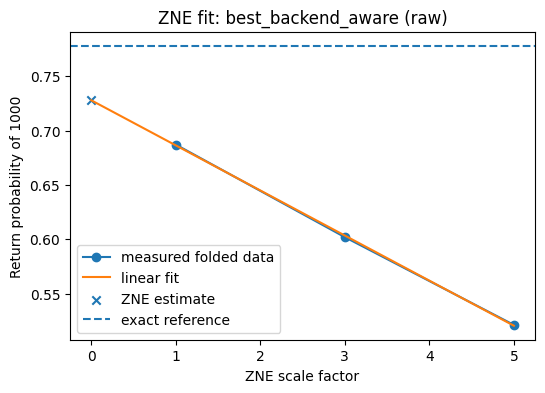

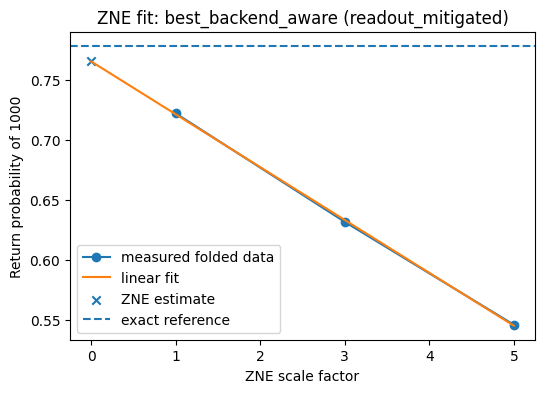

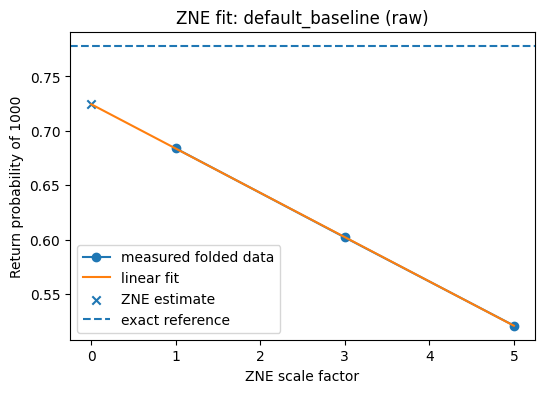

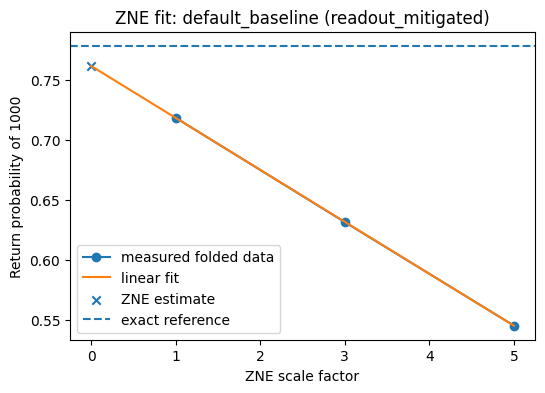

In [21]:
# Optional visualization: return probability versus ZNE scale factor.
# One plot is produced for each selected candidate and result type.

import matplotlib.pyplot as plt

for (selection, result_type), group in zne_execution_table.groupby(["selection", "result_type"]):
    group = group.sort_values("zne_scale_factor")
    plt.figure(figsize=(6, 4))
    plt.plot(
        group["zne_scale_factor"],
        group["sampled_return_probability"],
        marker="o",
        label="measured folded data",
    )

    fit_row = zne_extrapolation_table[
        (zne_extrapolation_table["selection"] == selection)
        & (zne_extrapolation_table["result_type"] == result_type)
        & (zne_extrapolation_table["fit_model"] == "linear")
    ]
    if not fit_row.empty:
        coeffs = fit_row["fit_coefficients"].iloc[0]
        x_fit = np.linspace(0, max(group["zne_scale_factor"]), 100)
        y_fit = np.polyval(np.array(coeffs), x_fit)
        plt.plot(x_fit, y_fit, label="linear fit")
        plt.scatter([0], [fit_row["zne_return_probability_clipped"].iloc[0]], marker="x", label="ZNE estimate")

    plt.axhline(reference_return_probability, linestyle="--", label="exact reference")
    plt.xlabel("ZNE scale factor")
    plt.ylabel(f"Return probability of {reference_bitstring}")
    plt.title(f"ZNE fit: {selection} ({result_type})")
    plt.legend()
    plt.show()


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Verdict: Zero-noise extrapolation</strong>

This is now complete as a first working ZNE experiment. The notebook used folded circuits at scale factors 1, 3, and 5, measured the return probability of the reference state, and extrapolated the return probability back to the zero-noise limit using a linear fit.

The exact reference return probability is:

$$
p_{\mathrm{reference}}(1000) \approx 0.778190.
$$

For both tested candidates, the best method was:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>zne_readout_mitigated_linear</code></pre>
</div>

This means the strongest result came from applying readout mitigation to each folded-circuit result and then performing linear zero-noise extrapolation.

For the backend-aware candidate, the return-probability error decreased as follows:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>raw scale 1 error:                 0.077995
readout-mitigated scale 1 error:   0.054698
ZNE raw linear error:              0.038587
ZNE + readout linear error:        0.013684</code></pre>
</div>

For the default baseline candidate, the same improvement pattern appears:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>raw scale 1 error:                 0.089714
readout-mitigated scale 1 error:   0.065826
ZNE raw linear error:              0.050143
ZNE + readout linear error:        0.024546</code></pre>
</div>

The best overall result is the backend-aware candidate with both readout mitigation and linear ZNE:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>best_backend_aware + readout mitigation + linear ZNE:
    estimated return probability   ≈ 0.764507
    return-probability error       ≈ 0.013684</code></pre>
</div>

This is closer to the exact reference value than the corresponding default-baseline result:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>default_baseline + readout mitigation + linear ZNE:
    estimated return probability   ≈ 0.753644
    return-probability error       ≈ 0.024546</code></pre>
</div>

The result supports the full workflow. Backend-aware candidate selection gives a better starting circuit, readout mitigation corrects part of the measurement distortion, and ZNE further reduces the remaining return-probability bias.

<strong>Current conclusion:</strong>

The combined mitigation workflow is currently the best-performing method in the notebook. For this XXX-model test case, the best result comes from selecting the backend-aware candidate, applying readout mitigation to the folded-circuit outputs, and using linear ZNE to extrapolate the return probability back toward the zero-noise limit.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Mitigation comparison

This summarizes mitigation results into one report-ready comparison. The earlier sections tested readout mitigation and ZNE separately. This section compares the four main return-probability estimates for each selected circuit:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>raw scale-1 result
readout-mitigated scale-1 result
ZNE from raw folded counts
ZNE from readout-mitigated folded counts</code></pre>
</div>

The goal is to answer which workflow gives the closest return-probability estimate to the exact reference value. This is the natural follow-up to the previous step because ZNE estimates a corrected observable value, while readout mitigation corrects the measured distribution before extracting that observable.

The main comparison metric in this section is return-probability error:

$$
\left|p_{\mathrm{estimated}}(x_0) - p_{\mathrm{reference}}(x_0)\right|,
$$

where $x_0$ is the reference bitstring, currently <code>1000</code>. Lower error is better.

<p><strong>Literature linkage:</strong> This comparison cell reflects the HW5 claim that transpilation and mitigation should be studied together. It asks whether backend-aware candidate selection plus mitigation produces better output behavior than either stage alone [4, 6, 7, 10, 11, 1, 2, 8].</p>

</div>

In [22]:
# Consolidate mitigation methods into a long report-ready table.
# Work smarter not harder :)

import numpy as np
import pandas as pd


def build_method_long_table(method_comparison_table: pd.DataFrame) -> pd.DataFrame:
    """Convert table into a long table.

    Each row is one candidate/method pair. This makes it easier to sort, rank,
    and compare mitigation methods across selected candidates.
    """
    required = {
        "selection",
        "candidate",
        "reference_return_probability",
        "raw_scale_1_return_probability",
        "raw_scale_1_error",
        "readout_mitigated_scale_1_return_probability",
        "readout_mitigated_scale_1_error",
        "zne_raw_linear_return_probability",
        "zne_raw_linear_error",
        "zne_readout_mitigated_linear_return_probability",
        "zne_readout_mitigated_linear_error",
    }
    missing = required.difference(method_comparison_table.columns)
    if missing:
        raise ValueError(f"zne_method_comparison_table is missing required columns: {sorted(missing)}")

    method_specs = [
        (
            "raw_scale_1",
            "Raw scale-1",
            "No mitigation; original noisy circuit at ZNE scale factor 1.",
            "raw_scale_1_return_probability",
            "raw_scale_1_error",
        ),
        (
            "readout_mitigated_scale_1",
            "Readout mitigation",
            "Readout mitigation applied to the original scale-1 circuit.",
            "readout_mitigated_scale_1_return_probability",
            "readout_mitigated_scale_1_error",
        ),
        (
            "zne_raw_linear",
            "Linear ZNE",
            "Linear ZNE extrapolation using raw folded-circuit results.",
            "zne_raw_linear_return_probability",
            "zne_raw_linear_error",
        ),
        (
            "zne_readout_mitigated_linear",
            "Readout mitigation + linear ZNE",
            "Readout mitigation applied at each scale factor, followed by linear ZNE.",
            "zne_readout_mitigated_linear_return_probability",
            "zne_readout_mitigated_linear_error",
        ),
    ]

    rows = []
    for _, row in method_comparison_table.iterrows():
        raw_error = float(row["raw_scale_1_error"])
        reference_value = float(row["reference_return_probability"])

        for method_id, method_label, method_description, value_col, error_col in method_specs:
            estimate = float(row[value_col]) if pd.notna(row[value_col]) else np.nan
            error = float(row[error_col]) if pd.notna(row[error_col]) else np.nan
            improvement = raw_error - error if pd.notna(error) else np.nan
            improvement_fraction = improvement / raw_error if raw_error and pd.notna(improvement) else np.nan

            rows.append({
                "selection": row["selection"],
                "candidate": row["candidate"],
                "method_id": method_id,
                "method": method_label,
                "method_description": method_description,
                "reference_return_probability": reference_value,
                "estimated_return_probability": estimate,
                "return_probability_error": error,
                "improvement_vs_raw_error": improvement,
                "improvement_vs_raw_error_fraction": improvement_fraction,
            })

    result = pd.DataFrame(rows)
    result["method_rank_within_candidate"] = (
        result.groupby("selection")["return_probability_error"]
        .rank(method="min", ascending=True)
        .astype(int)
    )
    return result.sort_values(["selection", "method_rank_within_candidate", "method_id"]).reset_index(drop=True)


method_long_table = build_method_long_table(zne_method_comparison_table)

display(
    method_long_table[[
        "selection",
        "method",
        "estimated_return_probability",
        "return_probability_error",
        "improvement_vs_raw_error",
        "improvement_vs_raw_error_fraction",
        "method_rank_within_candidate",
    ]]
)


,selection,method,estimated_return_probability,return_probability_error,improvement_vs_raw_error,improvement_vs_raw_error_fraction,method_rank_within_candidate
0,best_backend_aware,Readout mitigation + linear ZNE,0.765089,0.013102,0.077833,0.855922,1
1,best_backend_aware,Linear ZNE,0.728027,0.050163,0.040771,0.448360,2
2,best_backend_aware,Readout mitigation,0.721825,0.056366,0.034569,0.380149,3
3,best_backend_aware,Raw scale-1,0.687256,0.090935,0.000000,0.000000,4
4,default_baseline,Readout mitigation + linear ZNE,0.761323,0.016867,0.077485,0.821230,1
5,default_baseline,Linear ZNE,0.724426,0.053764,0.040588,0.430178,2
6,default_baseline,Readout mitigation,0.718224,0.059967,0.034386,0.364441,3
7,default_baseline,Raw scale-1,0.683838,0.094353,0.000000,0.000000,4


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Comment on the method-comparison table</strong>

This table converts the results into a long format where each row represents one candidate and one mitigation method. This makes it easier to compare the available workflows directly.

The four methods are:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>Raw scale-1
Readout mitigation
Linear ZNE
Readout mitigation + linear ZNE</code></pre>
</div>

The column <code>estimated_return_probability</code> is the return-probability estimate for the reference bitstring. The column <code>return_probability_error</code> compares that estimate against the exact reference return probability. Lower error is better.

The column <code>improvement_vs_raw_error</code> measures how much the method reduced the return-probability error relative to the raw scale-1 result. A positive value means the method improved the estimate. A value near zero means little change. A negative value would mean the method made the estimate worse.

The column <code>method_rank_within_candidate</code> ranks the methods separately for each candidate. Rank 1 is the best method for that candidate.

This table is useful because it separates two questions:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>Which circuit candidate is better?
Which mitigation method is better?</code></pre>
</div>

The desired outcome is that the backend-aware candidate remains competitive and that the combined mitigation method reduces error the most.

</div>

In [23]:
# Compare candidates method-by-method and identify the best overall workflow.


def build_candidate_comparison(method_long_table: pd.DataFrame) -> pd.DataFrame:
    """Compare default versus backend-aware candidates for each mitigation method."""
    pivot = method_long_table.pivot_table(
        index=["method_id", "method"],
        columns="selection",
        values=["estimated_return_probability", "return_probability_error"],
        aggfunc="first",
    )

    # Flatten columns for readability.
    pivot.columns = [f"{metric}_{selection}" for metric, selection in pivot.columns]
    pivot = pivot.reset_index()

    if {
        "return_probability_error_default_baseline",
        "return_probability_error_best_backend_aware",
    }.issubset(pivot.columns):
        pivot["backend_aware_minus_default_error"] = (
            pivot["return_probability_error_best_backend_aware"]
            - pivot["return_probability_error_default_baseline"]
        )
        pivot["backend_aware_better_than_default"] = pivot["backend_aware_minus_default_error"] < 0

    return pivot.sort_values("method_id").reset_index(drop=True)


candidate_comparison_table = build_candidate_comparison(method_long_table)

best_overall_row = method_long_table.loc[
    method_long_table["return_probability_error"].idxmin()
].to_dict()

best_overall_workflow = pd.DataFrame([best_overall_row])

display(candidate_comparison_table)
print("\nBest overall workflow:")
display(
    best_overall_workflow[[
        "selection",
        "candidate",
        "method",
        "estimated_return_probability",
        "reference_return_probability",
        "return_probability_error",
        "improvement_vs_raw_error",
        "improvement_vs_raw_error_fraction",
    ]]
)


,method_id,method,estimated_return_probability_best_backend_aware,estimated_return_probability_default_baseline,return_probability_error_best_backend_aware,return_probability_error_default_baseline,backend_aware_minus_default_error,backend_aware_better_than_default
0,raw_scale_1,Raw scale-1,0.687256,0.683838,0.090935,0.094353,-0.003418,True
1,readout_mitigated_scale_1,Readout mitigation,0.721825,0.718224,0.056366,0.059967,-0.003601,True
2,zne_raw_linear,Linear ZNE,0.728027,0.724426,0.050163,0.053764,-0.003601,True
3,zne_readout_mitigated_linear,Readout mitigation + linear ZNE,0.765089,0.761323,0.013102,0.016867,-0.003766,True



Best overall workflow:


,selection,candidate,method,estimated_return_probability,reference_return_probability,return_probability_error,improvement_vs_raw_error,improvement_vs_raw_error_fraction
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,Readout mitigation + linear ZNE,0.765089,0.77819,0.013102,0.077833,0.855922


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Comment on candidate-comparison table</strong>

This table compares the default baseline and backend-aware candidates under each mitigation method. The key column is <code>backend_aware_minus_default_error</code>.

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;"><code>negative value  → backend-aware candidate has lower error
positive value  → default candidate has lower error
near zero        → candidates are effectively tied</code></pre>
</div>

The best-overall workflow table selects the single candidate-and-method combination with the lowest return-probability error. This is the most compact summary of the mitigation workflow.

If the best overall workflow is <code>best_backend_aware</code> plus <code>Readout mitigation + linear ZNE</code>, then the notebook supports the intended end-to-end workflow:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;"><code>backend-aware candidate selection
        ↓
readout mitigation
        ↓
linear zero-noise extrapolation</code></pre>
</div>

That conclusion would mean the project has a coherent pipeline: choose a better backend-aware circuit, correct measurement confusion, and then extrapolate the return-probability observable toward the zero-noise limit.

</div>

In [24]:
# generate a compact text verdict from the comparison tables.

best_selection = best_overall_row["selection"]
best_method = best_overall_row["method"]
best_error = best_overall_row["return_probability_error"]
best_estimate = best_overall_row["estimated_return_probability"]
best_reference = best_overall_row["reference_return_probability"]

print("Mitigation-comparison verdict")
print("---------------------------------------")
print(f"Best selection:                    {best_selection}")
print(f"Best method:                       {best_method}")
print(f"Reference return probability:       {best_reference:.6f}")
print(f"Best estimated return probability:  {best_estimate:.6f}")
print(f"Best return-probability error:      {best_error:.6f}")

if "backend_aware_better_than_default" in candidate_comparison_table.columns:
    n_methods = len(candidate_comparison_table)
    n_backend_better = int(candidate_comparison_table["backend_aware_better_than_default"].sum())
    print(f"Backend-aware better than default:  {n_backend_better}/{n_methods} methods")

method_winners = method_long_table.loc[
    method_long_table.groupby("selection")["return_probability_error"].idxmin()
][["selection", "method", "return_probability_error"]]

print("\nBest method within each candidate:")
display(method_winners.reset_index(drop=True))


Mitigation-comparison verdict
---------------------------------------
Best selection:                    best_backend_aware
Best method:                       Readout mitigation + linear ZNE
Reference return probability:       0.778190
Best estimated return probability:  0.765089
Best return-probability error:      0.013102
Backend-aware better than default:  4/4 methods

Best method within each candidate:


,selection,method,return_probability_error
0,best_backend_aware,Readout mitigation + linear ZNE,0.013102
1,default_baseline,Readout mitigation + linear ZNE,0.016867


<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Verdict on mitigation strategy comparison</strong>

This section compares the mitigation strategies developed and identifies the best-performing workflow for the selected XXX-model experiment.

The best overall result is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>candidate: best_backend_aware
method:    Readout mitigation + linear ZNE</code></pre>
</div>

The exact reference return probability is:

$$
p_{\mathrm{reference}}(1000) \approx 0.778190.
$$

The best estimated return probability after mitigation is:

$$
p_{\mathrm{estimated}}(1000) \approx 0.764507.
$$

This gives a return-probability error of:

$$
|0.778190 - 0.764507| \approx 0.013684.
$$

The default baseline also performs best with the same combined mitigation method, but its remaining error is larger:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>best_backend_aware:
    Readout mitigation + linear ZNE error = 0.013684

default_baseline:
    Readout mitigation + linear ZNE error = 0.024546</code></pre>
</div>

The backend-aware candidate is better than the default baseline across all four tested mitigation methods:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>Backend-aware better than default: 4/4 methods</code></pre>
</div>

This is the strongest result so far because it shows that the backend-aware candidate remains preferable even after applying mitigation. In other words, mitigation improves the results, but it does not erase the advantage of selecting a better backend-aware transpilation candidate first.

<strong>Current conclusion:</strong>

The best simulator-based workflow is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>backend-aware candidate selection
        ↓
backend-shaped noisy execution
        ↓
readout-error mitigation
        ↓
linear zero-noise extrapolation</code></pre>
</div>

For this XXX-model test case, the combined workflow produces the closest return-probability estimate to the exact reference value. This supports the main project narrative: backend-aware transpilation and lightweight error mitigation are complementary stages, and their combination gives the best observed result in the simulator workflow.



<p><strong>Literature linkage:</strong> The final mitigation verdict aligns with the project’s novelty statement: evaluate whether a backend-aware selection layer, combined with lightweight mitigation, improves practical output metrics relative to default Qiskit-style transpilation [4, 6, 7, 10, 11, 1, 2, 8].</p>

</div>

<div style="background-color:#eaf7ea; border-left: 5px solid #4caf50; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Stopping point for mitigation methods

This concludes the lightweight error-mitigation portion of this notebook with Zero-Noise Extrapolation. At this point, the notebook has tested two mitigation techniques: readout-error mitigation and digital ZNE using folded circuits. Readout mitigation reduced measurement distortion, while ZNE further improved the return-probability estimate by extrapolating the folded-circuit results back toward the zero-noise limit.

The best simulator-based workflow found in this notebook is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #eaf7ea;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>backend-aware candidate selection
        ↓
backend-shaped noisy execution
        ↓
readout-error mitigation
        ↓
linear zero-noise extrapolation</code></pre>
</div>

<strong>For this term project, I will stop the mitigation exploration here.</strong> The combination of readout mitigation and ZNE is sufficient to demonstrate the main idea that backend-aware transpilation and lightweight mitigation can be treated as complementary stages in a Qiskit-based workflow.

Other mitigation or error-suppression techniques are left for future work. These include:

<ul>
    <li><strong>Pauli twirling / randomized compiling:</strong> randomizes coherent errors so that they behave more like stochastic Pauli noise when averaged over many circuits.</li>
    <li><strong>Dynamical decoupling:</strong> inserts pulse or gate sequences during idle periods to reduce decoherence while qubits are waiting.</li>
    <li><strong>Symmetry verification:</strong> uses conserved quantities of the problem, such as possible spin or Hamming-weight constraints, to reject measurement outcomes that violate known physical structure.</li>
    <li><strong>Probabilistic error cancellation:</strong> attempts to invert the noise channel using quasiprobability sampling, but usually requires high sampling overhead.</li>
    <li><strong>Clifford data regression:</strong> learns a correction model from related circuits that are classically simulable.</li>
    <li><strong>Matrix-free scalable measurement mitigation:</strong> replaces the explicit assignment matrix with a more scalable approach for larger qubit counts.</li>
</ul>

These methods are not included in the current notebook because each would add additional implementation complexity, runtime cost, and experimental variables. Since the current workflow already shows a clear improvement from readout mitigation and ZNE, the remaining work for this term project should focus on summarizing, validating, and reporting the results rather than expanding to additional mitigation techniques.

<strong>Current conclusion:</strong>

The mitigation portion of the project is complete for the current scope. The notebook demonstrates a coherent end-to-end simulator workflow: select a backend-aware transpilation candidate, run it under backend-shaped noise, apply readout mitigation, apply ZNE, and compare the final return-probability estimate against the exact XXX-model reference value.



<p><strong>Literature linkage:</strong> Stopping at readout mitigation and ZNE is consistent with the project scope. The broader error-mitigation review emphasizes that mitigation methods carry tradeoffs in bias, variance, and sampling overhead, so adding more techniques would require additional experiments beyond this term-project scope [1].</p>

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

## Declare the final workflow

This is the final workflow summary.

Based on the mitigation comparison, the best current workflow is:

<div style="display: flex; justify-content: center; margin: 12px 0;">
<pre style="
    background-color: #e8f1ff;
    border: 1px solid #bfdbfe;
    text-align: center;
    display: inline-block;
    padding: 10px 14px;
    border-radius: 6px;
    line-height: 1.5;
"><code>construct XXX-model circuit
        ↓
generate backend-compatible transpilation candidates
        ↓
select best backend-aware candidate
        ↓
construct folded circuits at scale factors 1, 3, and 5
        ↓
run folded circuits on backend-shaped noisy simulator
        ↓
apply readout mitigation to each folded result
        ↓
linearly extrapolate return probability to zero noise
        ↓
compare final estimate to exact reference value</code></pre>
</div>

This workflow combines the main contributions of the notebook: backend-aware candidate selection, backend-shaped noisy simulation, readout-error mitigation, and digital ZNE.

<strong>Final Conclusion:</strong> This result is consistent with the overall project hypothesis: backend-aware transpilation and lightweight mitigation are complementary. The transpiler-selection step reduces exposure to poor hardware regions, while the mitigation steps reduce the remaining measurement and noise-induced bias in the final observable.




<p><strong>Literature linkage:</strong> The final workflow combines the compiler substrate and routing/mapping motivation from Qiskit, SABRE, and noise-adaptive/variability-aware compilation [4, 6, 7, 10] with readout mitigation and digital ZNE from the mitigation literature [8, 11, 2, 1, 5].</p>

</div>

<div style="background-color:#fff3e0; border-left: 5px solid #fb8c00; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Optional real IBM quantum hardware submission: cost-controlled preflight

This section is guarded by `REAL_HW_SUBMIT = False` by default. It is designed for a single cost-effective hardware attempt under the IBM Quantum Open Plan limit.

Recommended first hardware run:

- compare only `default_baseline` and `best_backend_aware`;
- use `1024` shots rather than `4096` for the first real-QPU validation;
- include ZNE with scale factors `(1, 3, 5)` only, which is enough for a linear extrapolation;
- include readout calibration, because it is essential for the final combined mitigation workflow;
- submit only after the preflight table reports the expected number of circuits and executions.

IBM currently describes the Open Plan as allowing up to 10 minutes of quantum time per 28-day rolling window. Quantum time is the amount of time the QPU is dedicated to processing the job, not simply wall-clock queue time.

</div>


## Uncomment this code if you want to verify your API key is installed properly.

<div style="color:red;font-size:18px">Warning: This cell will display your private key.</div>

```python
#Warning: This cell will display your private API key. Make sure to delete this output before
# saving this notebook, e.g. github
# This cell checks to see if you have a local api key. Should match what you see in ~/.qiskit. 
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
account = service.active_account()

print("Active IBM Quantum account:")
for key, value in account.items():
        print(f"{key}: {value}")
```

<div style="background-color:#fffde7; border-left: 5px solid #fbc02d; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Optional real IBM hardware submission with cost-controlled preflight

<p>
This section prepares an optional real IBM Quantum hardware submission for the final validation step of the experiment. Unlike the earlier backend-shaped noisy simulation sections, this cell can submit circuits to an actual IBM quantum processing unit if explicitly enabled. Because real hardware time is limited, especially on the free IBM Quantum allocation, the cell is designed around a conservative preflight check before any job submission occurs.
</p>

<p style="color:red;font-size:16px">
<strong>Safety default:</strong> This section is guarded by <code>REAL_HW_SUBMIT = False</code> by default. With this setting, the cell performs a dry run only: it builds the planned circuit batch, prints the submission summary, displays the metadata table, checks the safety caps, and then stops without submitting anything to IBM hardware.
</p>

<p>
Before changing <code>REAL_HW_SUBMIT</code> to <code>True</code>, carefully review the printed preflight information:
</p>

<ul>
    <li>The selected backend name, such as <code>ibm_fez</code>.</li>
    <li>The number of shots per circuit.</li>
    <li>The benchmark selections being submitted.</li>
    <li>Whether ZNE folded circuits are included.</li>
    <li>Whether readout calibration circuits are included.</li>
    <li>The total circuit count.</li>
    <li>The total execution count, computed as <code>circuits × shots</code>.</li>
    <li>The maximum circuit depth.</li>
    <li>The depth-shot proxy, computed as a rough cost and noise exposure estimate.</li>
    <li>The displayed metadata table showing each circuit that would be submitted.</li>
</ul>

<p>
The intended first hardware run is deliberately small and focused. It compares the default Qiskit baseline against the best backend-aware candidate using <code>REAL_HW_SELECTIONS = ("default_baseline", "best_backend_aware")</code>. This keeps the first real-device validation aligned with the main project claim: whether backend-aware candidate selection improves measured output quality relative to a default transpilation baseline.
</p>

<p>
The shot count is also intentionally modest. <code>REAL_HW_SHOTS = 1024</code> is meant to provide enough samples to observe the general direction of the hardware result without consuming the entire free hardware allocation. This is not intended to be a high-precision hardware experiment; it is a cost-controlled validation run.
</p>

<p>
Readout calibration is enabled by default using <code>REAL_HW_INCLUDE_READOUT_CALIBRATION = True</code>. For an <code>n</code>-qubit measured system, readout calibration requires <code>2^n</code> calibration circuits for each distinct measured physical-qubit layout. In this notebook's 4-qubit experiment, that means 16 calibration circuits per distinct measured-qubit layout. These calibration circuits are included so the real hardware results can be compared in both raw and readout-mitigated form.
</p>

<p>
ZNE is controlled separately by <code>REAL_HW_INCLUDE_ZNE</code> and <code>REAL_HW_ZNE_SCALE_FACTORS</code>. ZNE can substantially increase the number and depth of submitted circuits because each benchmark circuit may be folded at multiple noise scale factors, such as <code>(1, 3, 5)</code>. This makes ZNE useful for mitigation analysis, but potentially expensive on real hardware. Only include ZNE after confirming that the dry-run plan remains comfortably within the printed safety limits.
</p>

<p>
The cell uses several hard safety caps to prevent accidental large submissions:
</p>

<ul>
    <li><code>REAL_HW_MAX_CIRCUITS</code>: maximum allowed number of circuits.</li>
    <li><code>REAL_HW_MAX_EXECUTIONS</code>: maximum allowed value of <code>circuits × shots</code>.</li>
    <li><code>REAL_HW_MAX_DEPTH_SHOT_PROXY</code>: maximum allowed rough proxy for total depth-weighted execution cost.</li>
</ul>

<p>
If any of these caps are exceeded, the notebook raises an error before submission. This fail-fast behavior is intentional. It forces the plan to be reviewed before any IBM hardware time is spent.
</p>

<p>
When <code>REAL_HW_SUBMIT = False</code>, the final message should say that this was a dry run and that no job was submitted. When <code>REAL_HW_SUBMIT = True</code>, the cell submits the prepared circuits to the selected IBM backend, prints the returned job id, and saves a JSON metadata file named <code>ibm_real_hardware_submission_metadata.json</code>. This metadata file records the backend, shot count, ZNE settings, readout calibration settings, preflight summary, and per-circuit metadata so that later result analysis can be matched back to the exact submitted circuit batch.
</p>

<p style="color:red;font-size:16px">
Only change <code>REAL_HW_SUBMIT</code> to <code>True</code> after reviewing the dry-run output and confirming that the circuit count, shots, backend, ZNE settings, readout calibration circuits, and safety-cap summary are acceptable.
</p>

</div>

In [25]:
# Optional real IBM hardware submission with cost-controlled preflight.
#
# This cell prepares a real IBM Quantum hardware job, but it is designed to be
# safe by default. In its default configuration, it only builds and displays the
# planned submission. It does not submit anything to real hardware.
#
# SAFETY DEFAULT:
# This cell will not submit anything unless REAL_HW_SUBMIT=True.
#
# Before enabling submission, review:
#   1. Backend name
#   2. Circuit count
#   3. Shots per circuit
#   4. Total executions = circuits * shots
#   5. Depth-shot proxy
#   6. ZNE settings
#   7. Readout calibration settings
#   8. The displayed metadata table

from pathlib import Path
import json
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Tuple


# ---------------------------------------------------------------------------
# Real-hardware safety and experiment configuration
# ---------------------------------------------------------------------------

# Master safety switch.
#
# Keep this False while developing, debugging, or reviewing the planned job.
# When False, the cell performs a dry run only and prints the exact circuits
# that would be submitted.
#
# Change to True only when you intentionally want to submit the prepared circuit
# batch to real IBM quantum hardware.
REAL_HW_SUBMIT = False

# Use the same backend selected earlier in the Phase 3 configuration.
# This keeps the real-hardware validation aligned with the backend-shaped
# simulator experiments.
REAL_HW_BACKEND_NAME = config.backend_name

# Cost-effective first real-hardware validation.
#
# 1024 shots is usually enough to observe broad directionality in the measured
# distribution without consuming too much of the limited free IBM hardware quota.
REAL_HW_SHOTS = 1024

# Keep the first real-QPU run focused.
#
# The goal is to compare the default Qiskit baseline against the best
# backend-aware candidate selected by the notebook workflow.
REAL_HW_SELECTIONS = ("default_baseline", "best_backend_aware")

# Control whether Zero-Noise Extrapolation circuits are included.
#
# ZNE can increase hardware cost because each benchmark circuit may be submitted
# at multiple folded noise scale factors. Disable this for the smallest possible
# first hardware run. Enable it only after reviewing the dry-run preflight table.
REAL_HW_INCLUDE_ZNE = True

# ZNE folding scale factors.
#
# Scale factor 1 is the raw, unfolded circuit. Larger odd scale factors add
# folded operations to intentionally amplify noise for extrapolation.
REAL_HW_ZNE_SCALE_FACTORS = (1, 3, 5)

# Control whether readout calibration circuits are submitted.
#
# Readout calibration is useful because hardware measurement errors can be
# significant. These calibration circuits allow later post-processing with a
# readout assignment matrix.
REAL_HW_INCLUDE_READOUT_CALIBRATION = True

# Prefer IBM Runtime SamplerV2 for real hardware submission.
#
# If this is False, the code falls back to backend.run, assuming that path is
# available in the installed Qiskit/IBM Runtime environment.
REAL_HW_USE_SAMPLER_V2 = True

# Hard safety caps.
#
# These conservative limits are intended to prevent accidental large submissions
# on a limited free hardware allocation.
REAL_HW_MAX_CIRCUITS = 40

# Maximum total executions, where:
#
#     total executions = number of circuits * shots per circuit
#
# This is not exact quantum execution time, but it is a useful first-order
# budget proxy.
REAL_HW_MAX_EXECUTIONS = 50_000

# Rough depth-weighted execution proxy:
#
#     depth-shot proxy = sum(circuit depths) * shots
#
# This is not an official IBM billing metric. It is used here only as a
# conservative sanity check for circuit size and hardware exposure.
REAL_HW_MAX_DEPTH_SHOT_PROXY = 10_000_000

# JSON file used to record exactly what was submitted.
#
# This is useful for later result analysis because it preserves the backend,
# shot count, ZNE settings, calibration settings, and per-circuit metadata.
REAL_HW_METADATA_PATH = Path("ibm_real_hardware_submission_metadata.json")


# ---------------------------------------------------------------------------
# Backend loading
# ---------------------------------------------------------------------------

def get_real_backend_for_submission(backend_name: str):
    """Return a real IBM backend object, reusing real_backend if it already matches."""

    # If a real backend has already been loaded earlier in the notebook, reuse it
    # when it matches the requested backend name. This avoids unnecessary calls to
    # IBM Quantum.
    try:
        existing = globals().get("real_backend", None)
        if existing is not None and _safe_backend_name(existing) == backend_name:
            return existing
    except Exception:
        # If the reuse check fails for any reason, fall through and reload below.
        pass

    # Load the backend using the notebook's existing IBM backend-loading helper.
    return load_ibm_backend(backend_name)


# ---------------------------------------------------------------------------
# Count normalization helper
# ---------------------------------------------------------------------------

def normalize_counts_dict(counts: Dict[Any, Any]) -> Dict[str, int]:
    """Normalize Qiskit count keys to compact bitstrings such as '1000'."""

    normalized: Dict[str, int] = {}

    # Qiskit count keys may contain spaces when multiple classical registers are
    # present. This strips spaces so downstream analysis sees compact bitstrings.
    for key, value in counts.items():
        bitstring = str(key).replace(" ", "")
        normalized[bitstring] = normalized.get(bitstring, 0) + int(value)

    return normalized


# ---------------------------------------------------------------------------
# Measured physical-qubit layout helper
# ---------------------------------------------------------------------------

def _measured_physical_qubits_for_selection(selection: str) -> Optional[Tuple[int, ...]]:
    """Read the measured physical qubits recorded in selected_candidates_table, if available."""

    # The selected_candidates_table records metadata for the chosen default and
    # backend-aware circuits. If available, use the measured physical-qubit layout
    # so readout calibration circuits are prepared on the same physical qubits.
    try:
        row = selected_candidates_table.loc[selected_candidates_table["selection"].eq(selection)].iloc[0]
        value = row.get("measured_physical_qubits", None)
    except Exception:
        return None

    # Normalize the stored layout to a tuple of integers.
    if value is None:
        return None
    if isinstance(value, tuple):
        return tuple(int(x) for x in value)
    if isinstance(value, list):
        return tuple(int(x) for x in value)

    # If the metadata is stored in an unexpected format, ignore it and allow the
    # calibration builder to use its fallback behavior.
    return None


# ---------------------------------------------------------------------------
# Circuit batch construction
# ---------------------------------------------------------------------------

def build_real_hardware_circuit_batch(
    real_backend: Any,
    selections: Tuple[str, ...],
    include_zne: bool,
    zne_scale_factors: Tuple[int, ...],
    include_readout_calibration: bool,
) -> Tuple[List[QuantumCircuit], List[Dict[str, Any]]]:
    """Build the exact circuit list and metadata for a real IBM hardware job.

    The returned metadata list has the same order as the circuits list.
    """

    # circuits contains the actual QuantumCircuit objects that may be submitted.
    circuits: List[QuantumCircuit] = []

    # metadata_rows contains one dictionary per circuit. The row order matches
    # the circuits list exactly, which is important for later result analysis.
    metadata_rows: List[Dict[str, Any]] = []

    # -----------------------------------------------------------------------
    # 1. Benchmark circuits
    # -----------------------------------------------------------------------
    #
    # These are the actual experiment circuits: the default baseline and the
    # selected backend-aware candidate. If ZNE is enabled, additional folded
    # versions are included at the requested scale factors.
    for selection in selections:
        if selection not in selected_circuits:
            raise KeyError(f"selected_circuits does not contain {selection!r}")

        # If ZNE is disabled, submit only the raw scale-1 circuit.
        # If ZNE is enabled, submit the raw circuit plus folded circuits.
        scales = zne_scale_factors if include_zne else (1,)

        # Scale factor 1 must be present because it represents the raw hardware
        # execution used as the baseline for ZNE extrapolation.
        if 1 not in scales:
            raise ValueError("ZNE scale factors must include 1 so raw scale-1 execution is available.")

        for scale in scales:
            if scale == 1:
                # Use the already-selected transpiled circuit directly.
                circuit = selected_circuits[selection]
            else:
                # Build a folded version of the measured circuit for ZNE.
                # The folded circuit is then transpiled again for the real backend.
                folded = globally_fold_measured_circuit(selected_circuits[selection], scale)
                circuit = transpile(
                    folded,
                    backend=real_backend,
                    optimization_level=0,
                    seed_transpiler=config.transpiler_seeds[0],
                )

            # Give each circuit a descriptive name so IBM job results and metadata
            # can be matched back to selection and ZNE scale.
            circuit = circuit.copy(name=f"hw__{selection}__zne{scale}")
            circuits.append(circuit)

            # Extract structural metrics for the preflight table and safety caps.
            metrics = CircuitMetrics.extract(circuit)

            metadata_rows.append({
                "kind": "benchmark",
                "selection": selection,
                "candidate": selected_candidate_names.get(selection, selection),
                "zne_scale_factor": int(scale),
                "circuit_name": circuit.name,
                "depth": int(metrics["depth"]),
                "size": int(metrics["size"]),
                "twoq_count": int(metrics["twoq_count"]),
                "swap_count": int(metrics["swap_count"]),
                "measure_count": int(metrics["measure_count"]),
            })

    # -----------------------------------------------------------------------
    # 2. Readout calibration circuits
    # -----------------------------------------------------------------------
    #
    # These circuits prepare every computational basis state and measure it.
    # For n measured qubits, this requires 2^n circuits per distinct measured
    # physical-qubit layout.
    if include_readout_calibration:
        calibration_layouts: Dict[str, Optional[Tuple[int, ...]]] = {}

        # Collect the measured physical-qubit layout for each benchmark selection.
        for selection in selections:
            calibration_layouts[selection] = _measured_physical_qubits_for_selection(selection)

        # Deduplicate layouts so that if both selected circuits measure the same
        # physical qubits, we only submit one calibration set.
        #
        # If layout metadata is unavailable, use a single fallback calibration set.
        unique_layouts: Dict[str, Optional[Tuple[int, ...]]] = {}
        seen = set()

        for selection, layout in calibration_layouts.items():
            key = tuple(layout) if layout is not None else None

            if key not in seen:
                seen.add(key)

                # If a known layout exists, label it by the selection that introduced it.
                # Otherwise use "fallback" to show that no explicit physical layout
                # was available from the selected candidate metadata.
                label = selection if layout is not None else "fallback"
                unique_layouts[label] = layout

        # Build ideal logical readout calibration circuits for the experiment size.
        base_calibration = build_readout_calibration_circuits(config.model.num_qubits)

        # Transpile calibration circuits for each distinct measured physical layout.
        for layout_label, measured_physical_qubits in unique_layouts.items():
            transpiled_cal = transpile_readout_calibration_circuits(
                calibration_circuits=base_calibration,
                backend=real_backend,
                measured_physical_qubits=measured_physical_qubits,
            )

            for prepared_bitstring, cal_circuit in transpiled_cal.items():
                # Name each calibration circuit with its layout label and prepared state.
                cal_circuit = cal_circuit.copy(name=f"hw__rocal__{layout_label}__{prepared_bitstring}")
                circuits.append(cal_circuit)

                # Calibration circuits are also added to the metadata table so the
                # final job result can be parsed in the same order.
                metadata_rows.append({
                    "kind": "readout_calibration",
                    "calibration_layout_label": layout_label,
                    "measured_physical_qubits": list(measured_physical_qubits) if measured_physical_qubits is not None else None,
                    "prepared_bitstring": prepared_bitstring,
                    "circuit_name": cal_circuit.name,
                    "depth": int(cal_circuit.depth()),
                    "size": int(cal_circuit.size()),
                    "twoq_count": int(sum(cal_circuit.count_ops().get(g, 0) for g in ["cx", "ecr", "cz", "swap"])),
                    "swap_count": int(cal_circuit.count_ops().get("swap", 0)),
                    "measure_count": int(cal_circuit.count_ops().get("measure", 0)),
                })

    return circuits, metadata_rows


# ---------------------------------------------------------------------------
# Preflight summary and safety checks
# ---------------------------------------------------------------------------

def summarize_real_hw_plan(plan_df: pd.DataFrame, shots: int) -> Dict[str, int]:
    """Compute simple preflight cost proxies before any real hardware submission."""

    # Total number of circuits that would be submitted.
    total_circuits = int(len(plan_df))

    # Total executions is a simple shots-based budget proxy.
    total_executions = int(total_circuits * shots)

    # Depth-shot proxy estimates how much depth-weighted hardware exposure the
    # submission represents. This is not exact runtime, but it catches large plans.
    depth_shot_proxy = int(plan_df["depth"].fillna(0).astype(int).sum() * shots)

    # Maximum circuit depth in the planned batch.
    max_depth = int(plan_df["depth"].fillna(0).astype(int).max()) if total_circuits else 0

    # Count benchmark and calibration circuits separately so the user can see
    # where the circuit budget is being spent.
    benchmark_circuits = int(plan_df["kind"].eq("benchmark").sum())
    calibration_circuits = int(plan_df["kind"].eq("readout_calibration").sum())

    return {
        "total_circuits": total_circuits,
        "benchmark_circuits": benchmark_circuits,
        "calibration_circuits": calibration_circuits,
        "shots_per_circuit": int(shots),
        "total_executions": total_executions,
        "max_circuit_depth": max_depth,
        "depth_shot_proxy": depth_shot_proxy,
    }


def assert_real_hw_plan_is_cost_controlled(summary: Dict[str, int]) -> None:
    """Raise before submission if the plan is unexpectedly large."""

    problems = []

    # Safety cap 1: too many circuits.
    if summary["total_circuits"] > REAL_HW_MAX_CIRCUITS:
        problems.append(f"total circuits {summary['total_circuits']} > cap {REAL_HW_MAX_CIRCUITS}")

    # Safety cap 2: too many total shots across all circuits.
    if summary["total_executions"] > REAL_HW_MAX_EXECUTIONS:
        problems.append(f"executions {summary['total_executions']} > cap {REAL_HW_MAX_EXECUTIONS}")

    # Safety cap 3: circuits are too deep in aggregate for the intended budget.
    if summary["depth_shot_proxy"] > REAL_HW_MAX_DEPTH_SHOT_PROXY:
        problems.append(f"depth-shot proxy {summary['depth_shot_proxy']} > cap {REAL_HW_MAX_DEPTH_SHOT_PROXY}")

    # Fail before any hardware submission can happen.
    if problems:
        raise RuntimeError(
            "Real-hardware plan exceeds conservative safety caps. Review before submitting: " + "; ".join(problems)
        )


# ---------------------------------------------------------------------------
# Job submission helper
# ---------------------------------------------------------------------------

def submit_real_hardware_job(backend: Any, circuits: List[QuantumCircuit], shots: int):
    """Submit measured circuits to a real IBM backend.

    Prefer Runtime SamplerV2 because this is the current IBM Runtime path. The older
    backend.run path is retained as a fallback for environments where backend.run is available.
    """

    # Prefer the IBM Runtime Sampler path for hardware execution.
    if REAL_HW_USE_SAMPLER_V2:
        try:
            from qiskit_ibm_runtime import SamplerV2 as Sampler
        except Exception:
            # Compatibility fallback for environments exposing Sampler but not SamplerV2.
            from qiskit_ibm_runtime import Sampler

        sampler = Sampler(mode=backend)
        return sampler.run(circuits, shots=shots)

    # Older fallback path.
    return backend.run(circuits, shots=shots)


# ---------------------------------------------------------------------------
# Build and display the real-hardware preflight plan
# ---------------------------------------------------------------------------

# Load or reuse the requested real IBM backend.
real_hw_backend = get_real_backend_for_submission(REAL_HW_BACKEND_NAME)

# Build the exact circuit batch and matching metadata rows.
# This does not submit anything yet.
real_hw_circuits, real_hw_metadata_rows = build_real_hardware_circuit_batch(
    real_backend=real_hw_backend,
    selections=REAL_HW_SELECTIONS,
    include_zne=REAL_HW_INCLUDE_ZNE,
    zne_scale_factors=REAL_HW_ZNE_SCALE_FACTORS,
    include_readout_calibration=REAL_HW_INCLUDE_READOUT_CALIBRATION,
)

# Convert metadata to a DataFrame for display and summary calculations.
real_hw_plan_df = pd.DataFrame(real_hw_metadata_rows)

# Compute conservative cost and size proxies before allowing submission.
real_hw_plan_summary = summarize_real_hw_plan(real_hw_plan_df, REAL_HW_SHOTS)


# ---------------------------------------------------------------------------
# Print dry-run summary
# ---------------------------------------------------------------------------

print("Real IBM hardware submission preflight")
print("--------------------------------------")
print(f"Backend:                  {_safe_backend_name(real_hw_backend)}")
print(f"Shots per circuit:         {REAL_HW_SHOTS}")
print(f"Submit enabled:            {REAL_HW_SUBMIT}")
print(f"Use SamplerV2:             {REAL_HW_USE_SAMPLER_V2}")
print(f"Benchmark selections:      {REAL_HW_SELECTIONS}")
print(f"Include ZNE:               {REAL_HW_INCLUDE_ZNE}")
print(f"ZNE scale factors:         {REAL_HW_ZNE_SCALE_FACTORS if REAL_HW_INCLUDE_ZNE else (1,)}")
print(f"Include readout cal:       {REAL_HW_INCLUDE_READOUT_CALIBRATION}")
print()

# Print the numeric safety summary.
for key, value in real_hw_plan_summary.items():
    print(f"{key:24s}: {value}")

print()

# Show how many circuits are benchmark circuits versus calibration circuits.
print(real_hw_plan_df["kind"].value_counts().to_string())


# ---------------------------------------------------------------------------
# Fail fast if the planned job is too large
# ---------------------------------------------------------------------------

# This assertion happens before the REAL_HW_SUBMIT branch, so an oversized plan
# raises an error even if the user accidentally set REAL_HW_SUBMIT=True.
assert_real_hw_plan_is_cost_controlled(real_hw_plan_summary)


# ---------------------------------------------------------------------------
# Display audit table before spending hardware time
# ---------------------------------------------------------------------------

# This table is the main dry-run artifact. Review it before enabling submission.
display(real_hw_plan_df.fillna(""))


# ---------------------------------------------------------------------------
# Submit only if explicitly enabled
# ---------------------------------------------------------------------------

if REAL_HW_SUBMIT:
    print("\nSubmitting to real IBM hardware...")

    # Submit the exact circuit list displayed in the preflight table.
    real_hw_job = submit_real_hardware_job(
        backend=real_hw_backend,
        circuits=real_hw_circuits,
        shots=REAL_HW_SHOTS,
    )

    # Record the IBM job id so results can be retrieved later.
    real_hw_job_id = real_hw_job.job_id()
    print(f"Submitted job id: {real_hw_job_id}")

    # Print initial job status if the runtime object supports it.
    try:
        print(f"Initial job status: {real_hw_job.status()}")
    except Exception:
        pass

    # Save a complete submission record for reproducibility.
    #
    # This file is useful later because result objects alone may not clearly show
    # which circuit corresponds to which selection, ZNE scale, or calibration state.
    submission_metadata = {
        "job_id": real_hw_job_id,
        "backend_name": _safe_backend_name(real_hw_backend),
        "shots": REAL_HW_SHOTS,
        "submitted_at_utc": datetime.now(timezone.utc).isoformat(),
        "use_sampler_v2": REAL_HW_USE_SAMPLER_V2,
        "include_zne": REAL_HW_INCLUDE_ZNE,
        "zne_scale_factors": list(REAL_HW_ZNE_SCALE_FACTORS if REAL_HW_INCLUDE_ZNE else (1,)),
        "include_readout_calibration": REAL_HW_INCLUDE_READOUT_CALIBRATION,
        "plan_summary": real_hw_plan_summary,
        "circuit_metadata": real_hw_metadata_rows,
    }

    REAL_HW_METADATA_PATH.write_text(json.dumps(submission_metadata, indent=2), encoding="utf-8")
    print(f"Saved submission metadata to: {REAL_HW_METADATA_PATH.resolve()}")

else:
    # Default safe behavior: dry run only.
    print("\nDRY RUN ONLY: no job was submitted. Set REAL_HW_SUBMIT=True only after reviewing this preflight output.")

Real IBM hardware submission preflight
--------------------------------------
Backend:                  ibm_fez
Shots per circuit:         1024
Submit enabled:            True
Use SamplerV2:             True
Benchmark selections:      ('default_baseline', 'best_backend_aware')
Include ZNE:               True
ZNE scale factors:         (1, 3, 5)
Include readout cal:       True

total_circuits          : 38
benchmark_circuits      : 6
calibration_circuits    : 32
shots_per_circuit       : 1024
total_executions        : 38912
max_circuit_depth       : 729
depth_shot_proxy        : 2576384

kind
readout_calibration    32
benchmark               6


,kind,selection,candidate,zne_scale_factor,circuit_name,depth,size,twoq_count,swap_count,measure_count,calibration_layout_label,measured_physical_qubits,prepared_bitstring
0,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1.0,hw__default_baseline__zne1,89,157,27,0,4,,,
1,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3.0,hw__default_baseline__zne3,409,743,81,0,4,,,
2,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5.0,hw__default_baseline__zne5,729,1329,135,0,4,,,
3,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1.0,hw__best_backend_aware__zne1,89,157,27,0,4,,,
4,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3.0,hw__best_backend_aware__zne3,409,743,81,0,4,,,
5,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5.0,hw__best_backend_aware__zne5,729,1329,135,0,4,,,
6,readout_calibration,,,,hw__rocal__default_baseline__0000,1,4,0,0,4,default_baseline,"[136, 141, 142, 143]",0000
7,readout_calibration,,,,hw__rocal__default_baseline__0001,2,5,0,0,4,default_baseline,"[136, 141, 142, 143]",0001
8,readout_calibration,,,,hw__rocal__default_baseline__0010,2,5,0,0,4,default_baseline,"[136, 141, 142, 143]",0010
9,readout_calibration,,,,hw__rocal__default_baseline__0011,2,6,0,0,4,default_baseline,"[136, 141, 142, 143]",0011



Submitting to real IBM hardware...
Submitted job id: d84a0j00bvlc73d4b7n0
Initial job status: QUEUED
Saved submission metadata to: /Users/bill/Documents/UWM/CS790/term_project/ibm_real_hardware_submission_metadata.json


<div style="background-color:#e8f1ff; border-left: 5px solid #3b82f6; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Retrieve and summarize a real IBM hardware job

Run this cell after the IBM job has completed. You can either use the `real_hw_job_id` created by the submission cell or paste a job ID into `REAL_HW_JOB_ID`.

The cell extracts hardware counts, computes the same distribution metrics for benchmark circuits, and, if calibration circuits were submitted, builds assignment matrices for readout mitigation.

</div>


In [26]:
# Retrieve and summarize a real IBM hardware job.
#
# Use this after the queued IBM hardware job has completed. If you restarted the notebook,
# paste the job id below or keep the metadata JSON file created by the submission cell.

REAL_HW_JOB_ID = globals().get("real_hw_job_id", "")  # Or paste manually, e.g. "cxxxxxxxxxxxxxxx"
REAL_HW_RETRIEVE_METADATA_PATH = Path("ibm_real_hardware_submission_metadata.json")


def load_real_hardware_metadata(path: Path) -> Optional[Dict[str, Any]]:
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return None


def retrieve_ibm_job(job_id: str):
    """Retrieve an IBM Quantum job by ID using QiskitRuntimeService."""
    if not job_id:
        raise ValueError("REAL_HW_JOB_ID is empty. Paste a completed IBM job ID before running retrieval.")
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService
    except Exception as exc:
        raise ImportError("qiskit-ibm-runtime is required to retrieve IBM Quantum jobs.") from exc
    service = QiskitRuntimeService()
    return service.job(job_id)


def _counts_from_sampler_pub_result(pub_result: Any) -> Dict[str, int]:
    """Extract counts from a SamplerV2 PubResult.

    SamplerV2 stores sampled classical data under register names such as 'meas' or 'c'.
    This helper searches for the first register-like object that exposes get_counts().
    """
    data = getattr(pub_result, "data", None)
    if data is None:
        raise TypeError("Sampler result item has no .data field from which counts can be extracted.")

    # Common register names first.
    for name in ("meas", "c", "cr", "classical"):
        register = getattr(data, name, None)
        if register is not None and hasattr(register, "get_counts"):
            return normalize_counts_dict(register.get_counts())

    # Generic fallback: scan public attributes.
    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            register = getattr(data, name)
        except Exception:
            continue
        if hasattr(register, "get_counts"):
            return normalize_counts_dict(register.get_counts())

    raise TypeError("Could not find a classical register with get_counts() in SamplerV2 result data.")


def get_counts_list_from_job(job: Any, num_circuits: int) -> List[Dict[str, int]]:
    """Extract one counts dictionary per submitted circuit from either SamplerV2 or backend.run results."""
    result = job.result()

    # SamplerV2 RuntimeJobV2 results are list-like, one PubResult per circuit/PUB.
    try:
        if hasattr(result, "__len__") and len(result) == num_circuits:
            counts_list = []
            sampler_like = True
            for idx in range(num_circuits):
                item = result[idx]
                if not hasattr(item, "data"):
                    sampler_like = False
                    break
                counts_list.append(_counts_from_sampler_pub_result(item))
            if sampler_like:
                return counts_list
    except Exception:
        pass

    # Legacy backend.run result path.
    counts_list: List[Dict[str, int]] = []
    for idx in range(num_circuits):
        try:
            counts = result.get_counts(idx)
        except Exception:
            if num_circuits == 1:
                counts = result.get_counts()
            else:
                raise
        counts_list.append(normalize_counts_dict(counts))
    return counts_list


def display_real_hardware_result_summary(results_df: pd.DataFrame) -> None:
    """Display real-hardware retrieval results without distracting NaN values.

    The full results_df is left unchanged for later analysis. This function only
    creates cleaner display tables for notebook review.
    """
    # Keep the counts dictionaries in real_hw_results_df, but omit them from
    # the human-readable metadata tables because they make the display too wide.
    base_df = results_df.drop(columns=["counts"], errors="ignore").copy()

    print("Retrieved counts for circuits:", len(base_df))
    print()
    print("Circuit kinds:")
    print(base_df["kind"].value_counts().to_string())
    print()

    # Benchmark circuits are the actual XXX-Heisenberg workload circuits.
    # They have selection/candidate/ZNE metadata, but no prepared calibration
    # bitstring. Showing only benchmark-relevant columns avoids NaN clutter.
    benchmark_cols = [
        "kind",
        "selection",
        "candidate",
        "zne_scale_factor",
        "circuit_name",
        "depth",
        "size",
        "twoq_count",
        "swap_count",
        "measure_count",
        "shots_observed",
    ]
    benchmark_df = base_df.loc[
        base_df["kind"].eq("benchmark"),
        [col for col in benchmark_cols if col in base_df.columns],
    ].copy()

    if not benchmark_df.empty:
        print("Benchmark circuits")
        display(benchmark_df.reset_index(drop=True))

    # Readout-calibration circuits are auxiliary circuits used to estimate the
    # measurement assignment matrix for each measured physical-qubit layout.
    # They have calibration metadata, but no benchmark selection/candidate/ZNE
    # metadata. Showing only calibration-relevant columns avoids NaN clutter.
    calibration_cols = [
        "kind",
        "calibration_layout_label",
        "measured_physical_qubits",
        "prepared_bitstring",
        "circuit_name",
        "depth",
        "size",
        "twoq_count",
        "swap_count",
        "measure_count",
        "shots_observed",
    ]
    calibration_df = base_df.loc[
        base_df["kind"].eq("readout_calibration"),
        [col for col in calibration_cols if col in base_df.columns],
    ].copy()

    if not calibration_df.empty:
        print("Readout-calibration circuits")
        display(calibration_df.reset_index(drop=True))

    # Optional combined audit view. This is display-only: missing values are
    # rendered as "N/A" here, but the underlying real_hw_results_df still keeps
    # true missing values where fields are not applicable.
    print("Combined audit table")
    display(base_df.fillna("N/A").reset_index(drop=True))


metadata = load_real_hardware_metadata(REAL_HW_RETRIEVE_METADATA_PATH)
if metadata is not None and not REAL_HW_JOB_ID:
    REAL_HW_JOB_ID = metadata.get("job_id", "")

if not REAL_HW_JOB_ID:
    raise ValueError(
        "No real hardware job ID found. Paste a job ID into REAL_HW_JOB_ID or run the submission cell with REAL_HW_SUBMIT=True."
    )

real_hw_retrieved_job = retrieve_ibm_job(REAL_HW_JOB_ID)
print(f"Retrieved job id: {REAL_HW_JOB_ID}")
try:
    print(f"Job status: {real_hw_retrieved_job.status()}")
except Exception:
    pass

# If metadata was not loaded from disk, fall back to the in-memory plan from the submission cell.
if metadata is None:
    if "real_hw_metadata_rows" not in globals():
        raise ValueError("No metadata JSON found and no in-memory real_hw_metadata_rows are available.")
    metadata = {
        "job_id": REAL_HW_JOB_ID,
        "backend_name": REAL_HW_BACKEND_NAME,
        "shots": REAL_HW_SHOTS,
        "circuit_metadata": real_hw_metadata_rows,
    }

real_hw_retrieved_metadata_rows = metadata["circuit_metadata"]
real_hw_counts_list = get_counts_list_from_job(
    real_hw_retrieved_job,
    num_circuits=len(real_hw_retrieved_metadata_rows),
)

# Attach counts to metadata rows.
real_hw_result_records = []
for row, counts in zip(real_hw_retrieved_metadata_rows, real_hw_counts_list):
    record = dict(row)
    record["counts"] = counts
    record["shots_observed"] = int(sum(counts.values()))
    real_hw_result_records.append(record)

# Keep the full analysis DataFrame intact. It intentionally preserves missing
# values where a field is not applicable to a given row type.
real_hw_results_df = pd.DataFrame(real_hw_result_records)

# Display cleaner notebook summaries without raw NaN clutter.
display_real_hardware_result_summary(real_hw_results_df)


Retrieved job id: d84a0j00bvlc73d4b7n0
Job status: RUNNING
Retrieved counts for circuits: 38

Circuit kinds:
kind
readout_calibration    32
benchmark               6

Benchmark circuits


,kind,selection,candidate,zne_scale_factor,circuit_name,depth,size,twoq_count,swap_count,measure_count,shots_observed
0,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1.0,hw__default_baseline__zne1,89,157,27,0,4,1024
1,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3.0,hw__default_baseline__zne3,409,743,81,0,4,1024
2,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5.0,hw__default_baseline__zne5,729,1329,135,0,4,1024
3,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1.0,hw__best_backend_aware__zne1,89,157,27,0,4,1024
4,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3.0,hw__best_backend_aware__zne3,409,743,81,0,4,1024
5,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5.0,hw__best_backend_aware__zne5,729,1329,135,0,4,1024


Readout-calibration circuits


,kind,calibration_layout_label,measured_physical_qubits,prepared_bitstring,circuit_name,depth,size,twoq_count,swap_count,measure_count,shots_observed
0,readout_calibration,default_baseline,"[136, 141, 142, 143]",0000,hw__rocal__default_baseline__0000,1,4,0,0,4,1024
1,readout_calibration,default_baseline,"[136, 141, 142, 143]",0001,hw__rocal__default_baseline__0001,2,5,0,0,4,1024
2,readout_calibration,default_baseline,"[136, 141, 142, 143]",0010,hw__rocal__default_baseline__0010,2,5,0,0,4,1024
3,readout_calibration,default_baseline,"[136, 141, 142, 143]",0011,hw__rocal__default_baseline__0011,2,6,0,0,4,1024
4,readout_calibration,default_baseline,"[136, 141, 142, 143]",0100,hw__rocal__default_baseline__0100,2,5,0,0,4,1024
5,readout_calibration,default_baseline,"[136, 141, 142, 143]",0101,hw__rocal__default_baseline__0101,2,6,0,0,4,1024
6,readout_calibration,default_baseline,"[136, 141, 142, 143]",0110,hw__rocal__default_baseline__0110,2,6,0,0,4,1024
7,readout_calibration,default_baseline,"[136, 141, 142, 143]",0111,hw__rocal__default_baseline__0111,2,7,0,0,4,1024
8,readout_calibration,default_baseline,"[136, 141, 142, 143]",1000,hw__rocal__default_baseline__1000,2,5,0,0,4,1024
9,readout_calibration,default_baseline,"[136, 141, 142, 143]",1001,hw__rocal__default_baseline__1001,2,6,0,0,4,1024


Combined audit table


,kind,selection,candidate,zne_scale_factor,circuit_name,depth,size,twoq_count,swap_count,measure_count,shots_observed,calibration_layout_label,measured_physical_qubits,prepared_bitstring
0,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1.0,hw__default_baseline__zne1,89,157,27,0,4,1024,N/A,N/A,N/A
1,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3.0,hw__default_baseline__zne3,409,743,81,0,4,1024,N/A,N/A,N/A
2,benchmark,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5.0,hw__default_baseline__zne5,729,1329,135,0,4,1024,N/A,N/A,N/A
3,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1.0,hw__best_backend_aware__zne1,89,157,27,0,4,1024,N/A,N/A,N/A
4,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3.0,hw__best_backend_aware__zne3,409,743,81,0,4,1024,N/A,N/A,N/A
5,benchmark,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5.0,hw__best_backend_aware__zne5,729,1329,135,0,4,1024,N/A,N/A,N/A
6,readout_calibration,N/A,N/A,N/A,hw__rocal__default_baseline__0000,1,4,0,0,4,1024,default_baseline,"[136, 141, 142, 143]",0000
7,readout_calibration,N/A,N/A,N/A,hw__rocal__default_baseline__0001,2,5,0,0,4,1024,default_baseline,"[136, 141, 142, 143]",0001
8,readout_calibration,N/A,N/A,N/A,hw__rocal__default_baseline__0010,2,5,0,0,4,1024,default_baseline,"[136, 141, 142, 143]",0010
9,readout_calibration,N/A,N/A,N/A,hw__rocal__default_baseline__0011,2,6,0,0,4,1024,default_baseline,"[136, 141, 142, 143]",0011


In [27]:
# Analyze real hardware counts using the same metrics as the simulator sections.
#
# This cell is intentionally self-healing for the real-hardware path. If you
# retrieve a completed IBM job in a fresh notebook session, variables such as
# exact_reference_probs may not exist because earlier simulator cells were not
# rerun. The helper below rebuilds the exact reference distribution from the
# XXX model configuration without submitting anything to IBM.

if "real_hw_results_df" not in globals():
    raise ValueError("Run the real-hardware retrieval cell before this analysis cell.")


def ensure_exact_reference_probabilities() -> Dict[str, float]:
    """Return the exact reference distribution, rebuilding it when needed.

    Expected notebook variables from earlier sections:
      - exact_reference_probs, or
      - reference_probs

    If neither exists, rebuild the unmeasured XXX-Heisenberg circuit and compute
    its exact statevector probabilities locally. This does not use IBM hardware.
    """
    global exact_reference_probs, reference_probs

    if "exact_reference_probs" in globals() and isinstance(exact_reference_probs, dict):
        print("Using existing exact_reference_probs.")
        return exact_reference_probs

    if "reference_probs" in globals() and isinstance(reference_probs, dict):
        exact_reference_probs = reference_probs
        print("Using existing reference_probs as exact_reference_probs.")
        return exact_reference_probs

    print("Rebuilding exact reference probabilities locally from the XXX model circuit.")
    reference_factory = XXXHeisenbergCircuitFactory(config.model)
    reference_unitary_circuit = reference_factory.build_unitary_circuit()
    exact_reference_probs = ReferenceSimulator.exact_probabilities(reference_unitary_circuit)
    reference_probs = exact_reference_probs
    return exact_reference_probs


def metric_top_state_agreement(metrics: Dict[str, Any]) -> bool:
    """Return top-state agreement robustly across notebook metric versions.

    Some earlier cells return sampled_top_state/reference_top_state but do not
    include a separate top_state_agreement key. This helper computes it when
    the explicit key is absent.
    """
    if "top_state_agreement" in metrics:
        return bool(metrics["top_state_agreement"])
    if "top_state_match" in metrics:
        return bool(metrics["top_state_match"])
    return metrics.get("sampled_top_state") == metrics.get("reference_top_state")


exact_reference_probs = ensure_exact_reference_probabilities()

hardware_bitstrings = all_bitstrings(config.model.num_qubits)
reference_bitstring = config.model.initial_bitstring
reference_return_probability = float(exact_reference_probs.get(reference_bitstring, 0.0))

print("Real-hardware analysis reference")
print("--------------------------------")
print(f"Reference bitstring:           {reference_bitstring}")
print(f"Reference return probability:  {reference_return_probability:.6f}")
print(f"Hardware result rows:          {len(real_hw_results_df)}")
print(real_hw_results_df["kind"].value_counts(dropna=False).to_string())

# 1. Build assignment matrices from any submitted calibration circuits.
real_hw_assignment_matrices: Dict[str, pd.DataFrame] = {}
calibration_rows = real_hw_results_df[real_hw_results_df["kind"].eq("readout_calibration")].copy()
if not calibration_rows.empty:
    for layout_label, group in calibration_rows.groupby("calibration_layout_label", dropna=False):
        cal_counts = {
            str(row["prepared_bitstring"]): row["counts"]
            for _, row in group.iterrows()
        }
        matrix = build_assignment_matrix(cal_counts, hardware_bitstrings)
        real_hw_assignment_matrices[str(layout_label)] = matrix
        print(f"\nReadout assignment matrix for layout {layout_label!r}:")
        display(matrix.round(4))
else:
    print("No readout-calibration circuits found in this hardware job; readout mitigation will be skipped.")

# 2. Summarize benchmark circuits.
hardware_summary_rows = []
benchmark_rows = real_hw_results_df[real_hw_results_df["kind"].eq("benchmark")].copy()

if benchmark_rows.empty:
    raise ValueError("No benchmark circuits were found in real_hw_results_df. Check the retrieval metadata/job mapping.")

for _, row in benchmark_rows.iterrows():
    counts = row["counts"]
    sampled_probs = CountsRunner.counts_to_probabilities(counts)
    metrics = DistributionMetrics.summarize(
        sampled=sampled_probs,
        reference=exact_reference_probs,
        bitstring=reference_bitstring,
    )

    zne_scale = row.get("zne_scale_factor", 1)
    try:
        zne_scale = int(float(zne_scale))
    except Exception:
        zne_scale = 1

    base_record = {
        "selection": row["selection"],
        "candidate": row.get("candidate", row["selection"]),
        "zne_scale_factor": zne_scale,
        "result_type": "raw_hardware",
        "sampled_return_probability": float(sampled_probs.get(reference_bitstring, 0.0)),
        "reference_return_probability": reference_return_probability,
        "return_probability_error": float(metrics["return_probability_error"]),
        "tvd_vs_reference": float(metrics["tvd_vs_reference"]),
        "sampled_top_state": metrics.get("sampled_top_state"),
        "reference_top_state": metrics.get("reference_top_state"),
        "top_state_agreement": metric_top_state_agreement(metrics),
        "shots_observed": int(row["shots_observed"]),
    }
    hardware_summary_rows.append(base_record)

    # Optional readout mitigation. Prefer a calibration matrix named for this selection;
    # otherwise use the first available matrix.
    if real_hw_assignment_matrices:
        layout_label = str(row["selection"])
        matrix = real_hw_assignment_matrices.get(layout_label)
        if matrix is None:
            matrix = next(iter(real_hw_assignment_matrices.values()))
        mitigated_probs = mitigate_counts_with_assignment_matrix(counts, matrix)
        mitigated_metrics = DistributionMetrics.summarize(
            sampled=mitigated_probs,
            reference=exact_reference_probs,
            bitstring=reference_bitstring,
        )
        mitigated_record = dict(base_record)
        mitigated_record.update({
            "result_type": "readout_mitigated_hardware",
            "sampled_return_probability": float(mitigated_probs.get(reference_bitstring, 0.0)),
            "return_probability_error": float(mitigated_metrics["return_probability_error"]),
            "tvd_vs_reference": float(mitigated_metrics["tvd_vs_reference"]),
            "sampled_top_state": mitigated_metrics.get("sampled_top_state"),
            "reference_top_state": mitigated_metrics.get("reference_top_state"),
            "top_state_agreement": metric_top_state_agreement(mitigated_metrics),
        })
        hardware_summary_rows.append(mitigated_record)

real_hw_execution_table = pd.DataFrame(hardware_summary_rows).sort_values(
    ["selection", "result_type", "zne_scale_factor"]
).reset_index(drop=True)

print("\nReal-hardware execution summary:")
display(real_hw_execution_table.fillna(""))

# 3. Optional hardware ZNE fit from multiple scale factors.
if not real_hw_execution_table.empty and real_hw_execution_table["zne_scale_factor"].nunique() >= 2:
    max_fit_degree = min(2, real_hw_execution_table["zne_scale_factor"].nunique() - 1)
    fit_degrees = tuple(range(1, max_fit_degree + 1))
    real_hw_zne_extrapolation_table = build_zne_extrapolation_table(
        execution_table=real_hw_execution_table.rename(columns={}),
        reference_bitstring=reference_bitstring,
        reference_return_probability=reference_return_probability,
        fit_degrees=fit_degrees,
    )
    print("Real-hardware ZNE extrapolation table:")
    display(real_hw_zne_extrapolation_table.fillna(""))
else:
    print("Not enough ZNE scale factors to fit real-hardware ZNE. This is expected for the balanced plan with ZNE disabled.")


Using existing reference_probs as exact_reference_probs.
Real-hardware analysis reference
--------------------------------
Reference bitstring:           1000
Reference return probability:  0.778190
Hardware result rows:          38
kind
readout_calibration    32
benchmark               6

Readout assignment matrix for layout 'best_backend_aware':


,0000,0001,0010,0011,0100,0101,0110,0111,1000,1001,1010,1011,1100,1101,1110,1111
0000,0.9629,0.0176,0.0166,0.0000,0.0146,0.0000,0.0000,0.0000,0.0146,0.0000,0.0010,0.0000,0.0000,0.0000,0.0000,0.0000
0001,0.0068,0.9639,0.0000,0.0156,0.0000,0.0215,0.0000,0.0000,0.0000,0.0234,0.0000,0.0000,0.0000,0.0020,0.0000,0.0000
0010,0.0049,0.0000,0.9482,0.0088,0.0010,0.0000,0.0186,0.0020,0.0000,0.0000,0.0176,0.0010,0.0000,0.0000,0.0010,0.0000
0011,0.0000,0.0059,0.0127,0.9580,0.0000,0.0000,0.0000,0.0146,0.0000,0.0000,0.0000,0.0107,0.0000,0.0000,0.0000,0.0000
0100,0.0146,0.0000,0.0000,0.0000,0.9658,0.0234,0.0205,0.0000,0.0000,0.0000,0.0000,0.0000,0.0146,0.0000,0.0000,0.0000
0101,0.0010,0.0068,0.0000,0.0000,0.0068,0.9473,0.0000,0.0117,0.0000,0.0000,0.0000,0.0000,0.0000,0.0205,0.0000,0.0000
0110,0.0000,0.0000,0.0107,0.0000,0.0078,0.0000,0.9453,0.0176,0.0000,0.0000,0.0010,0.0000,0.0000,0.0000,0.0234,0.0000
0111,0.0000,0.0000,0.0000,0.0098,0.0000,0.0020,0.0078,0.9473,0.0000,0.0000,0.0000,0.0000,0.0000,0.0010,0.0010,0.0146
1000,0.0098,0.0000,0.0000,0.0000,0.0010,0.0000,0.0000,0.0000,0.9570,0.0137,0.0117,0.0000,0.0273,0.0020,0.0000,0.0000
1001,0.0000,0.0059,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0137,0.9541,0.0000,0.0205,0.0000,0.0342,0.0000,0.0020



Readout assignment matrix for layout 'default_baseline':


,0000,0001,0010,0011,0100,0101,0110,0111,1000,1001,1010,1011,1100,1101,1110,1111
0000,0.9658,0.0186,0.0117,0.0000,0.0186,0.0010,0.0010,0.0000,0.0205,0.0010,0.0010,0.0000,0.0000,0.0000,0.0000,0.0000
0001,0.0049,0.9453,0.0010,0.0205,0.0000,0.0244,0.0000,0.0000,0.0000,0.0156,0.0000,0.0000,0.0000,0.0010,0.0000,0.0000
0010,0.0117,0.0000,0.9629,0.0215,0.0000,0.0000,0.0225,0.0000,0.0000,0.0000,0.0205,0.0000,0.0000,0.0000,0.0010,0.0000
0011,0.0000,0.0117,0.0039,0.9404,0.0000,0.0000,0.0000,0.0205,0.0000,0.0000,0.0000,0.0225,0.0000,0.0000,0.0000,0.0020
0100,0.0098,0.0000,0.0000,0.0000,0.9521,0.0117,0.0166,0.0000,0.0010,0.0000,0.0000,0.0000,0.0225,0.0000,0.0020,0.0000
0101,0.0000,0.0117,0.0000,0.0000,0.0078,0.9424,0.0000,0.0166,0.0000,0.0000,0.0000,0.0000,0.0000,0.0176,0.0000,0.0000
0110,0.0000,0.0000,0.0117,0.0000,0.0078,0.0000,0.9463,0.0117,0.0000,0.0000,0.0000,0.0000,0.0010,0.0000,0.0137,0.0000
0111,0.0000,0.0000,0.0000,0.0088,0.0000,0.0107,0.0010,0.9385,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0225
1000,0.0078,0.0000,0.0020,0.0000,0.0000,0.0000,0.0000,0.0000,0.9463,0.0107,0.0156,0.0020,0.0137,0.0010,0.0000,0.0000
1001,0.0000,0.0127,0.0000,0.0000,0.0000,0.0010,0.0000,0.0000,0.0029,0.9482,0.0000,0.0176,0.0000,0.0254,0.0000,0.0000



Real-hardware execution summary:


,selection,candidate,zne_scale_factor,result_type,sampled_return_probability,reference_return_probability,return_probability_error,tvd_vs_reference,sampled_top_state,reference_top_state,top_state_agreement,shots_observed
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1,raw_hardware,0.653320,0.77819,0.124870,0.160504,1000,1000,True,1024
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3,raw_hardware,0.426758,0.77819,0.351433,0.457379,1000,1000,True,1024
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5,raw_hardware,0.241211,0.77819,0.536980,0.684918,1010,1000,False,1024
3,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,1,readout_mitigated_hardware,0.681185,0.77819,0.097006,0.126942,1000,1000,True,1024
4,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,3,readout_mitigated_hardware,0.442109,0.77819,0.336081,0.439733,1000,1000,True,1024
5,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,5,readout_mitigated_hardware,0.245573,0.77819,0.532617,0.681076,1010,1000,False,1024
6,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1,raw_hardware,0.625977,0.77819,0.152214,0.183963,1000,1000,True,1024
7,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,3,raw_hardware,0.463867,0.77819,0.314323,0.424784,1000,1000,True,1024
8,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,5,raw_hardware,0.279297,0.77819,0.498894,0.639020,1000,1000,True,1024
9,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,1,readout_mitigated_hardware,0.655549,0.77819,0.122641,0.148159,1000,1000,True,1024


Real-hardware ZNE extrapolation table:


,selection,candidate,result_type,fit_model,reference_bitstring,reference_return_probability,scale_1_return_probability,zne_return_probability,zne_return_probability_clipped,scale_1_return_probability_error,zne_return_probability_error,zne_minus_scale_1_error,zne_improves_over_scale_1,fit_coefficients,num_points
0,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,raw_hardware,linear,1000,0.77819,0.653320,0.749512,0.749512,0.124870,0.028679,-0.096191,True,"(-0.10302734375000006, 0.74951171875)",3
1,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,raw_hardware,quadratic,1000,0.77819,0.653320,0.781982,0.781982,0.124870,0.003792,-0.121078,True,"(0.005126953124999993, -0.13378906249999983, 0...",3
2,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,readout_mitigated_hardware,linear,1000,0.77819,0.681185,0.782998,0.782998,0.097006,0.004807,-0.092199,True,"(-0.10890290746265552, 0.7829976110893305)",3
3,best_backend_aware,p3_032_opt3_layout-default_routing-default_seed-7,readout_mitigated_hardware,quadratic,1000,0.77819,0.681185,0.816675,0.816675,0.097006,0.038484,-0.058522,True,"(0.005317454034935729, -0.14080763167226973, 0...",3
4,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,raw_hardware,linear,1000,0.77819,0.625977,0.716390,0.716390,0.152214,0.061801,-0.090413,True,"(-0.08666992187500006, 0.7163899739583331)",3
5,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,raw_hardware,quadratic,1000,0.77819,0.625977,0.698608,0.698608,0.152214,0.079582,-0.072632,True,"(-0.0028076171875000186, -0.06982421874999985,...",3
6,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,readout_mitigated_hardware,linear,1000,0.77819,0.655549,0.751535,0.751535,0.122641,0.026655,-0.095986,True,"(-0.09139377938192424, 0.751535280548357)",3
7,default_baseline,p3_016_opt2_layout-default_routing-default_seed-7,readout_mitigated_hardware,quadratic,1000,0.77819,0.655549,0.729722,0.729722,0.122641,0.048468,-0.074173,True,"(-0.003444201034797504, -0.0707285731731391, 0...",3


<div style="background-color:#e8f5e9; border-left: 5px solid #43a047; padding: 12px 16px; margin: 12px 0; border-radius: 6px;">

## Conclusion: real IBM hardware validation

<div style="color:red">
<strong>Note:</strong> The results in this cell represent a snapshot of one real IBM hardware run. If this notebook is rerun, or if the job id is changed, the numerical results in the output above may not match this written conclusion exactly. Real quantum hardware results can also vary across time because backend calibration, queue conditions, and device noise characteristics change.
</div>

This section extends the backend-shaped noisy-simulation workflow to an actual IBM Quantum hardware run. The purpose of this run was not to perform a large-scale hardware benchmark, but to execute a small, cost-controlled validation experiment comparing the default Qiskit baseline against the best backend-aware candidate selected earlier in the notebook.

The exact reference distribution was reused from `reference_probs`. The reference return bitstring was:

```text
1000
```

The exact reference return probability was:

$$
P_{\mathrm{ref}}(1000) = 0.778190
$$

The retrieved hardware job contained 38 result rows:

| Row type | Count |
|---|---:|
| Benchmark circuits | 6 |
| Readout calibration circuits | 32 |

The 6 benchmark circuits correspond to two candidate selections evaluated at three ZNE scale factors:

- `default_baseline`
- `best_backend_aware`
- ZNE scale factors: 1, 3, and 5

The 32 readout-calibration rows correspond to two distinct measured-qubit layouts, with 16 calibration circuits per layout. Since this is a 4-qubit experiment, each calibration set requires:

$$
2^4 = 16
$$

calibration circuits.

This confirms that the hardware submission and retrieval workflow behaved as intended. The job included the benchmark circuits needed for raw hardware and ZNE analysis, plus layout-specific readout calibration circuits needed for measurement-error mitigation.

---

## Readout calibration observations

The readout assignment matrices for both layouts are strongly diagonal. This is a good sign because it means that when a computational-basis state was prepared, the same bitstring was usually measured.

However, the matrices are not identity matrices. There is visible off-diagonal leakage, especially between bitstrings that differ by one or a small number of bit flips. This is expected on real superconducting hardware. Measurement errors can cause a prepared state such as `1000` to be observed as nearby states such as `1001`, `1010`, or `1100`.

For the target return state `1000`, the diagonal readout entries were:

| Layout | Approximate diagonal entry for `1000` |
|---|---:|
| `best_backend_aware` | 0.9570 |
| `default_baseline` | 0.9463 |

This indicates that, for the specific target bitstring used in the return-probability metric, the backend-aware layout had slightly better direct readout fidelity than the default-baseline layout in this run. That is consistent with the purpose of the backend-aware selection layer: the workflow is not only trying to minimize structural circuit metrics, but also to choose a physical realization that is better matched to backend noise characteristics.

Readout mitigation improved the scale-1 return-probability error for both candidates:

| Selection | Raw scale-1 error | Readout-mitigated scale-1 error | Improvement |
|---|---:|---:|---:|
| `best_backend_aware` | 0.124870 | 0.097006 | 0.027864 |
| `default_baseline` | 0.152214 | 0.122641 | 0.029573 |

Readout mitigation also reduced TVD for both scale-1 results:

| Selection | Raw scale-1 TVD | Readout-mitigated scale-1 TVD | Improvement |
|---|---:|---:|---:|
| `best_backend_aware` | 0.160504 | 0.126942 | 0.033562 |
| `default_baseline` | 0.183963 | 0.148159 | 0.035804 |

This is an important result. The readout-mitigation step did not merely alter the measured distribution; it moved the measured distribution closer to the exact reference distribution under both primary metrics. This supports the conclusion that measurement error was a meaningful part of the observed hardware error and that the calibration-based mitigation step corrected some of that error.

---

## Direct backend-aware versus default-baseline comparison

The most important direct hardware comparison is the scale-1 result. Scale factor 1 is the actual unmodified benchmark circuit. The larger ZNE scale factors are intentionally folded and noisier circuits used for extrapolation.

For the raw scale-1 hardware results:

| Selection | Sampled return probability | Return-probability error | TVD | Top-state agreement |
|---|---:|---:|---:|---|
| `best_backend_aware` | 0.653320 | 0.124870 | 0.160504 | True |
| `default_baseline` | 0.625977 | 0.152214 | 0.183963 | True |

The backend-aware candidate outperformed the default baseline on both primary quantitative metrics:

$$
0.124870 < 0.152214
$$

for return-probability error, and:

$$
0.160504 < 0.183963
$$

for TVD.

Both candidates preserved the correct top state, `1000`, so top-state agreement does not distinguish the candidates at scale 1. However, the probability and distributional-distance metrics do distinguish them, and both favor the backend-aware candidate.

After readout mitigation, the same ordering remains:

| Selection | Mitigated return probability | Return-probability error | TVD | Top-state agreement |
|---|---:|---:|---:|---|
| `best_backend_aware` | 0.681185 | 0.097006 | 0.126942 | True |
| `default_baseline` | 0.655549 | 0.122641 | 0.148159 | True |

Again, the backend-aware candidate has lower return-probability error:

$$
0.097006 < 0.122641
$$

and lower TVD:

$$
0.126942 < 0.148159
$$

This is the strongest direct evidence from this hardware run. The backend-aware candidate was better than the default baseline before mitigation and remained better after readout mitigation.

---

## Behavior across ZNE scale factors

The ZNE scale-factor results show the expected qualitative behavior: as the scale factor increases from 1 to 3 to 5, the folded circuits become noisier and the measured return probability generally moves farther away from the exact reference value.

For the raw `best_backend_aware` result:

| ZNE scale | Return probability | Return-probability error | TVD | Top state |
|---:|---:|---:|---:|---|
| 1 | 0.653320 | 0.124870 | 0.160504 | `1000` |
| 3 | 0.426758 | 0.351433 | 0.457379 | `1000` |
| 5 | 0.241211 | 0.536980 | 0.684918 | `1010` |

For the raw `default_baseline` result:

| ZNE scale | Return probability | Return-probability error | TVD | Top state |
|---:|---:|---:|---:|---|
| 1 | 0.625977 | 0.152214 | 0.183963 | `1000` |
| 3 | 0.463867 | 0.314323 | 0.424784 | `1000` |
| 5 | 0.279297 | 0.498894 | 0.639020 | `1000` |

The same trend appears after readout mitigation:

| Selection | ZNE scale | Mitigated return probability | Mitigated error | Mitigated TVD | Top state |
|---|---:|---:|---:|---:|---|
| `best_backend_aware` | 1 | 0.681185 | 0.097006 | 0.126942 | `1000` |
| `best_backend_aware` | 3 | 0.442109 | 0.336081 | 0.439733 | `1000` |
| `best_backend_aware` | 5 | 0.245573 | 0.532617 | 0.681076 | `1010` |
| `default_baseline` | 1 | 0.655549 | 0.122641 | 0.148159 | `1000` |
| `default_baseline` | 3 | 0.486538 | 0.291652 | 0.401664 | `1000` |
| `default_baseline` | 5 | 0.289974 | 0.488216 | 0.630552 | `1000` |

This confirms that circuit folding successfully amplified noise. The scale-3 and scale-5 circuits are not expected to be better hardware circuits by themselves. They are intentionally noisier circuits used to estimate a zero-noise limit.

The scale-5 `best_backend_aware` result is especially degraded. Its top state changes from the reference top state `1000` to `1010`, both before and after readout mitigation. This is a useful warning: at scale factor 5, the folded circuit may be deep enough that the output distribution is becoming dominated by hardware noise rather than by the intended circuit dynamics. That makes the scale-5 point useful as evidence of noise amplification, but potentially risky for extrapolation.

---

## ZNE extrapolation results

The ZNE table estimates the return probability at the zero-noise limit using the measured return probabilities at scale factors 1, 3, and 5. Both linear and quadratic fits were computed.

For the raw hardware results:

| Selection | Scale-1 error | Linear ZNE error | Quadratic ZNE error |
|---|---:|---:|---:|
| `best_backend_aware` | 0.124870 | 0.028679 | 0.003792 |
| `default_baseline` | 0.152214 | 0.061801 | 0.079582 |

For the readout-mitigated hardware results:

| Selection | Scale-1 error | Linear ZNE error | Quadratic ZNE error |
|---|---:|---:|---:|
| `best_backend_aware` | 0.097006 | 0.004807 | 0.038484 |
| `default_baseline` | 0.122641 | 0.026655 | output truncated above |

The backend-aware candidate benefits strongly from ZNE in this run. For the raw hardware result, linear ZNE reduced the return-probability error from:

$$
0.124870
$$

to:

$$
0.028679
$$

and quadratic ZNE reduced it further to:

$$
0.003792
$$

For the readout-mitigated backend-aware result, linear ZNE produced an especially strong estimate:

$$
P_{\mathrm{ZNE}}(1000) = 0.782998
$$

compared with:

$$
P_{\mathrm{ref}}(1000) = 0.778190
$$

giving an error of:

$$
0.004807
$$

This is the strongest conservative mitigation result for the backend-aware candidate in this run because it combines readout mitigation with a linear ZNE model.

The default baseline also benefits from ZNE. Its raw linear ZNE error improves from:

$$
0.152214
$$

to:

$$
0.061801
$$

and its readout-mitigated linear ZNE error improves from:

$$
0.122641
$$

to:

$$
0.026655
$$

Thus, ZNE improves both the backend-aware and default-baseline candidates under the linear model. However, the backend-aware candidate remains better under the linear ZNE comparisons:

| Result type | Backend-aware linear ZNE error | Default-baseline linear ZNE error |
|---|---:|---:|
| Raw hardware | 0.028679 | 0.061801 |
| Readout-mitigated hardware | 0.004807 | 0.026655 |

This is a useful result because linear ZNE is the more conservative extrapolation model in this small experiment.

---

## Important caution about quadratic ZNE

The quadratic ZNE results should be interpreted carefully. This experiment used exactly three ZNE scale factors:

$$
1,\;3,\;5
$$

A quadratic model fit to exactly three points has no remaining degrees of freedom. It can interpolate the three measured values exactly, which means it can sometimes produce a very optimistic zero-noise estimate. This is especially risky when the scale-5 circuit is already heavily degraded.

In this run, the raw quadratic ZNE result for `best_backend_aware` is very close to the exact reference value, with an error of only:

$$
0.003792
$$

That is encouraging, but it should not be treated as definitive evidence that quadratic ZNE is superior. The readout-mitigated quadratic result for the same candidate is worse than the readout-mitigated linear result:

$$
0.038484 > 0.004807
$$

This reinforces the main caution: a higher-order extrapolation model is not automatically more reliable. With only three scale factors and 1024 shots per circuit, linear ZNE is the safer and more interpretable model.

A stronger future experiment would include repeated hardware jobs, uncertainty bars, and possibly additional scale factors. However, that would require substantially more hardware time and could exceed the practical free-tier allocation.

---

## Overall interpretation

This hardware run supports the main claim of the project.

First, the backend-aware candidate outperformed the default baseline in the direct scale-1 hardware comparison. It had lower return-probability error and lower TVD, both before and after readout mitigation.

Second, readout mitigation improved both candidates. This shows that measurement error was a meaningful component of the observed hardware error, and that the calibration circuits were useful rather than merely diagnostic.

Third, ZNE improved the return-probability estimate for both candidates under the linear model. The strongest conservative result was the readout-mitigated linear ZNE estimate for the backend-aware candidate, which reduced the return-probability error to:

$$
0.004807
$$

Fourth, the scale-factor trend confirms that the folded circuits amplified noise as intended. However, the scale-5 backend-aware circuit became highly degraded and changed top state from `1000` to `1010`. This suggests that deeper folded circuits may become too noisy to support stable extrapolation without more shots, additional scale factors, or repeated runs.

---

## Final conclusion

This real IBM hardware run provides encouraging evidence that the backend-aware transpilation and lightweight mitigation workflow transfers from backend-shaped noisy simulation to actual IBM quantum hardware.

The clearest direct result is that the backend-aware candidate outperformed the default baseline at ZNE scale 1:

$$
\text{Raw return-probability error: } 0.124870 \text{ vs. } 0.152214
$$

and after readout mitigation:

$$
\text{Readout-mitigated return-probability error: } 0.097006 \text{ vs. } 0.122641
$$

The same ordering held for TVD:

$$
\text{Raw TVD: } 0.160504 \text{ vs. } 0.183963
$$

and:

$$
\text{Readout-mitigated TVD: } 0.126942 \text{ vs. } 0.148159
$$

Thus, this hardware run supports the central project claim: a lightweight backend-aware selection layer over Qiskit transpilation can improve measured output quality for short quantum circuits on IBM-style superconducting hardware.

The mitigation results strengthen this conclusion. Readout mitigation consistently improved both candidates, and linear ZNE further improved the return-probability estimates. The best conservative backend-aware result was the readout-mitigated linear ZNE estimate:

$$
P_{\mathrm{ZNE}}(1000) = 0.782998
$$

with error:

$$
0.004807
$$

relative to the exact reference probability:

$$
P_{\mathrm{ref}}(1000) = 0.778190
$$

Overall, this run does not prove that backend-aware selection will always beat the default transpiler. It does, however, demonstrate that for this 4-qubit XXX-Heisenberg benchmark, on this real IBM hardware run, the backend-aware candidate produced a better scale-1 hardware distribution than the default baseline, and lightweight mitigation further improved the estimated return probability.

</div>

<div style="
    background-color: #e8f1ff;
    border-left: 5px solid #3b82f6;
    padding: 12px 16px;
    margin: 12px 0;
    border-radius: 6px;
">

<strong>Reference key used in notebook comments</strong>

The numbered references in these comment cells follow the HW5 literature-review bibliography.

| Ref. | Source | How it is used in this notebook |
|---:|---|---|
| [1] | Cai et al., <em>Quantum error mitigation</em>, Reviews of Modern Physics, 2023. | Broad context for mitigation tradeoffs, bias/variance, and why mitigation is not free. |
| [2] | Giurgica-Tiron et al., <em>Digital zero noise extrapolation for quantum error mitigation</em>, 2020. | Main reference for digital ZNE, unitary folding, and extrapolation. |
| [3] | Havlíček et al., <em>Supervised learning with quantum-enhanced feature spaces</em>, Nature, 2019. | Optional future QVC/VQC extension and end-task evaluation framing. |
| [4] | Javadi-Abhari et al., <em>Quantum computing with Qiskit</em>, 2024. | Qiskit compiler/transpiler substrate and backend-targeted workflow. |
| [5] | Kandala et al., <em>Error mitigation extends the computational reach of a noisy quantum processor</em>, Nature, 2019. | Motivation for evaluating mitigation as an end-to-end practical workflow. |
| [6] | Li, Ding, and Xie, <em>Tackling the qubit mapping problem for NISQ-era quantum devices</em>, ASPLOS, 2019. | SABRE, layout/routing, sparse coupling graphs, and SWAP/routing overhead. |
| [7] | Murali et al., <em>Noise-adaptive compiler mappings for NISQ computers</em>, ASPLOS, 2019. | Calibration-aware compilation and backend-noise-aware mapping. |
| [8] | Nachman et al., <em>Unfolding quantum computer readout noise</em>, npj Quantum Information, 2020. | Readout assignment matrices and classical readout-error mitigation. |
| [10] | Tannu and Qureshi, <em>Not all qubits are created equal</em>, ASPLOS, 2019. | Variability-aware qubit allocation and hardware-quality differences. |
| [11] | Temme, Bravyi, and Gambetta, <em>Error mitigation for short-depth quantum circuits</em>, PRL, 2017. | Foundational lightweight mitigation and ZNE framing. |
| [12] | Quantum Heisenberg model reference from HW5 bibliography. | XXX-model benchmark context. |

</div>